# NB4 (NEW): Cat-model Style Flood Impact Catalogue

Implements:
- Widespreadness-based event detection W(t) (T0=2y, decluster=5d, support mask RP10)
- EVT2 on historical W_peak only (spliced body empirical + Poisson–GPD tail)
- Reforecast footprint library extraction (GRIB dis24; per init+member; verifying-date dedup top-k=5)
- Spearman ensemble dependence diagnostic cached to JSON
- 10,000-year synthetic catalogue using EVT2 + footprint resampling conditioned on W bins
- Outputs: required registries, impacts, diagnostics, changelog + OEP/AEP curves

Preserves CLIMADA-Petals flood pipeline: RP field -> regrid -> flood depth interpolation (+ optional FLOPROS)
Docs used:
- CEMS GloFAS reforecast dataset (windowed/overlapping + upstream-area ancillary): https://ewds.climate.copernicus.eu/datasets/cems-glofas-reforecast
- CLIMADA Petals rf_glofas + transform_ops (regrid, flood_depth): https://climada-petals.readthedocs.io/en/stable/climada_petals/climada_petals.hazard.rf_glofas.html
  Source: https://climada-petals.readthedocs.io/en/v5.0.0/_modules/climada_petals/hazard/rf_glofas/transform_ops.html

In [1]:
# =========================
# Section 0 — CONFIG
# =========================

import os, json, warnings
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import label, generate_binary_structure

# ---- Fixed requirements (DO NOT change defaults unless needed) ----
DECLUSTER_DAYS = 5
T0_YEARS = 2.0
SUPPORT_MASK_RP_YEARS = 10
DEDUP_TOPK = 999

DEPTH_THRESHOLDS = [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5, 1.0]
DEPTH_PRIMARY = 0.02              # primary threshold for backward-compat pipeline
DEPTH_OP = DEPTH_PRIMARY          # backward-compat alias
DEPTH_SAT = 0.2                   # backward-compat alias
PLOT_ALL_THRESHOLDS = False       # set True for full diagnostics on every depth threshold

N_YEARS_SYNTH = 10_000
RNG_SEED = 42

# ---- Event detection (Option A: connected component area on GloFAS grid) ----
A_MIN_KM2 = 100.0        # event exists if largest contiguous exceedance patch ≥ this area
CC_CONNECTIVITY = 2       # 1 = 4-neighbour (more conservative), 2 = 8-neighbour

# Threshold scanning
POT_Q_CANDIDATES = [0.90, 0.92, 0.94, 0.95, 0.96, 0.97]
MIN_EVENTS_DETECT = 30
MAX_EVENTS_DETECT = 250
MIN_EXCEEDANCES_EVT2 = 20

RP_CAP = 500.0  # for per-cell RP fields used for JRC interpolation

# ---- Optional FLOPROS (default OFF) ----
USE_FLOPROS = False

# ---- Run toggles ----
RUN_REFORECAST_LIBRARY = True     # set False for historical-only mode
RUN_SYNTHETIC = True             # requires library

# ---- Paths (EDIT THESE ONCE) ----
# Repo root / data layout (adapt to your pipeline)
# Auto-detect repo root (works on any OS / any checkout path)
_REPO_ROOT_MANUAL = None  # override here if auto-detection fails, e.g. Path("/my/custom/path")

def _find_repo_root(start=None):
    markers = ["pyproject.toml", "setup.cfg", "setup.py", ".git", "src"]
    p = (start or Path.cwd()).resolve()
    for parent in (p, *p.parents):
        if any((parent / m).exists() for m in markers):
            return parent
    raise RuntimeError("Could not find repo root automatically. Set _REPO_ROOT_MANUAL.")

REPO_ROOT = Path(_REPO_ROOT_MANUAL) if _REPO_ROOT_MANUAL else _find_repo_root()
REPO_ROOT = REPO_ROOT.resolve()
DATA_ROOT = REPO_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
OUTPUT_DIR = PROCESSED_ROOT / "impact_catalogue_catmodel"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _log(msg: str):
    print(f"[NB4-CAT] {msg}")

# ========================================================================
# AUTO-LOAD NB01 RUN CONFIGURATION (Dynamic Path Resolution)
# ========================================================================
# Attempt to load the latest NB01 run_config.json to resolve EVT1 paths
# based on the basin/run_tag that NB1 was executed with.
# This allows NB4 to adapt dynamically to different NB1 runs without manual editing.

nbs_run_config = {}
try:
    # Try to import from philflood package
    from philflood.ops.config import load_run_config, print_config_summary
except ImportError:
    # Fallback implementation if package not available
    def load_run_config(search_processed_root, auto_select_latest=False):
        """Fallback: search for run_config.json in processed/calibration/evt_pot dirs."""
        if not auto_select_latest:
            return {}
        evt_dirs = list(Path(search_processed_root).glob('calibration/evt_pot/*/*/run_config.json'))
        if not evt_dirs:
            return {}
        latest = max(evt_dirs, key=lambda p: p.stat().st_mtime)
        with open(latest, 'r', encoding='utf-8') as f:
            return json.load(f)
    
    def print_config_summary(config_dict, title="Configuration", prefix=""):
        print(f"\n{prefix} {title}")
        print(f"{prefix} {'=' * len(title)}")
        for key, val in config_dict.items():
            print(f"{prefix}   {key:30s} = {val}")
        print(f"{prefix} {'=' * len(title)}\n")

# Auto-load latest NB01 config (if available)
_log(f"Searching for NB01 run_config.json in: {PROCESSED_ROOT}")
nbs_run_config = load_run_config(
    search_processed_root=PROCESSED_ROOT,
    auto_select_latest=True,
)

if nbs_run_config:
    _log(f"✓ Loaded NB01 config from: {nbs_run_config.get('run_config_path', 'auto-detected')}")
    print_config_summary(nbs_run_config, title="NB01 Run Configuration")
else:
    _log("⚠ No NB01 run_config.json found; will use fallback paths")

# ========================================================================
# EVT1 / CALIBRATION INPUTS (from NB01 run_config)
# ========================================================================
# NB4 consumes EVT1 outputs and timeseries; paths are resolved from NB01 config

EVT1_PARAMS_PARQUET = None
TIMESERIES_DIR = None

# Try to get from nbs_run_config first
if nbs_run_config:
    EVT1_PARAMS_PARQUET = nbs_run_config.get('evt_params_parquet')
    TIMESERIES_DIR = nbs_run_config.get('timeseries_dir')

# Infer missing paths from run_config location (like NB9999 does)
if EVT1_PARAMS_PARQUET is None or TIMESERIES_DIR is None:
    cfg_path = nbs_run_config.get('run_config_path') if nbs_run_config else None
    cfg_dir = Path(cfg_path).parent if cfg_path else None
    
    if cfg_dir is None:
        # Try inferring from basin_id and run_tag
        basin_id = nbs_run_config.get('basin_id') if nbs_run_config else None
        run_tag = nbs_run_config.get('run_tag') if nbs_run_config else None
        selection_mode = nbs_run_config.get('selection_mode', 'basin') if nbs_run_config else 'basin'
        
        if basin_id and run_tag:
            base_dir = PROCESSED_ROOT / "calibration" / "evt_pot" / basin_id / run_tag
            if selection_mode == "municipality":
                base_dir = PROCESSED_ROOT / "calibration" / "evt_pot" / "municipality" / run_tag
            if not base_dir.exists():
                base_dir = PROCESSED_ROOT / "calibration" / basin_id / run_tag
            cfg_dir = base_dir
    
    if cfg_dir is not None:
        # Try multiple locations for EVT params
        evt_candidates = [
            cfg_dir / "results" / "evt_pot_calibration.parquet",
            cfg_dir / "evt_params.parquet",
        ]
        if EVT1_PARAMS_PARQUET is None:
            EVT1_PARAMS_PARQUET = next((p for p in evt_candidates if p.exists()), evt_candidates[0])
        # Timeseries dir is usually at cfg_dir / "timeseries"
        if TIMESERIES_DIR is None:
            TIMESERIES_DIR = cfg_dir / "timeseries"

# Convert to Path objects
if EVT1_PARAMS_PARQUET is not None:
    EVT1_PARAMS_PARQUET = Path(EVT1_PARAMS_PARQUET)
    _log(f"✓ Resolved EVT1_PARAMS_PARQUET: {EVT1_PARAMS_PARQUET.name}")
    
if TIMESERIES_DIR is not None:
    TIMESERIES_DIR = Path(TIMESERIES_DIR)
    if TIMESERIES_DIR.exists():
        ts_count = len(list(TIMESERIES_DIR.glob("CELL__*.parquet")))
        _log(f"✓ Resolved TIMESERIES_DIR: {ts_count} gauge files found")
    else:
        _log(f"⚠ TIMESERIES_DIR does not exist: {TIMESERIES_DIR}")

# ========================================================================
# DATA SOURCES: Admin, WorldPop, JRC (auto-discover or from config)
# ========================================================================

# Admin boundaries
ADMIN3_GEOJSON = None
if nbs_run_config and nbs_run_config.get('adm3_geojson'):
    ADMIN3_GEOJSON = Path(nbs_run_config.get('adm3_geojson'))
    if ADMIN3_GEOJSON.exists():
        _log(f"✓ Admin file from NB01 config: {ADMIN3_GEOJSON.name}")
    else:
        ADMIN3_GEOJSON = None

if ADMIN3_GEOJSON is None:
    # Try standard paths in order of preference
    admin_candidates = [
        RAW_ROOT / "vectors" / "admin" / "phl_cod_ab" / "phl_adm3.geojson",
        RAW_ROOT / "admin" / "phl_adm3.geojson",
        RAW_ROOT / "vectors" / "phl_adm3.geojson",
    ]
    ADMIN3_GEOJSON = next((p for p in admin_candidates if p.exists()), admin_candidates[0])
    if ADMIN3_GEOJSON.exists():
        _log(f"✓ Auto-discovered admin file: {ADMIN3_GEOJSON.name}")
    else:
        _log(f"⚠ Admin file not found at expected paths")

# WorldPop population raster 
WORLDPOP_TIF = None
if nbs_run_config and nbs_run_config.get('worldpop_raster'):
    WORLDPOP_TIF = Path(nbs_run_config.get('worldpop_raster'))
    if WORLDPOP_TIF.exists():
        _log(f"✓ WorldPop from NB01 config: {WORLDPOP_TIF.name}")
    else:
        WORLDPOP_TIF = None

if WORLDPOP_TIF is None:
    # Search all country subdirs under worldpop/ for any *_pop_*.tif
    all_wp_tifs = sorted((RAW_ROOT / "worldpop").glob("**/*.tif")) if (RAW_ROOT / "worldpop").exists() else []
    if all_wp_tifs:
        WORLDPOP_TIF = all_wp_tifs[-1]  # take latest alphabetically (usually latest year)
        _log(f"✓ Auto-discovered WorldPop: {WORLDPOP_TIF.name}")
    else:
        WORLDPOP_TIF = RAW_ROOT / "worldpop" / "PHL" / "phl_pop.tif"
        _log(f"⚠ WorldPop file not found at expected paths")

# JRC flood maps
JRC_ROOT = None
JRC_FLOODMAPS_FORMAT = "geotiff"  # Can be "netcdf" or "geotiff"

if nbs_run_config and nbs_run_config.get('jrc_root'):
    JRC_ROOT = Path(nbs_run_config.get('jrc_root'))
    if JRC_ROOT.exists():
        _log(f"✓ JRC root from NB01 config")
    else:
        JRC_ROOT = None

if JRC_ROOT is None:
    # Try standard paths
    jrc_candidates = [
        RAW_ROOT / "jrc_flood_maps",
        RAW_ROOT / "jrc",
    ]
    JRC_ROOT = next((p for p in jrc_candidates if p.exists()), jrc_candidates[0])
    if JRC_ROOT.exists():
        _log(f"✓ Auto-discovered JRC root")
    else:
        _log(f"⚠ JRC root not found at expected paths")

# Detect JRC format: NetCDF or GeoTIFF
JRC_FLOODMAPS_NETCDF = None
JRC_FLOODMAPS_GEOTIFFS = []
JRC_FLOODMAPS_FORMAT = "geotiff"  # Default to geotiff

if JRC_ROOT and JRC_ROOT.exists():
    # Try NetCDF first
    nc_files = list(JRC_ROOT.glob("*.nc"))
    if nc_files:
        JRC_FLOODMAPS_NETCDF = sorted(nc_files)[0]
        JRC_FLOODMAPS_FORMAT = "netcdf"
        _log(f"✓ Found JRC NetCDF: {JRC_FLOODMAPS_NETCDF.name}")
    else:
        # Try GeoTIFF files - use recursive glob since files are in subdirs by RP
        tif_files = list(JRC_ROOT.glob("**/*_RP*_depth.tif"))
        if tif_files:
            JRC_FLOODMAPS_GEOTIFFS = sorted(tif_files)
            JRC_FLOODMAPS_FORMAT = "geotiff"
            _log(f"✓ Found {len(JRC_FLOODMAPS_GEOTIFFS)} JRC GeoTIFF RP tiles")
        else:
            _log(f"⚠ No JRC data files found (checked for both NetCDF and GeoTIFF)")
else:
    # Fallback generic paths
    if JRC_ROOT is None:
        JRC_FLOODMAPS_NETCDF = RAW_ROOT / "jrc_flood_maps" / "glofas_flood_maps.nc"
    else:
        JRC_FLOODMAPS_NETCDF = JRC_ROOT / "glofas_flood_maps.nc"
    
    if JRC_FLOODMAPS_NETCDF.exists():
        JRC_FLOODMAPS_FORMAT = "netcdf"
        _log(f"✓ JRC NetCDF at standard path")
    else:
        _log(f"⚠ JRC data not found")

# Fallback: use NB02's merged flood-maps_intermediate.nc if raw JRC tiles are absent.
# NB02 merges JRC tiles and saves this file; NB04 can consume it directly as NetCDF.
if JRC_FLOODMAPS_FORMAT == "geotiff" and not JRC_FLOODMAPS_GEOTIFFS:
    if nbs_run_config:
        _basin_id = nbs_run_config.get("basin_id", "")
        _run_tag  = nbs_run_config.get("run_tag", "")
        _nb02_nc  = PROCESSED_ROOT / "calibration" / "evt_pot" / _basin_id / _run_tag / "flood-maps_intermediate.nc"
        if _nb02_nc.exists():
            JRC_FLOODMAPS_NETCDF = _nb02_nc
            JRC_FLOODMAPS_FORMAT = "netcdf"
            _log(f"✓ Using NB02 merged flood maps: {_nb02_nc.name}")
        else:
            _log(f"⚠ NB02 flood-maps_intermediate.nc not found at: {_nb02_nc}")

# Ancillary upstream-area weights
ANCILLARY_DIR = RAW_ROOT / "glofas" / "ancillary"
UPAREA_FILE = ANCILLARY_DIR / "uparea_glofas_v4_0.nc"

# Reforecast GRIB — update area subpath if you download reforecast data
REFORECAST_GRIB_ROOT = RAW_ROOT / "glofas" / "reforecast" / "version_4_0" / "consolidated" / "discharge" / "grib2"
REFORECAST_GRIB_AREA_SUBPATH = Path("area_10_-12_4_-7")  # Liberia Saint Paul bbox
REFORECAST_YEAR_START = 2004
REFORECAST_YEAR_END = 2004  # inclusive (increase once validated)

[NB4-CAT] Searching for NB01 run_config.json in: /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecasting_PHL/data/processed
[NB4-CAT] ✓ Loaded NB01 config from: /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecasting_PHL/data/processed/calibration/evt_pot/saint_paul_01/2026-05-25_LBR-saint-paul/run_config.json

 NB01 Run Configuration
   selection_mode                 = basin
   use_muni_aoi                   = False
   basin_id                       = saint_paul_01
   run_tag                        = 2026-05-25_LBR-saint-paul
   timestamp                      = 2026-05-25T00:17:09.959581
   evt_params_parquet             = /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecast...
   timeseries_dir                 = /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecast...
   run_config_path                = /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecast...
   adm3_geojson                   = /Users/silvia/Des

In [2]:
# =========================
# Section 1 — HELPERS
# =========================

import re
from rasterio import features as rio_features

# _log() is already defined in Section 0 CONFIG

def parse_cell_coords(cell_id: str) -> Tuple[float, float]:
    """Extract lat/lon from cell_id following pattern: CELL__lat_XX.XXXX__lon_YY.YYYY"""
    m = re.search(r"lat_([-\d.]+)__lon_([-\d.]+)", str(cell_id))
    if not m:
        raise ValueError(f"Cannot parse lat/lon from cell_id={cell_id}")
    return float(m.group(1).rstrip(".")), float(m.group(2).rstrip("."))

# =========================================================================
# CORE HELPER FUNCTIONS (from NB9999 + 04_script)
# =========================================================================

def gpd_exceedance_rate(q: np.ndarray, u: np.ndarray, sigma: np.ndarray, xi: np.ndarray, lam: np.ndarray) -> np.ndarray:
    """Return exceedance rate (events/year) for discharge q using POT/GPD params."""
    q, u, sigma, xi, lam = np.broadcast_arrays(
        np.asarray(q, dtype=float), np.asarray(u, dtype=float), np.asarray(sigma, dtype=float),
        np.asarray(xi, dtype=float), np.asarray(lam, dtype=float),
    )
    y = (q - u) / sigma
    y = np.maximum(y, 0.0)
    near0 = np.isclose(xi, 0.0)
    surv = np.empty_like(y, dtype=float)
    surv[near0] = np.exp(-y[near0])
    surv[~near0] = np.power(1.0 + xi[~near0] * y[~near0], -1.0 / xi[~near0])
    rate = lam * surv
    return np.clip(rate, 1e-12, None)

def discharge_to_return_period(q: np.ndarray, u: np.ndarray, sigma: np.ndarray, xi: np.ndarray, lam: np.ndarray, rp_cap: float = 500.0) -> np.ndarray:
    """Convert discharge to return period (years) using exceedance rate."""
    rate = gpd_exceedance_rate(q=q, u=u, sigma=sigma, xi=xi, lam=lam)
    rp = 1.0 / rate
    return np.clip(rp, 1.0, rp_cap)

def peak_pick(series: pd.Series, threshold: float, decluster_days: int) -> pd.DatetimeIndex:
    """
    Plateau-safe peak picking with declustering.
    A peak is any point equal to the centered 3-day rolling max.
    """
    s = series.dropna().sort_index()
    if s.empty:
        return pd.DatetimeIndex([])

    roll_max = s.rolling(window=3, center=True, min_periods=1).max()
    candidates = s[(s >= threshold) & (s == roll_max)].copy()
    if candidates.empty:
        return pd.DatetimeIndex([])

    # decluster: pick highest candidates first, then block ±decluster_days
    candidates = candidates.sort_values(ascending=False)
    selected = []
    taken = pd.Series(False, index=s.index)

    for t, _ in candidates.items():
        if taken.loc[t]:
            continue
        selected.append(t)
        win = (s.index >= t - pd.Timedelta(days=decluster_days)) & (s.index <= t + pd.Timedelta(days=decluster_days))
        taken.loc[win] = True

    return pd.DatetimeIndex(sorted(selected))

def _earth_cell_area_km2(lat_deg: np.ndarray, dlat_deg: float, dlon_deg: float) -> np.ndarray:
    """
    Approx area of lat-lon cell at latitude lat_deg, in km².
    Works well for 0.05° grids.
    """
    R = 6371.0  # km
    lat_rad = np.deg2rad(lat_deg)
    dlat = np.deg2rad(dlat_deg)
    dlon = np.deg2rad(dlon_deg)
    return (R * R) * dlat * dlon * np.cos(lat_rad)


def compute_amax_series_from_discharge(
    discharge_ts: pd.DataFrame,
    evt_params: pd.DataFrame,
    support_cells_present: List[str],
    grid_index: np.ndarray,
    area_grid_km2: np.ndarray,
    t0_years: float,
    connectivity: int = 1,
) -> pd.DataFrame:
    """
    Compute connected-component metric on the GloFAS grid:

    For each day t:
      - compute RP per support cell from EVT1 POT-Poisson-GPD
      - active cells: RP >= t0_years
      - A_max(t): area (km²) of largest contiguous active component
      - n_active(t): number of active support cells (for diagnostics)

    Returns DataFrame with columns: ["Amax_km2", "n_active_cells"]
    """
    cells = [c for c in support_cells_present if c in discharge_ts.columns]
    if not cells:
        raise ValueError("No detection cells present in discharge_ts after masking.")

    p = evt_params.set_index("cell_id").loc[cells]
    Q = discharge_ts[cells].to_numpy()

    u = p["u"].to_numpy()[None, :]
    xi = p["xi"].to_numpy()[None, :]
    sigma = p["sigma"].to_numpy()[None, :]
    lam = p["lam"].to_numpy()[None, :]

    rp = discharge_to_return_period(Q, u, sigma, xi, lam, rp_cap=RP_CAP)
    active = (rp >= t0_years)  # shape (ntime, ncells)

    valid = (grid_index >= 0)
    if not np.any(valid):
        raise ValueError("grid_index has no valid cells (all -1).")

    # Connected-component structure
    structure = generate_binary_structure(2, connectivity)

    ntime = active.shape[0]
    amax = np.zeros(ntime, dtype=float)
    n_active = active.sum(axis=1).astype(int)

    # Pre-allocate grid buffer once; reuse with g[:] = False
    g = np.zeros(grid_index.shape, dtype=bool)
    for t in range(ntime):
        if n_active[t] == 0:
            continue

        g[:] = False
        g[valid] = active[t, grid_index[valid]]

        if not g.any():
            continue

        # Bounding-box crop: label only the active subgrid (5-30x faster)
        active_idx = np.argwhere(g)
        r0 = max(int(active_idx[:, 0].min()) - 1, 0)
        c0 = max(int(active_idx[:, 1].min()) - 1, 0)
        r1 = min(int(active_idx[:, 0].max()) + 2, g.shape[0])
        c1 = min(int(active_idx[:, 1].max()) + 2, g.shape[1])
        g_sub = g[r0:r1, c0:c1]
        area_sub = area_grid_km2[r0:r1, c0:c1]

        labs_sub, nlab = label(g_sub, structure=structure)
        if nlab == 0:
            continue

        areas = np.bincount(labs_sub.ravel(), weights=area_sub.ravel())
        amax[t] = float(np.max(areas[1:])) if len(areas) > 1 else 0.0

    out = pd.DataFrame(
        {"Amax_km2": amax, "n_active_cells": n_active},
        index=discharge_ts.index
    )
    return out

def auto_select_threshold(series: pd.Series, q_candidates: List[float], decluster_days: int, min_events: int, max_events: int) -> float:
    """Pick a POT threshold (quantile) producing a reasonable number of declustered events."""
    s = series.dropna().sort_index()
    best = None
    report = []
    for q in q_candidates:
        thr = float(s.quantile(q))
        peaks = peak_pick(s, threshold=thr, decluster_days=decluster_days)
        n = len(peaks)
        report.append((q, thr, n))
        if min_events <= n <= max_events:
            best = thr
            break
    if best is None:
        best = float(sorted(report, key=lambda x: abs(x[2] - min_events))[0][1])
    _log(f"Threshold scan (q, thr, n_peaks): " + ", ".join([f"{q:.2f}:{thr:.3f}:{n}" for q, thr, n in report]))
    _log(f"Selected threshold={best:.3f}")
    return best

def load_uparea_weights(cell_ids: List[str], uparea_file: Path) -> np.ndarray:
    """Load upstream area weights from netcdf, fallback to equal weights."""
    if not uparea_file.exists():
        warnings.warn(f"Uparea not found: {uparea_file}; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    ds = xr.open_dataset(uparea_file)
    var = None
    for v in ds.data_vars:
        vn = v.lower()
        if vn in {"uparea", "upstream_area"} or ("up" in vn and "area" in vn):
            var = v
            break
    if var is None:
        warnings.warn("No upstream-area-like var found; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    da = ds[var]
    lat_name = "latitude" if "latitude" in da.dims else ("lat" if "lat" in da.dims else None)
    lon_name = "longitude" if "longitude" in da.dims else ("lon" if "lon" in da.dims else None)
    if lat_name is None or lon_name is None:
        warnings.warn(f"Could not infer lat/lon dims in uparea; using equal weights")
        return np.ones(len(cell_ids), dtype=float)
    weights = []
    ds_lons = da[lon_name].values
    for cid in cell_ids:
        la, lo = parse_cell_coords(cid)
        if np.nanmax(ds_lons) > 180 and lo < 0:
            lo = lo + 360.0
        try:
            val = float(da.sel({lat_name: la, lon_name: lo}, method="nearest").values)
            if not np.isfinite(val) or val <= 0:
                val = 1.0
        except Exception:
            val = 1.0
        weights.append(val)
    return np.asarray(weights, dtype=float)

# NOTE: compute_w_series_from_discharge() removed — dead code from widespreadness approach.
# NOTE: sample_w_from_evt2() removed — dead code, had clip(0,1) bug incompatible with PopAffected data.

# Sign convention: xi = scipy genpareto shape parameter c (no sign flip).
# Positive xi = heavy tail (Frechet-type). Consistent with impact_evt.py and evt_pot.py.

def select_evt2_threshold(
    impact_series: pd.Series,
    q_candidates: List[float],
    min_exceedances: int = 20,
    stability_tol_xi: float = 0.15,
    stability_tol_sigma_rel: float = 0.25,
) -> Tuple[float, str, pd.DataFrame]:
    """Select EVT2 threshold using 3-tier stability-based approach.

    Tier 1 (stable): Lowest threshold with stable xi and sigma across adjacent quantiles.
    Tier 2 (conservative): Lowest threshold with >= min_exceedances.
    Tier 3 (fallback): Quantile closest to min_exceedances count.

    Returns (threshold, tier_label, diagnostics_df).
    """
    v = impact_series.dropna().astype(float)
    rows = []
    for q in q_candidates:
        u = float(v.quantile(q))
        exc = v[v > u] - u
        n_exc = len(exc)
        xi_val, sigma_val = np.nan, np.nan
        if n_exc >= 3:
            try:
                c, _, scale = stats.genpareto.fit(exc.values, floc=0.0)
                xi_val, sigma_val = float(c), float(scale)
            except Exception:
                pass
        rows.append({"q": q, "u": u, "n_exc": n_exc, "xi": xi_val, "sigma": sigma_val})

    diag_df = pd.DataFrame(rows)
    # Compute deltas between adjacent thresholds
    diag_df["delta_xi"] = diag_df["xi"].diff().abs()
    diag_df["delta_sigma_rel"] = (diag_df["sigma"].diff().abs() / diag_df["sigma"].shift(1).abs()).replace([np.inf], np.nan)

    # Tier 1: Stability-based selection
    for idx in range(len(diag_df) - 1):
        row = diag_df.iloc[idx]
        if (row["n_exc"] >= min_exceedances
            and np.isfinite(row["xi"]) and np.isfinite(diag_df.iloc[idx + 1]["xi"])
            and np.isfinite(row["sigma"]) and np.isfinite(diag_df.iloc[idx + 1]["sigma"])):
            d_xi = abs(diag_df.iloc[idx + 1]["xi"] - row["xi"])
            d_sig = abs(diag_df.iloc[idx + 1]["sigma"] - row["sigma"]) / max(abs(row["sigma"]), 1e-12)
            if d_xi < stability_tol_xi and d_sig < stability_tol_sigma_rel:
                pick_u = float(row["u"])
                _log(f"Threshold selection Tier 1 (stable): u={pick_u:.2f}, "
                     f"delta_xi={d_xi:.4f}, delta_sigma_rel={d_sig:.4f}")
                return pick_u, "stable", diag_df

    # Tier 2: First quantile with enough exceedances
    for _, row in diag_df.iterrows():
        if row["n_exc"] >= min_exceedances and np.isfinite(row["xi"]):
            pick_u = float(row["u"])
            _log(f"Threshold selection Tier 2 (conservative): u={pick_u:.2f}, n_exc={int(row['n_exc'])}")
            return pick_u, "conservative", diag_df

    # Tier 3: Closest to min_exceedances
    valid = diag_df[np.isfinite(diag_df["xi"])]
    if valid.empty:
        raise ValueError("No candidate threshold produced a valid GPD fit.")
    best_idx = (valid["n_exc"] - min_exceedances).abs().idxmin()
    pick_u = float(valid.loc[best_idx, "u"])
    _log(f"Threshold selection Tier 3 (fallback): u={pick_u:.2f}, n_exc={int(valid.loc[best_idx, 'n_exc'])}")
    return pick_u, "fallback", diag_df

def fit_evt2_spliced_impact(impact_peak: pd.Series, q_candidates: List[float], min_exc: int, threshold_override: float = None) -> Dict[str, object]:
    """Fit EVT2 (spliced body+tail) to impact peak (PopAffected) using POT/GPD on tail.

    Parameters
    ----------
    impact_peak : pd.Series
        Series of impact values (e.g. PopAffected_op) with DatetimeIndex.
    q_candidates : list of float
        Candidate quantiles for threshold selection (used only if threshold_override is None).
    min_exc : int
        Minimum exceedances for GPD fit.
    threshold_override : float, optional
        If provided, use this threshold directly instead of scanning q_candidates.
    """
    v = impact_peak.dropna().astype(float)
    years = (v.index.max() - v.index.min()).days / 365.2425
    years = max(years, 1.0)
    lam_total = len(v) / years

    if threshold_override is not None:
        u = float(threshold_override)
        _log(f"Using threshold override: u={u:.4f}")
    else:
        scan, best_u = [], None
        for q in q_candidates:
            uu = float(v.quantile(q))
            exc = (v[v > uu] - uu)
            scan.append((q, uu, len(exc)))
            if len(exc) >= min_exc and best_u is None:
                best_u = uu
        if best_u is None:
            best_u = float(sorted(scan, key=lambda x: abs(x[2] - min_exc))[0][1])
        u = best_u
        _log(f"Threshold scan (q, u, n_exc): {', '.join([f'{q:.2f}:{uu:.4f}:{n}' for q,uu,n in scan])}")

    exc = (v[v > u] - u)
    c, _, scale = stats.genpareto.fit(exc.values, floc=0.0)
    xi = float(c); sigma = float(scale)
    p_exc = len(exc) / len(v)
    _log(f"Selected u={u:.4f}, xi={xi:.4f}, sigma={sigma:.4f}, lambda={lam_total:.3f}")
    return {"u": u, "xi": xi, "sigma": sigma, "lam_total": lam_total, "p_exc": p_exc, "hist": v.values}

def impact_to_rp_spliced(impact_values: np.ndarray, fit: Dict[str, object]) -> np.ndarray:
    """Map impact values to return period using EVT2 spliced fit (body: empirical, tail: GPD)."""
    x = np.asarray(impact_values, dtype=float)
    u = float(fit["u"]); xi = float(fit["xi"]); sigma = float(fit["sigma"])
    lam_total = float(fit["lam_total"]); p_exc = float(fit["p_exc"])
    hist = np.sort(np.asarray(fit["hist"], dtype=float))
    n = len(hist)
    out = np.empty_like(x, dtype=float)
    for i, val in enumerate(x):
        if val <= u:
            p_body = (hist >= val).sum() / n
            rate = lam_total * p_body
        else:
            y = (val - u) / sigma
            surv_tail = np.exp(-y) if abs(xi) < 1e-8 else (1.0 + xi * y) ** (-1.0 / xi)
            rate = lam_total * (p_exc * surv_tail)
        out[i] = 1.0 / max(rate, 1e-12)
    return out


def spearman_member_dependence(matrix: np.ndarray) -> Dict[str, object]:
    """Compute pairwise Spearman correlations between ensemble members."""
    n_inits, n_members = matrix.shape
    corrs = []
    for i in range(n_members):
        for j in range(i+1, n_members):
            a = matrix[:, i]; b = matrix[:, j]
            if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
                r, _ = stats.spearmanr(a, b)
                if np.isfinite(r):
                    corrs.append(float(r))
    corrs = np.asarray(corrs, dtype=float)
    if len(corrs) == 0:
        return {"n_inits": int(n_inits), "n_members": int(n_members), "n_pairs": 0}
    return {
        "n_inits": int(n_inits), "n_members": int(n_members), "n_pairs": int(len(corrs)),
        "mean_spearman": float(np.mean(corrs)), "median_spearman": float(np.median(corrs)),
        "p10_spearman": float(np.percentile(corrs, 10)), "p90_spearman": float(np.percentile(corrs, 90)),
    }

def build_oep_curve(losses: np.ndarray, rates: np.ndarray) -> pd.DataFrame:
    """Build Occurrence Exceedance Probability (OEP) curve."""
    order = np.argsort(losses)[::-1]
    losses = losses[order]
    rates = rates[order]
    cum_rate = np.cumsum(rates)
    oep = 1.0 - np.exp(-cum_rate)
    rp = 1.0 / np.clip(oep, 1e-12, None)
    return pd.DataFrame({"loss": losses, "cum_rate": cum_rate, "oep": oep, "rp": rp})

def build_aep_curve(annual_losses: np.ndarray) -> pd.DataFrame:
    """Build Annual Exceedance Probability (AEP) curve."""
    x = np.asarray(annual_losses, dtype=float)
    x_sorted = np.sort(x)[::-1]
    n = len(x_sorted)
    aep = (np.arange(1, n + 1) / (n + 1.0))
    rp = 1.0 / np.clip(aep, 1e-12, None)
    return pd.DataFrame({"annual_loss": x_sorted, "aep": aep, "rp": rp})

def safe_write(df: pd.DataFrame, base: Path):
    """Write DataFrame to CSV and Parquet formats."""
    base.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(base.with_suffix(".csv"), index=False)
    try:
        import pyarrow  
        df.to_parquet(base.with_suffix(".parquet"), index=False)
    except Exception:
        pass

def sample_jrc_depth_at_points(
    rp: int,
    lons: np.ndarray,
    lats: np.ndarray,
    rp_to_files: dict,
    tile_bounds: dict | None = None,
) -> np.ndarray:
    """
    Sample JRC depth at point locations for a given return period.
    Returns float32 array of same length (nan where not covered / nodata).
    """
    lons = np.asarray(lons, dtype=float)
    lats = np.asarray(lats, dtype=float)
    out = np.full(len(lons), np.nan, dtype="float32")

    files = rp_to_files[rp]
    remaining = np.arange(len(lons))

    for p in files:
        b = tile_bounds.get(p) if tile_bounds else None
        if b is None:
            with rasterio.open(p) as src:
                b = src.bounds

        # quick bbox filter
        idx = remaining[
            (lons[remaining] >= b.left) & (lons[remaining] <= b.right) &
            (lats[remaining] >= b.bottom) & (lats[remaining] <= b.top)
        ]
        if idx.size == 0:
            continue

        with rasterio.open(p) as src:
            nod = src.nodata
            samples = list(src.sample(list(zip(lons[idx], lats[idx]))))
            vals = np.array([s[0] for s in samples], dtype="float32")
            if nod is not None:
                vals = np.where(vals == nod, np.nan, vals)
            out[idx] = vals

        # remove filled indices
        remaining = remaining[~np.isin(remaining, idx)]
        if remaining.size == 0:
            break

    return out

from rasterio import features as rio_features

def reproject_worldpop_to_event_grid(
    pop_src: np.ndarray,
    pop_src_transform,
    pop_src_crs,
    dst_shape: tuple[int,int],
    dst_transform,
    dst_crs="EPSG:4326",
    pop_src_nodata: float | None = None,
) -> np.ndarray:
    out = np.full(dst_shape, np.nan, dtype="float32")
    reproject(
        source=pop_src.astype("float32"),
        destination=out,
        src_transform=pop_src_transform,
        src_crs=pop_src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        src_nodata=pop_src_nodata,     # <-- NB3 parity
        dst_nodata=np.nan,
    )
    # Enforce physical constraint
    out = np.where(np.isfinite(out) & (out < 0), 0.0, out)
    return out

def rasterize_admin_ids_to_event_grid(
    admin_gdf: gpd.GeoDataFrame,
    dst_shape: tuple[int,int],
    dst_transform,
    id_field: str = "adm3_id",
) -> tuple[np.ndarray, np.ndarray]:
    rast = rio_features.rasterize(
        ((geom, int(val)) for geom, val in zip(admin_gdf.geometry, admin_gdf[id_field])),
        out_shape=dst_shape,
        transform=dst_transform,
        fill=0,
        dtype="int32",
        all_touched=False
    )
    ids = np.unique(rast)
    ids = ids[ids > 0]
    return rast, ids

# =========================
# JRC window loader: build flood_maps for a small bbox (NB3-style)
# =========================

from rasterio.merge import merge
from contextlib import ExitStack
from shapely.geometry import box as sbox
from rasterio.transform import Affine

def load_jrc_flood_maps_for_bbox(
    bbox,                    # (minx, miny, maxx, maxy) in EPSG:4326
    rps,                     # list of return periods (ints)
    rp_to_files,             # dict[rp] -> list[Path]
    tile_bounds=None,        # optional dict[Path]->bounds
) -> tuple[xr.DataArray, Affine]:
    """
    Returns:
      flood_maps: DataArray dims ('return_period','latitude','longitude') clipped to bbox
      transform: rasterio Affine of the clipped mosaic
    """
    minx, miny, maxx, maxy = map(float, bbox)
    bbox_geom = sbox(minx, miny, maxx, maxy)

    arrays = []
    out_trans = None
    height = width = None

    for rp in rps:
        candidates = rp_to_files[rp]

        # select tiles intersecting bbox (cheap using cached bounds if available)
        sel = []
        for p in candidates:
            b = tile_bounds.get(p) if tile_bounds else None
            if b is None:
                with rasterio.open(p) as src:
                    b = src.bounds
            if sbox(*b).intersects(bbox_geom):
                sel.append(p)
        if not sel:
            sel = candidates  # fallback

        with ExitStack() as stack:
            srcs = [stack.enter_context(rasterio.open(p)) for p in sel]
            mosaic, trans = merge(srcs, bounds=(minx, miny, maxx, maxy))
            arr = mosaic[0].astype(np.float32)

            # nodata -> nan
            nodata = srcs[0].nodata
            if nodata is not None:
                arr[arr == nodata] = np.nan

        if out_trans is None:
            out_trans = trans
            height, width = arr.shape
        else:
            if arr.shape != (height, width):
                raise ValueError(f"Shape mismatch between RPs in bbox mosaic. Got {arr.shape}, expected {(height,width)}")

        arrays.append(arr)

    stack = np.stack(arrays, axis=0).astype(np.float32)

    # coords from transform
    lon = out_trans.c + (np.arange(width) + 0.5) * out_trans.a
    lat = out_trans.f + (np.arange(height) + 0.5) * out_trans.e  # descending if e<0

    flood_maps = xr.DataArray(
        stack,
        coords={
            "return_period": np.asarray(rps, dtype=int),
            "latitude": np.asarray(lat, dtype=float),
            "longitude": np.asarray(lon, dtype=float),
        },
        dims=("return_period", "latitude", "longitude"),
        name="depth",
    ).sortby("latitude", ascending=False).sortby("longitude", ascending=True)

    return flood_maps, out_trans

def aggregate_affected_population_nb3_fast(
    pop_grid: np.ndarray,
    depth_grid: np.ndarray,
    admin_id_raster: np.ndarray,
    admin_ids_present: np.ndarray,
    thresholds_m: list[float],
    id_to_name: dict[int, str]
) -> pd.DataFrame:

    rows = []

    # --- NB3 parity: nodata contributes 0, and population is non-negative ---
    pop_grid = np.asarray(pop_grid, dtype="float32")
    pop_grid = np.nan_to_num(pop_grid, nan=0.0)     # treat nodata as 0 contribution
    pop_grid = np.clip(pop_grid, 0.0, None)         # enforce non-negativity

    depth_grid = np.asarray(depth_grid, dtype="float32")
    admin_id_raster = np.asarray(admin_id_raster, dtype="int32")

    ids_flat = admin_id_raster.ravel()
    valid = ids_flat > 0
    ids_valid = ids_flat[valid]

    for thr in thresholds_m:
        flooded = np.isfinite(depth_grid) & (depth_grid >= float(thr))
        flooded_pop = np.where(flooded, pop_grid, 0.0).ravel()
        flooded_pop_valid = flooded_pop[valid]
        
        sums = np.bincount(ids_valid, weights=flooded_pop_valid, minlength=int(admin_id_raster.max()) + 1)

        for adm_id in admin_ids_present:
            adm_id = int(adm_id)
            rows.append({
                "adm3_id": adm_id,
                "adm3_name": id_to_name.get(adm_id, str(adm_id)),
                "depth_thr_m": float(thr),
                "affected_pop": float(sums[adm_id]) if adm_id < len(sums) else 0.0,
            })

    return pd.DataFrame(rows)

def build_rp_grid_from_values(
    df: pd.DataFrame,
    value_col: str = "rp",
    lat_col: str = "lat",
    lon_col: str = "lon",
    fill: float | None = np.nan,
    round_coords: int = 4,
) -> xr.DataArray:
    """
    Build a 2D RP grid DataArray from scattered (lat, lon, value) rows.

    Output:
      - dims: ('latitude','longitude')
      - coords: latitude (ascending), longitude (ascending)
      - values: df[value_col] placed at nearest exact coord match after rounding
    """
    if df.empty:
        raise ValueError("build_rp_grid_from_values: input df is empty")

    d = df.copy()

    # snap coords to reduce float-key mismatch
    d[lat_col] = d[lat_col].astype(float).round(round_coords)
    d[lon_col] = d[lon_col].astype(float).round(round_coords)

    lat_vals = np.sort(d[lat_col].unique())
    lon_vals = np.sort(d[lon_col].unique())

    grid = np.full((len(lat_vals), len(lon_vals)), fill, dtype="float32")

    lat_index = {v: i for i, v in enumerate(lat_vals)}
    lon_index = {v: j for j, v in enumerate(lon_vals)}

    lat_idx = np.array([lat_index.get(la, -1) for la in d[lat_col].values])
    lon_idx = np.array([lon_index.get(lo, -1) for lo in d[lon_col].values])
    valid_mask = (lat_idx >= 0) & (lon_idx >= 0)
    grid[lat_idx[valid_mask], lon_idx[valid_mask]] = d[value_col].values[valid_mask].astype("float32")

    return xr.DataArray(
        grid,
        coords={"latitude": lat_vals.astype(float), "longitude": lon_vals.astype(float)},
        dims=("latitude", "longitude"),
        name=value_col,
    )

# ---- Depth threshold naming utilities ----
def depth_thr_to_col(thr_m: float) -> str:
    """Convert depth threshold in meters to column name. e.g., 0.02 -> 'PopAffected_20mm'"""
    return f"PopAffected_{int(round(thr_m * 1000))}mm"

def depth_thr_to_file_tag(thr_m: float) -> str:
    """Convert depth threshold to file name tag. e.g., 0.02 -> 'depth_20mm'"""
    return f"depth_{int(round(thr_m * 1000))}mm"

_log("✓ All helper functions loaded")

[NB4-CAT] ✓ All helper functions loaded


In [3]:
# =========================
# NB3-MIRROR: CLIMADA-PETALS DEPTH ENGINE
# =========================

# Petals imports (same as NB3)
from climada_petals.hazard.rf_glofas.transform_ops import (
    regrid as petals_regrid,
    flood_depth as petals_flood_depth,
    apply_flopros as petals_apply_flopros,
)
from climada_petals.hazard.rf_glofas.setup import download_flopros_database

REGRID_METHOD = "bilinear"

# --- Regridder cache (Fix 1: avoid rebuilding xe.Regridder on every event) ---
_CACHED_REGRIDDER = None           # xe.Regridder, built on first call
_CACHED_REGRIDDER_SHAPE = None     # (src_nlat, src_nlon) for invalidation guard

def _coord_bounds(da: xr.DataArray, coord: str) -> tuple[float, float]:
    v = da[coord].values
    return float(np.nanmin(v)), float(np.nanmax(v))

def sel_lon_lat_slice(target: xr.DataArray, source: xr.DataArray) -> xr.DataArray:
    """Select a lon/lat slice from 'target' covering the full footprint of 'source' cells.

    Expands bounds by half the source resolution so the full cell footprint
    (center +/- res/2) is included in the JRC subset. Without this, the outer
    half-cell strip is clipped, leaving a blank fringe in the depth TIFF.
    """
    bounds = {}
    for coord in ["longitude", "latitude"]:
        lo, hi = _coord_bounds(source, coord)
        vals = source[coord].values
        res = float(np.median(np.abs(np.diff(vals)))) if len(vals) > 1 else 0.05
        lo -= res / 2
        hi += res / 2
        tgt_vals = target[coord].values
        descending = tgt_vals[0] > tgt_vals[-1]
        bounds[coord] = slice(hi, lo) if descending else slice(lo, hi)
    return target.sel(bounds)

def _ensure_lon_lat_coords(da: xr.DataArray) -> xr.DataArray:
    """Ensure both short (lon/lat) and long (longitude/latitude) coord names exist (NB3)."""
    if "lon" not in da.coords and "longitude" in da.coords:
        da = da.assign_coords(lon=da["longitude"])
    if "lat" not in da.coords and "latitude" in da.coords:
        da = da.assign_coords(lat=da["latitude"])
    return da

def _match_coord_order(source: xr.DataArray, target: xr.DataArray) -> xr.DataArray:
    """Ensure source lat/lon ordering matches target (NB3)."""
    s_lat_desc = source["latitude"].values[0] > source["latitude"].values[-1]
    t_lat_desc = target["latitude"].values[0] > target["latitude"].values[-1]
    if s_lat_desc != t_lat_desc:
        source = source.sortby("latitude", ascending=not t_lat_desc)

    s_lon_desc = source["longitude"].values[0] > source["longitude"].values[-1]
    t_lon_desc = target["longitude"].values[0] > target["longitude"].values[-1]
    if s_lon_desc != t_lon_desc:
        source = source.sortby("longitude", ascending=not t_lon_desc)
    return source

def _sanitize_rp(da: xr.DataArray) -> xr.DataArray:
    """Mask invalid RP values (<1 year) (NB3)."""
    return da.where(da >= 1.0)

def apply_flopros_if_needed(rp_regrid: xr.DataArray, apply: bool, flopros_root: Path) -> xr.DataArray:
    """NB3-style FLOPROS: load shapefile as GeoDataFrame and apply MerL_Riv."""
    if not apply:
        return rp_regrid
    try:
        flopros_root = Path(flopros_root)
        flopros_shp = flopros_root / "FLOPROS_shp_V1" / "FLOPROS_shp_V1.shp"
        if not flopros_shp.exists():
            _log("Downloading FLOPROS database ...")
            try:
                download_flopros_database(str(flopros_root))
            except TypeError:
                # some versions accept no args
                download_flopros_database()

        flopros_gdf = gpd.read_file(flopros_shp).to_crs("EPSG:4326")

        protected = []
        for i, ev in enumerate(rp_regrid.event.values):
            rp_event = _sanitize_rp(rp_regrid.isel(event=i).copy(deep=True))
            rp_prot = petals_apply_flopros(flopros_gdf, rp_event, layer="MerL_Riv")
            protected.append(rp_prot.expand_dims({"event": [ev]}))

        return xr.concat(protected, dim="event")
    except Exception as e:
        _log(f"FLOPROS failed; continuing without protection: {e}")
        return rp_regrid

def compute_depth_from_rp_nb3(rp_da_2d: xr.DataArray, event_id: str, apply_flopros: bool, flood_maps: xr.DataArray) -> xr.DataArray:
    global _CACHED_REGRIDDER, _CACHED_REGRIDDER_SHAPE

    rp_da_3d = rp_da_2d.expand_dims({"event": [event_id]})
    rp_da_3d = _ensure_lon_lat_coords(rp_da_3d)
    rp_da_3d = _sanitize_rp(rp_da_3d)

    flood_maps_sel = sel_lon_lat_slice(flood_maps, rp_da_3d)
    flood_maps_sel = _ensure_lon_lat_coords(flood_maps_sel)

    if flood_maps_sel.sizes.get("latitude", 0) == 0 or flood_maps_sel.sizes.get("longitude", 0) == 0:
        raise ValueError("No overlap between return-period grid and JRC flood maps. Check bounds/coords.")

    rp_da_3d = _match_coord_order(rp_da_3d, flood_maps_sel)

    # Regridder caching: reuse xe.Regridder if source grid shape unchanged
    _src_shape = (rp_da_3d.sizes.get("latitude", 0), rp_da_3d.sizes.get("longitude", 0))
    if _CACHED_REGRIDDER is not None and _CACHED_REGRIDDER_SHAPE != _src_shape:
        _log(f"Regridder cache invalidated: shape {_CACHED_REGRIDDER_SHAPE} -> {_src_shape}")
        _CACHED_REGRIDDER = None
    rp_regrid, _CACHED_REGRIDDER = petals_regrid(
        rp_da_3d, flood_maps_sel,
        method=REGRID_METHOD,
        regridder=_CACHED_REGRIDDER,
        return_regridder=True,
    )
    if _CACHED_REGRIDDER_SHAPE is None:
        _log(f"Regridder built and cached (src shape {_src_shape})")
    _CACHED_REGRIDDER_SHAPE = _src_shape

    # petals_regrid clips output to rp_da_3d's coordinate extent (bilinear can't extrapolate).
    # Reindex onto the full JRC grid, then fill the half-cell fringe with boundary RP values.
    # Only pixels outside rp_da_3d's coordinate range are filled; interior NaN is preserved.
    rp_regrid = rp_regrid.reindex(latitude=flood_maps_sel.latitude, longitude=flood_maps_sel.longitude, method=None)
    lat_lo = float(rp_da_3d.latitude.min()); lat_hi = float(rp_da_3d.latitude.max())
    lon_lo = float(rp_da_3d.longitude.min()); lon_hi = float(rp_da_3d.longitude.max())
    rp_fringe_fill = (rp_regrid.ffill("latitude").bfill("latitude")
                               .ffill("longitude").bfill("longitude"))
    in_domain = ((rp_regrid.latitude  >= lat_lo) & (rp_regrid.latitude  <= lat_hi) &
                 (rp_regrid.longitude >= lon_lo) & (rp_regrid.longitude <= lon_hi))
    rp_regrid = rp_regrid.where(in_domain, rp_fringe_fill)
    rp_regrid = _sanitize_rp(rp_regrid)

    rp_regrid = apply_flopros_if_needed(rp_regrid, apply_flopros, flopros_root=OUTPUT_DIR / "jrc")

    depth = petals_flood_depth(rp_regrid, flood_maps_sel).isel(event=0)
    return depth

def subset_to_depth_grid(depth_da: xr.DataArray,
                         flood_maps_ev: xr.DataArray,
                         pop_ev: np.ndarray,
                         admin_id_raster_ev: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    depth_da is on a subset of flood_maps_ev grid (because compute_depth crops flood_maps).
    This function subsets pop_ev and admin_id_raster_ev to exactly depth_da's lat/lon coords.
    Returns: pop_sub, admin_sub, admin_ids_present_sub
    """
    # template coords from the cached hazard grid
    tmpl = flood_maps_ev.isel(return_period=0)

    pop_da = xr.DataArray(
        pop_ev,
        coords={"latitude": tmpl["latitude"].values, "longitude": tmpl["longitude"].values},
        dims=("latitude", "longitude"),
    )
    adm_da = xr.DataArray(
        admin_id_raster_ev,
        coords={"latitude": tmpl["latitude"].values, "longitude": tmpl["longitude"].values},
        dims=("latitude", "longitude"),
    )

    # exact coordinate selection (no interpolation)
    pop_sub = pop_da.sel(latitude=depth_da["latitude"], longitude=depth_da["longitude"]).values
    adm_sub = adm_da.sel(latitude=depth_da["latitude"], longitude=depth_da["longitude"]).values.astype("int32")

    ids = np.unique(adm_sub)
    ids = ids[ids > 0]

    # sanity
    if pop_sub.shape != depth_da.shape:
        raise ValueError(f"pop_sub shape {pop_sub.shape} != depth_da shape {depth_da.shape}")
    if adm_sub.shape != depth_da.shape:
        raise ValueError(f"adm_sub shape {adm_sub.shape} != depth_da shape {depth_da.shape}")

    return pop_sub, adm_sub, ids


In [5]:
# =========================
# Section 2 — LOAD INPUTS
# =========================

# Load EVT1 calibration parameters
_log(f"Loading EVT1 params from: {EVT1_PARAMS_PARQUET.name}")
evt_params = pd.read_parquet(EVT1_PARAMS_PARQUET)

# Map NB01 output column names to NB4 expected names
column_mapping = {
    "virtual_gauge_id": "cell_id",
    "threshold_m3s": "u",
    "lambda_events_per_year": "lam",
    "gpd_xi": "xi",
    "gpd_sigma": "sigma"
}

# Rename columns from NB01 naming convention to NB4 naming convention
evt_params = evt_params.rename(columns=column_mapping)

# Extract lat/lon from cell_id (format: "CELL__lat_X.XXXX__lon_Y.YYYY")
if "lat" not in evt_params.columns or "lon" not in evt_params.columns:
    coords = evt_params["cell_id"].astype(str).apply(parse_cell_coords)  # uses your helper from Section 1
    evt_params["lat"] = coords.apply(lambda t: float(t[0]))
    evt_params["lon"] = coords.apply(lambda t: float(t[1]))

# Load discharge timeseries from individual gauge files
_log(f"Loading discharge timeseries from: {TIMESERIES_DIR}")
if not TIMESERIES_DIR.exists():
    raise FileNotFoundError(f"TIMESERIES_DIR not found at {TIMESERIES_DIR}")

ts_files = sorted(TIMESERIES_DIR.glob("CELL__*.parquet"))
if not ts_files:
    raise FileNotFoundError(f"No timeseries files found in {TIMESERIES_DIR}")

# Load and combine timeseries from individual files
discharge_dfs = []
for ts_file in ts_files:
    # Extract cell_id from filename (CELL__lat_X.XXXX__lon_Y.YYYY.parquet)
    cell_id = ts_file.stem  # Remove .parquet extension
    
    df = pd.read_parquet(ts_file)
    
    # Convert date column to datetime and set as index
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df = df.set_index('date')
    
    # Rename discharge column to cell_id to use as column name when concatenating
    if 'discharge_m3s' in df.columns:
        df = df[['discharge_m3s']].rename(columns={'discharge_m3s': cell_id})
    elif len(df.columns) == 1:
        df.columns = [cell_id]
    else:
        # If multiple columns, take first one
        df = df.iloc[:, [0]].rename(columns={df.columns[0]: cell_id})
    
    discharge_dfs.append(df)

# Combine all gauge timeseries into one DataFrame (columns = cell IDs, index = datetime)
discharge_ts = pd.concat(discharge_dfs, axis=1)

if not isinstance(discharge_ts.index, pd.DatetimeIndex):
    discharge_ts.index = pd.to_datetime(discharge_ts.index)

_log(f"✓ Loaded discharge TS: {discharge_ts.shape[0]:,} timesteps × {discharge_ts.shape[1]:,} gauges")

# Load admin boundaries
_log(f"Loading admin boundaries from: {ADMIN3_GEOJSON.name}")
if not ADMIN3_GEOJSON.exists():
    raise FileNotFoundError(f"Admin geojson not found at {ADMIN3_GEOJSON}")
# Load admin boundaries
_log(f"Loading admin boundaries from: {ADMIN3_GEOJSON.name}")
if not ADMIN3_GEOJSON.exists():
    raise FileNotFoundError(f"Admin geojson not found at {ADMIN3_GEOJSON}")
admin_gdf = gpd.read_file(ADMIN3_GEOJSON).to_crs("EPSG:4326").reset_index(drop=True)

# CRITICAL: Use pd.factorize to create sequential 1..N IDs
# This ensures rasterization and bincount use the same ID space
ADMIN3_ID_FIELD = next((col for col in admin_gdf.columns if 'pcode' in col.lower() or col in ['adm3_id', 'ADM3_PCODE', 'GID_3', 'GID_2', 'adm3_pcode', 'adm2_pcode']), None)
ADMIN3_NAME_FIELD = next((col for col in admin_gdf.columns if col in ['ADM3_EN', 'ADM3_NAME', 'adm3_name', 'NAME_3', 'NAME_2']), None)

if ADMIN3_ID_FIELD is None:
    raise ValueError(f"Could not find admin ID field in columns: {list(admin_gdf.columns)}")
if ADMIN3_NAME_FIELD is None:
    raise ValueError(f"Could not find admin name field in columns: {list(admin_gdf.columns)}")

# Store original IDs for reference
admin_gdf['original_id'] = admin_gdf[ADMIN3_ID_FIELD].copy()

# Create sequential IDs (CRITICAL for bincount to work)
admin_gdf['adm3_id'] = pd.factorize(admin_gdf[ADMIN3_ID_FIELD])[0] + 1

# Create name mapping using sequential IDs
admin_id_to_name = dict(zip(admin_gdf["adm3_id"], admin_gdf[ADMIN3_NAME_FIELD]))

_log(f"✓ Loaded admin boundaries: {len(admin_gdf)} regions")
_log(f"  ID field: {ADMIN3_ID_FIELD} -> factorized to 1..{len(admin_gdf)}")
_log(f"  Name field: {ADMIN3_NAME_FIELD}")

_log(f"✓ Loaded admin boundaries: {len(admin_gdf)} administrative regions")

# Load WorldPop population data
_log(f"Loading WorldPop from: {WORLDPOP_TIF.name}")
if not WORLDPOP_TIF.exists():
    raise FileNotFoundError(f"WorldPop TIF not found at {WORLDPOP_TIF}")
with rasterio.open(WORLDPOP_TIF) as src:
    pop_src = src.read(1).astype("float32")
    pop_src_transform = src.transform
    pop_src_crs = src.crs
    pop_src_nodata = src.nodata  # <-- ADD THIS
# If nodata exists, convert it to NaN immediately
if pop_src_nodata is not None:
    pop_src = np.where(pop_src == pop_src_nodata, np.nan, pop_src)
# Extra safety: population should not be negative
pop_src = np.where(pop_src < 0, np.nan, pop_src)

_log(f"✓ Loaded WorldPop: {pop_src.shape} | nodata={pop_src_nodata}")
_log(f"\n=== DATA LOAD SUMMARY ===")
_log(f"EVT1 params: {len(evt_params):,} gauges")
_log(f"Discharge TS: {discharge_ts.shape[0]:,} timesteps × {discharge_ts.shape[1]:,} gauges")
_log(f"Admin regions: {len(admin_gdf)} regions")
_log(f"Population grid: {pop_src.shape}")


[NB4-CAT] Loading EVT1 params from: evt_pot_calibration.parquet
[NB4-CAT] Loading discharge timeseries from: /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecasting_PHL/data/processed/calibration/evt_pot/saint_paul_01/2026-05-25_LBR-saint-paul/timeseries
[NB4-CAT] ✓ Loaded discharge TS: 17,167 timesteps × 779 gauges
[NB4-CAT] Loading admin boundaries from: gadm41_LBR_3.json
[NB4-CAT] Loading admin boundaries from: gadm41_LBR_3.json
[NB4-CAT] ✓ Loaded admin boundaries: 305 regions
[NB4-CAT]   ID field: GID_3 -> factorized to 1..305
[NB4-CAT]   Name field: NAME_2
[NB4-CAT] ✓ Loaded admin boundaries: 305 administrative regions
[NB4-CAT] Loading WorldPop from: lbr_pop_2025_CN_100m_R2025A_v1.tif
[NB4-CAT] ✓ Loaded WorldPop: (5039, 4947) | nodata=-99999.0
[NB4-CAT] 
=== DATA LOAD SUMMARY ===
[NB4-CAT] EVT1 params: 779 gauges
[NB4-CAT] Discharge TS: 17,167 timesteps × 779 gauges
[NB4-CAT] Admin regions: 305 regions
[NB4-CAT] Population grid: (5039, 4947)


In [6]:
# =========================
# Section 2B — AOI (NB3 parity): build AOI_BOUNDARY from run_config + filter gauges/TS
# =========================

from shapely.geometry import box

# ---- Read AOI intent from run_config (same fields NB3 supports) ----
selection_mode = nbs_run_config.get("selection_mode", "basin") if nbs_run_config else "basin"
USE_MUNI_AOI = bool(nbs_run_config.get("use_muni_aoi", selection_mode == "municipality")) if nbs_run_config else False

if nbs_run_config and "adm3_ids" in nbs_run_config:
    SELECTED_MUNIS = nbs_run_config["adm3_ids"]
elif nbs_run_config and "selected_municipalities" in nbs_run_config:
    sm = nbs_run_config["selected_municipalities"]
    SELECTED_MUNIS = sm if isinstance(sm, list) else []
else:
    SELECTED_MUNIS = []

# ---- Build AOI boundary (NB3 municipality mode) ----
# IMPORTANT: Use your *original* admin ID field (before factorization) for matching config IDs.
ADMIN_ID_SOURCE_FIELD = ADMIN3_ID_FIELD  # you already detected this in Section 2
ADMIN_NAME_SOURCE_FIELD = ADMIN3_NAME_FIELD

def build_aoi_boundary_nb3_like(use_muni: bool, selected_munis: list, admin_gdf: gpd.GeoDataFrame):
    if use_muni:
        if not selected_munis:
            raise ValueError("Municipality AOI requested but SELECTED_MUNIS is empty (run_config).")

        sel = admin_gdf[admin_gdf[ADMIN_ID_SOURCE_FIELD].isin(selected_munis)].copy()

        # legacy fallback: match by name if config provided names
        if sel.empty:
            sel = admin_gdf[admin_gdf[ADMIN_NAME_SOURCE_FIELD].isin(selected_munis)].copy()
            if not sel.empty:
                _log("⚠️ AOI selected by municipality NAME (legacy). Prefer adm3_ids in run_config.")

        if sel.empty:
            raise ValueError(f"No ADM3 matched run_config selection: {selected_munis[:10]} ...")

        return sel.unary_union, "municipality"

    # Basin-mode fallback (NB4): if you don’t have HYBAS/GFM logic here, use national union.
    # (You can extend later if you want the full NB3 basin selection.)
    return admin_gdf.unary_union, "basin_fallback"

AOI_BOUNDARY, AOI_MODE = build_aoi_boundary_nb3_like(USE_MUNI_AOI, SELECTED_MUNIS, admin_gdf)
_log(f"✓ AOI_BOUNDARY built | mode={AOI_MODE} | use_muni={USE_MUNI_AOI} | n_selected={len(SELECTED_MUNIS)}")

# ---- Filter EVT params + discharge TS to AOI (NB3 behavior) ----
# NB3 first tries L12 mapping; if missing it falls back to point-intersects AOI.
# We implement the robust fallback here (works always).
evt_pts = gpd.GeoDataFrame(
    evt_params.copy(),
    geometry=gpd.points_from_xy(evt_params["lon"], evt_params["lat"]),
    crs="EPSG:4326"
)

# optional small buffer to include cells touching AOI boundary (NB3 uses cell polygons for this)
GAUGE_BUFFER_DEG = float(nbs_run_config.get("aoi_gauge_buffer_deg", 0.0)) if nbs_run_config else 0.0
AOI_FOR_GAUGES = AOI_BOUNDARY.buffer(GAUGE_BUFFER_DEG) if GAUGE_BUFFER_DEG > 0 else AOI_BOUNDARY

evt_pts = evt_pts[evt_pts.intersects(AOI_FOR_GAUGES)].copy()
allowed_cells = evt_pts["cell_id"].astype(str).tolist()

before_evt = len(evt_params)
evt_params = evt_params[evt_params["cell_id"].astype(str).isin(allowed_cells)].copy()
_log(f"✓ EVT gauges filtered to AOI: {len(evt_params)} / {before_evt}")

# Filter discharge_ts columns to AOI gauges
allowed_cols = [c for c in allowed_cells if c in discharge_ts.columns]
before_cols = discharge_ts.shape[1]
discharge_ts = discharge_ts[allowed_cols].copy()
_log(f"✓ discharge_ts filtered to AOI gauges: {before_cols} -> {discharge_ts.shape[1]}")

# Optional: filter admin_gdf to AOI for later rasterization efficiency
admin_gdf_aoi = admin_gdf[admin_gdf.intersects(AOI_BOUNDARY)].copy()
_log(f"✓ admin_gdf_aoi polygons: {len(admin_gdf_aoi)}")

[NB4-CAT] ✓ AOI_BOUNDARY built | mode=basin_fallback | use_muni=False | n_selected=0
[NB4-CAT] ✓ EVT gauges filtered to AOI: 430 / 779
[NB4-CAT] ✓ discharge_ts filtered to AOI gauges: 779 -> 430
[NB4-CAT] ✓ admin_gdf_aoi polygons: 305


/var/folders/f0/0vm5rh4j1b93z68hc5qkhwpw0000gn/T/ipykernel_78105/1672822669.py:44: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  return admin_gdf.unary_union, "basin_fallback"


In [7]:
# =========================
# Section — JRC INDEX (NB3-style: do NOT load full stack into memory)
# =========================

from collections import defaultdict
import re

_log(f"Indexing JRC flood maps from: {JRC_ROOT}")

if JRC_FLOODMAPS_FORMAT != "geotiff":
    raise ValueError("This NB3-style tile windowing is implemented for GeoTIFF JRC only.")

if not JRC_FLOODMAPS_GEOTIFFS:
    raise FileNotFoundError(f"No JRC GeoTIFF files found in {JRC_ROOT}")

rp_to_files = defaultdict(list)
for tif_file in JRC_FLOODMAPS_GEOTIFFS:
    m = re.search(r"_RP(\d+)_", tif_file.name)
    if m:
        rp_to_files[int(m.group(1))].append(tif_file)

jrc_rps = sorted(rp_to_files.keys())
_log(f"✓ JRC RP values found: {jrc_rps}")

# Optional: cache tile bounds to avoid opening files repeatedly later
tile_bounds = {}
for rp in jrc_rps:
    for p in rp_to_files[rp]:
        if p in tile_bounds:
            continue
        with rasterio.open(p) as src:
            tile_bounds[p] = src.bounds

[NB4-CAT] Indexing JRC flood maps from: /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecasting_PHL/data/raw/jrc_flood_maps
[NB4-CAT] ✓ JRC RP values found: [10, 20, 50, 75, 100, 200, 500]


In [8]:
# =========================
# DIAGNOSTICS — JRC tile coverage vs gauge points
# =========================

def union_bounds(files):
    L = [tile_bounds[p].left for p in files]
    B = [tile_bounds[p].bottom for p in files]
    R = [tile_bounds[p].right for p in files]
    T = [tile_bounds[p].top for p in files]
    return (min(L), min(B), max(R), max(T))

print("Tiles per RP:")
for rp in sorted(rp_to_files.keys()):
    print(f"  RP{rp:>4}: {len(rp_to_files[rp])} tiles")

# Gauge bounds (after AOI filtering)
g_lon0, g_lon1 = float(evt_params["lon"].min()), float(evt_params["lon"].max())
g_lat0, g_lat1 = float(evt_params["lat"].min()), float(evt_params["lat"].max())
print(f"\nGauge bbox: lon[{g_lon0:.3f},{g_lon1:.3f}] lat[{g_lat0:.3f},{g_lat1:.3f}]  (n={len(evt_params)})")

# Coverage of the two RPs you use for masks
rp_flood = 500 if 500 in jrc_rps else max(jrc_rps)
rp_support = SUPPORT_MASK_RP_YEARS if SUPPORT_MASK_RP_YEARS in jrc_rps else rp_flood

u10 = union_bounds(rp_to_files[rp_support])
u50 = union_bounds(rp_to_files[rp_flood])

print(f"\nUnion RP{rp_support} tiles bbox: lon[{u10[0]:.3f},{u10[2]:.3f}] lat[{u10[1]:.3f},{u10[3]:.3f}]")
print(f"Union RP{rp_flood} tiles bbox: lon[{u50[0]:.3f},{u50[2]:.3f}] lat[{u50[1]:.3f},{u50[3]:.3f}]")

def bbox_covers(union, lon0, lon1, lat0, lat1):
    return (union[0] <= lon0) and (union[2] >= lon1) and (union[1] <= lat0) and (union[3] >= lat1)

print("\nDoes union cover gauge bbox?")
print("  RP_support:", bbox_covers(u10, g_lon0, g_lon1, g_lat0, g_lat1))
print("  RP_flood  :", bbox_covers(u50, g_lon0, g_lon1, g_lat0, g_lat1))

Tiles per RP:
  RP  10: 2 tiles
  RP  20: 2 tiles
  RP  50: 2 tiles
  RP  75: 2 tiles
  RP 100: 2 tiles
  RP 200: 2 tiles
  RP 500: 2 tiles

Gauge bbox: lon[-10.775,-9.225] lat[6.325,8.125]  (n=430)

Union RP10 tiles bbox: lon[-20.014,-0.015] lat[0.008,10.007]
Union RP500 tiles bbox: lon[-20.014,-0.015] lat[0.008,10.007]

Does union cover gauge bbox?
  RP_support: True
  RP_flood  : True


In [9]:
# =========================
# Section 3 — SUPPORT MASK + CELL SELECTION + WEIGHTS 
# =========================

# Decide which RPs to use for masks
rp_flood = 500 if 500 in jrc_rps else max(jrc_rps)
rp_support = SUPPORT_MASK_RP_YEARS if SUPPORT_MASK_RP_YEARS in jrc_rps else rp_flood

# sample JRC depth at gauge points
lons = evt_params["lon"].astype(float).values
lats = evt_params["lat"].astype(float).values

d_flood = sample_jrc_depth_at_points(rp_flood, lons, lats, rp_to_files, tile_bounds)
d_supp  = sample_jrc_depth_at_points(rp_support, lons, lats, rp_to_files, tile_bounds)

mask_flood_pts = np.isfinite(d_flood) & (d_flood > 0)
mask_supp_pts  = np.isfinite(d_supp)  & (d_supp > 0)


# Use all AOI gauges for event detection support grid
support_cells = evt_params["cell_id"].astype(str).tolist()
relevant_cells = evt_params.loc[(np.isfinite(d_flood) & (d_flood > 0)), "cell_id"].astype(str).tolist()

#relevant_cells = evt_params.loc[mask_flood_pts, "cell_id"].astype(str).tolist()
#support_cells  = evt_params.loc[mask_supp_pts,  "cell_id"].astype(str).tolist()

if not support_cells:
    warnings.warn("No support cells found from JRC sampling; using all EVT cells")
    support_cells = evt_params["cell_id"].astype(str).tolist()

_log(f"Footprint cells: {len(relevant_cells):,}; detection cells: {len(support_cells):,}")

# -------------------------------------------------------------------------
# Build GloFAS grid index (for connected components) + area grid (km²)
# -------------------------------------------------------------------------
support_cells_present = [c for c in support_cells if c in discharge_ts.columns]
if not support_cells_present:
    raise ValueError("No support cells remain after intersecting with discharge_ts columns.")

# Build compact regular grid from the (lat, lon) of support cells
p_supp = evt_params.set_index("cell_id").loc[support_cells_present]
lat_vals = np.sort(p_supp["lat"].unique())
lon_vals = np.sort(p_supp["lon"].unique())

# Infer grid spacing (fallback to 0.05° if only 1 unique value)
dlat = float(np.median(np.abs(np.diff(lat_vals)))) if len(lat_vals) > 1 else 0.05
dlon = float(np.median(np.abs(np.diff(lon_vals)))) if len(lon_vals) > 1 else 0.05

lat_to_i = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_j = {float(v): j for j, v in enumerate(lon_vals)}

# grid_index[i,j] = column index into support_cells_present list, else -1
nlat, nlon = len(lat_vals), len(lon_vals)
grid_index = -np.ones((nlat, nlon), dtype=int)

cell_to_k = {cid: k for k, cid in enumerate(support_cells_present)}
for cid in support_cells_present:
    la = float(p_supp.loc[cid, "lat"])
    lo = float(p_supp.loc[cid, "lon"])
    i = lat_to_i[la]
    j = lon_to_j[lo]
    grid_index[i, j] = cell_to_k[cid]

# Area grid (km²): depends mainly on latitude
area_lat_km2 = _earth_cell_area_km2(lat_vals, dlat, dlon)  # shape (nlat,)
area_grid_km2 = area_lat_km2[:, None] * np.ones((1, nlon), dtype=float)

_log(f"GloFAS support grid: nlat={nlat}, nlon={nlon}, dlat={dlat:.3f}°, dlon={dlon:.3f}°")
_log(f"Approx cell area range: {area_lat_km2.min():.1f}–{area_lat_km2.max():.1f} km²")

[NB4-CAT] Footprint cells: 20; detection cells: 430
[NB4-CAT] GloFAS support grid: nlat=37, nlon=32, dlat=0.050°, dlon=0.050°
[NB4-CAT] Approx cell area range: 30.6–30.7 km²


In [10]:
# =========================
# DIAGNOSTICS — how many gauges survive the JRC masks?
# =========================

def summarize(arr, name):
    arr = np.asarray(arr, dtype=float)
    print(f"\n{name}")
    print("  finite:", np.isfinite(arr).mean()*100, "%")
    if np.isfinite(arr).any():
        v = arr[np.isfinite(arr)]
        print("  min/median/p90/max:", np.min(v), np.median(v), np.percentile(v,90), np.max(v))
        print("  >0 fraction:", (v>0).mean()*100, "%")

summarize(d_flood, f"d_flood (RP{rp_flood})")
summarize(d_supp,  f"d_supp  (RP{rp_support})")

print("\nCounts:")
print("  total gauges:", len(evt_params))
print("  mask_flood_pts (finite & >0):", int((np.isfinite(d_flood) & (d_flood>0)).sum()))
print("  mask_supp_pts  (finite & >0):", int((np.isfinite(d_supp) & (d_supp>0)).sum()))


d_flood (RP500)
  finite: 4.651162790697675 %
  min/median/p90/max: 0.703000009059906 6.3445000648498535 11.480300235748295 16.889999389648438
  >0 fraction: 100.0 %

d_supp  (RP10)
  finite: 3.7209302325581395 %
  min/median/p90/max: 0.8159999847412109 4.625499963760376 11.41599988937378 15.420000076293945
  >0 fraction: 100.0 %

Counts:
  total gauges: 430
  mask_flood_pts (finite & >0): 20
  mask_supp_pts  (finite & >0): 16


In [11]:
present = int((grid_index >= 0).sum())
full = grid_index.size
print(f"Support grid completeness: present={present} / full={full}  missing={(full-present)} ({(full-present)/full*100:.1f}%)")

Support grid completeness: present=430 / full=1184  missing=754 (63.7%)


[NB4-CAT] Historical detected peaks: 204 (T0=2.0y, A_MIN=100.0 km², decluster=5d)


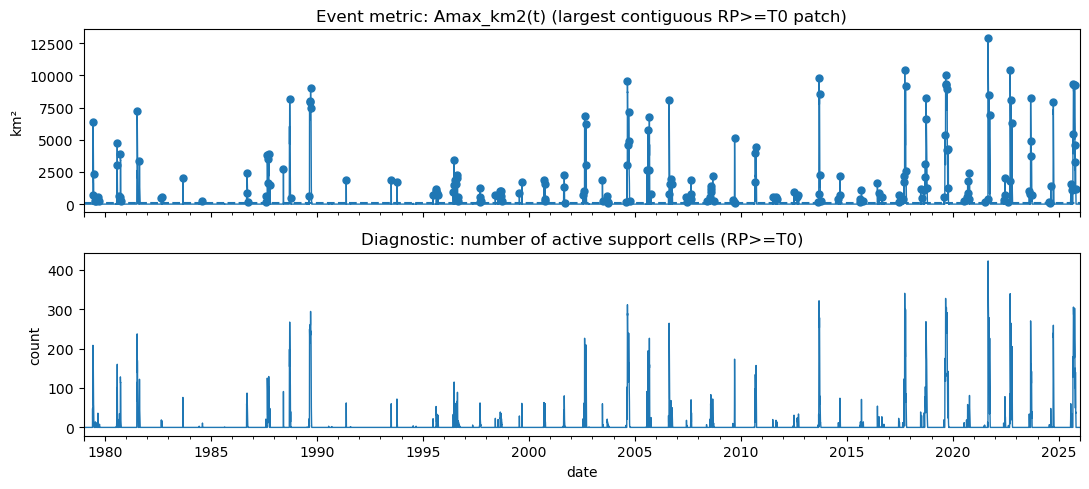

Event-set coverage: 47.00 years
Detected events: 204  =>  lambda ≈ 4.341 events/year
Per-event frequency: 0.021277 1/year


,event_id,source,peak_date,start_date,end_date,W_peak,T0_years,A_min_km2,support_mask_rp_years,decluster_days,cc_connectivity,n_active_cells_peak,frequency,span_years,lambda_events_per_year
0,HIST_00000,historical,1979-06-04,1979-06-01,1979-06-07,705.433671,2.0,100.0,10,5,2,48,0.021277,46.998912,4.340526
1,HIST_00001,historical,1979-06-10,1979-06-07,1979-06-13,6376.888212,2.0,100.0,10,5,2,208,0.021277,46.998912,4.340526
2,HIST_00002,historical,1979-06-20,1979-06-17,1979-06-23,2330.645479,2.0,100.0,10,5,2,80,0.021277,46.998912,4.340526
3,HIST_00003,historical,1979-07-23,1979-07-20,1979-07-26,245.305647,2.0,100.0,10,5,2,14,0.021277,46.998912,4.340526
4,HIST_00004,historical,1979-08-02,1979-07-30,1979-08-05,244.883113,2.0,100.0,10,5,2,10,0.021277,46.998912,4.340526


In [12]:
# =========================
# Section 4 — HISTORICAL EVENT DETECTION (Option A: Amax_km2(t))
# =========================

det_df = compute_amax_series_from_discharge(
    discharge_ts=discharge_ts,
    evt_params=evt_params,
    support_cells_present=support_cells_present,
    grid_index=grid_index,
    area_grid_km2=area_grid_km2,
    t0_years=T0_YEARS,
    connectivity=CC_CONNECTIVITY,
)

# Keep variable naming compatible downstream:
W_series = det_df["Amax_km2"].rename("Amax_km2")     # was W(t), now Amax(t)
thr_W = float(A_MIN_KM2)
peaks = peak_pick(W_series, thr_W, DECLUSTER_DAYS)

_log(f"Historical detected peaks: {len(peaks)} (T0={T0_YEARS}y, A_MIN={A_MIN_KM2} km², decluster={DECLUSTER_DAYS}d)")

# Diagnostics plots
fig, ax = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
W_series.plot(ax=ax[0], lw=1)
ax[0].axhline(thr_W, ls="--")
ax[0].scatter(peaks, W_series.loc[peaks], s=25)
ax[0].set_title("Event metric: Amax_km2(t) (largest contiguous RP>=T0 patch)")
ax[0].set_ylabel("km²")

det_df["n_active_cells"].plot(ax=ax[1], lw=1)
ax[1].set_title("Diagnostic: number of active support cells (RP>=T0)")
ax[1].set_ylabel("count")

plt.tight_layout()
plt.show()

# Build event registry (keep your existing structure)
EVENT_WINDOW_DAYS = 3  # for footprint extraction from historical discharge

event_registry_hist = pd.DataFrame({
    "event_id": [f"HIST_{i:05d}" for i in range(len(peaks))],
    "source": "historical",
    "peak_date": peaks,
})
event_registry_hist["start_date"] = event_registry_hist["peak_date"] - pd.Timedelta(days=EVENT_WINDOW_DAYS)
event_registry_hist["end_date"]   = event_registry_hist["peak_date"] + pd.Timedelta(days=EVENT_WINDOW_DAYS)

# Keep column name W_peak for compatibility, but it is now Amax_km2 at peak day
event_registry_hist["W_peak"] = W_series.loc[event_registry_hist["peak_date"]].values.astype(float)

event_registry_hist["T0_years"] = T0_YEARS
event_registry_hist["A_min_km2"] = A_MIN_KM2
event_registry_hist["support_mask_rp_years"] = SUPPORT_MASK_RP_YEARS
event_registry_hist["decluster_days"] = DECLUSTER_DAYS
event_registry_hist["cc_connectivity"] = CC_CONNECTIVITY

# Optional: store n_active at peak for debugging/QA
event_registry_hist["n_active_cells_peak"] = det_df.loc[event_registry_hist["peak_date"], "n_active_cells"].values

span_years = (W_series.index.max() - W_series.index.min()).days / 365.2425
event_registry_hist["frequency"] = 1.0 / max(span_years, 1e-6)

# --- Frequency assignment for historical event set (Hazard-space) ---
t_start = pd.Timestamp(discharge_ts.index.min())
t_end   = pd.Timestamp(discharge_ts.index.max())

# robust years coverage (fractional years)
span_years = (t_end - t_start).total_seconds() / (365.2425 * 24 * 3600)

N_events = len(event_registry_hist)
lambda_hat = N_events / span_years  # events per year (after declustering)

# Empirical event-set frequency: each observed event occurred once in span_years
event_registry_hist["frequency"] = 1.0 / span_years

# Store for audit
event_registry_hist["span_years"] = span_years
event_registry_hist["lambda_events_per_year"] = lambda_hat

print(f"Event-set coverage: {span_years:.2f} years")
print(f"Detected events: {N_events}  =>  lambda ≈ {lambda_hat:.3f} events/year")
print(f"Per-event frequency: {1.0/span_years:.6f} 1/year")

event_registry_hist.head()

In [13]:
# =========================
# QA — Are detected events coherent spatial patches?
# =========================

def qa_event_peak_metrics(peaks, discharge_ts, evt_params, support_cells_present, grid_index, area_grid_km2, t0_years):
    cells = [c for c in support_cells_present if c in discharge_ts.columns]
    p = evt_params.set_index("cell_id").loc[cells]

    u = p["u"].to_numpy()
    xi = p["xi"].to_numpy()
    sigma = p["sigma"].to_numpy()
    lam = p["lam"].to_numpy()

    valid = (grid_index >= 0)
    structure = generate_binary_structure(2, CC_CONNECTIVITY)

    # typical cell area (km²) for interpreting Amax in cell counts
    cell_area_med = float(np.median(area_grid_km2[valid]))

    rows = []
    for t in peaks:
        if t not in discharge_ts.index:
            continue

        q = discharge_ts.loc[t, cells].to_numpy()[None, :]
        rp = discharge_to_return_period(q, u[None,:], sigma[None,:], xi[None,:], lam[None,:], rp_cap=RP_CAP).ravel()
        active = (rp >= t0_years)

        g = np.zeros(grid_index.shape, dtype=bool)
        g[valid] = active[grid_index[valid]]

        n_active = int(g.sum())
        if n_active == 0:
            rows.append({"peak_date": t, "n_active_cells": 0, "A_total_km2": 0.0, "Amax_km2": 0.0, "n_components": 0, "amax_cells": 0.0})
            continue

        # Bounding-box crop: label only the active subgrid (5-30x faster)
        active_idx = np.argwhere(g)
        r0 = max(int(active_idx[:, 0].min()) - 1, 0)
        c0 = max(int(active_idx[:, 1].min()) - 1, 0)
        r1 = min(int(active_idx[:, 0].max()) + 2, g.shape[0])
        c1 = min(int(active_idx[:, 1].max()) + 2, g.shape[1])
        g_sub = g[r0:r1, c0:c1]
        area_sub = area_grid_km2[r0:r1, c0:c1]

        labs_sub, nlab = label(g_sub, structure=structure)
        areas = np.bincount(labs_sub.ravel(), weights=area_sub.ravel())
        amax = float(np.max(areas[1:])) if len(areas) > 1 else 0.0
        atot = float(np.sum(areas[1:])) if len(areas) > 1 else 0.0

        rows.append({
            "peak_date": t,
            "n_active_cells": n_active,
            "A_total_km2": atot,
            "Amax_km2": amax,
            "n_components": int(nlab),
            "amax_cells": amax / max(cell_area_med, 1e-6),
        })

    return pd.DataFrame(rows).sort_values("Amax_km2", ascending=False)

qa_df = qa_event_peak_metrics(
    peaks=peaks,
    discharge_ts=discharge_ts,
    evt_params=evt_params,
    support_cells_present=support_cells_present,
    grid_index=grid_index,
    area_grid_km2=area_grid_km2,
    t0_years=T0_YEARS,
)

_log("QA summary (top 10 by Amax_km2):")
display(qa_df.head(10))

_log("QA quantiles:")
display(qa_df[["Amax_km2","amax_cells","n_active_cells","n_components","A_total_km2"]].quantile([0,0.1,0.25,0.5,0.75,0.9,1]))

[NB4-CAT] QA summary (top 10 by Amax_km2):


,peak_date,n_active_cells,A_total_km2,Amax_km2,n_components,amax_cells
174,2021-08-31,422,12939.924820,12939.924820,1,421.972253
146,2017-09-24,340,10423.633683,10423.633683,1,339.915746
182,2022-09-15,339,10395.792774,10395.792774,1,339.007851
159,2019-08-30,327,10025.704911,10025.704911,1,326.939248
127,2013-09-09,321,9840.180453,9840.180453,1,320.889277
85,2004-08-26,311,9537.684944,9537.684944,1,311.024868
198,2025-09-09,305,9349.575509,9349.575509,1,304.890600
161,2019-09-12,304,9319.496122,9319.496122,1,303.909708
199,2025-09-16,302,9258.175319,9258.175319,1,301.910031
160,2019-09-06,302,9258.032751,9258.032751,1,301.905382


[NB4-CAT] QA quantiles:


,Amax_km2,amax_cells,n_active_cells,n_components,A_total_km2
0.00,122.651168,3.999667,4.00,1.0,122.651168
0.10,214.676558,7.000624,9.30,1.0,284.956391
0.25,521.832819,17.017021,19.75,1.0,605.016169
0.50,1272.913479,41.509837,54.00,2.0,1656.321153
0.75,3546.424519,115.649261,125.00,3.0,3830.085109
0.90,8064.894929,262.997037,263.10,4.0,8064.894929
1.00,12939.924820,421.972253,422.00,8.0,12939.924820


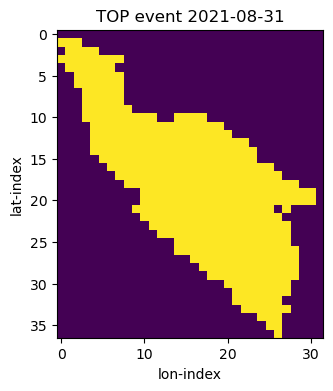

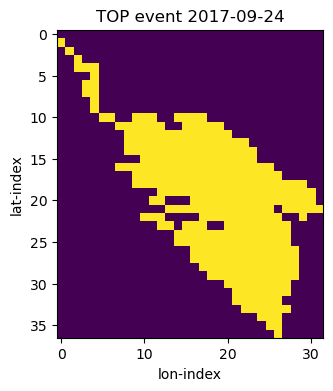

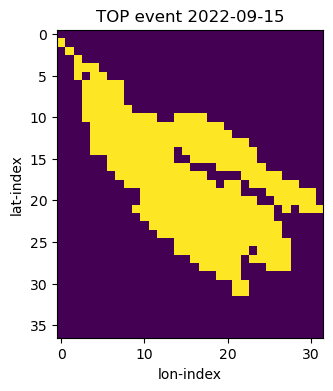

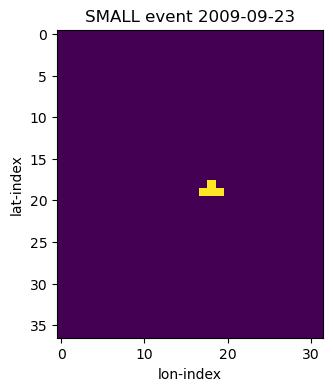

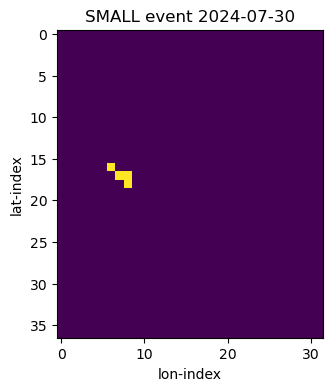

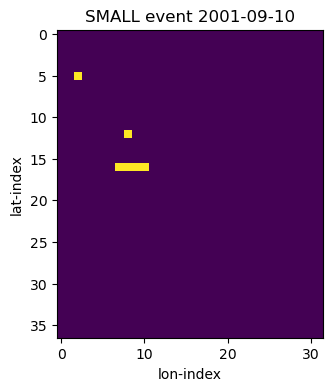

In [14]:
# =========================
# QA — Visualize active RP>=T0 grid for a few events
# =========================

def plot_active_grid_on_peak(peak_date, title=None):
    cells = [c for c in support_cells_present if c in discharge_ts.columns]
    p = evt_params.set_index("cell_id").loc[cells]
    q = discharge_ts.loc[peak_date, cells].to_numpy()[None, :]

    rp = discharge_to_return_period(
        q,
        p["u"].to_numpy()[None,:],
        p["sigma"].to_numpy()[None,:],
        p["xi"].to_numpy()[None,:],
        p["lam"].to_numpy()[None,:],
        rp_cap=RP_CAP
    ).ravel()

    valid = (grid_index >= 0)
    g = np.zeros(grid_index.shape, dtype=bool)
    g[valid] = (rp[grid_index[valid]] >= T0_YEARS)

    plt.figure(figsize=(6,4))
    plt.imshow(g, interpolation="nearest")
    plt.title(title or f"Active RP≥{T0_YEARS} on {peak_date.date()}")
    plt.xlabel("lon-index"); plt.ylabel("lat-index")
    plt.show()

# Plot top 3 largest + 3 smallest events
top3 = qa_df.sort_values("Amax_km2", ascending=False).head(3)["peak_date"].tolist()
bot3 = qa_df.sort_values("Amax_km2", ascending=True).head(3)["peak_date"].tolist()

for t in top3:
    plot_active_grid_on_peak(t, title=f"TOP event {t.date()}")

for t in bot3:
    plot_active_grid_on_peak(t, title=f"SMALL event {t.date()}")

In [15]:
# =========================
# Section 4B — EVENT EPISODES
# =========================

EXCEED = (W_series >= A_MIN_KM2).astype(int)

# label contiguous exceedance runs in time
# (note: this is 1D, so simple diff logic works)
starts = EXCEED[(EXCEED == 1) & (EXCEED.shift(1, fill_value=0) == 0)].index
ends   = EXCEED[(EXCEED == 1) & (EXCEED.shift(-1, fill_value=0) == 0)].index

episodes = []
for s, e in zip(starts, ends):
    seg = W_series.loc[s:e]
    peak_date = seg.idxmax()
    episodes.append({
        "start_date": s,
        "end_date": e,
        "duration_days": int((e - s).days) + 1,
        "peak_date": peak_date,
        "Amax_km2_peak": float(seg.max()),
    })

episodes_df = pd.DataFrame(episodes).sort_values("peak_date").reset_index(drop=True)
episodes_df["event_id"] = [f"HIST_{i:05d}" for i in range(len(episodes_df))]
episodes_df["source"] = "historical"
episodes_df["T0_years"] = T0_YEARS
episodes_df["A_min_km2"] = A_MIN_KM2
episodes_df["decluster_days"] = DECLUSTER_DAYS

_log(f"Episode-based events: {len(episodes_df)} (vs peak_pick={len(peaks)})")
episodes_df.head()

[NB4-CAT] Episode-based events: 139 (vs peak_pick=204)


,start_date,end_date,duration_days,peak_date,Amax_km2_peak,event_id,source,T0_years,A_min_km2,decluster_days
0,1979-06-03,1979-06-07,5,1979-06-04,705.433671,HIST_00000,historical,2.0,100.0,5
1,1979-06-09,1979-06-26,18,1979-06-10,6376.888212,HIST_00001,historical,2.0,100.0,5
2,1979-07-20,1979-07-24,5,1979-07-20,245.305647,HIST_00002,historical,2.0,100.0,5
3,1979-08-02,1979-08-03,2,1979-08-02,244.883113,HIST_00003,historical,2.0,100.0,5
4,1979-08-05,1979-08-05,1,1979-08-05,122.454743,HIST_00004,historical,2.0,100.0,5


In [16]:
# Join QA metrics computed earlier (qa_df is from your QA cell)
episodes_df = episodes_df.merge(
    qa_df.rename(columns={"peak_date":"peak_date"}),
    on="peak_date",
    how="left"
)

# A simple “realness” score (tunable)
# - coherence: amax_cells
# - persistence: duration_days
episodes_df["is_coherent"] = episodes_df["amax_cells"] >= 5          # ~ >=150 km² on your grid
episodes_df["is_persistent"] = episodes_df["duration_days"] >= 2

episodes_df[["event_id","peak_date","duration_days","Amax_km2_peak","amax_cells","n_components","n_active_cells","is_coherent","is_persistent"]].head(15)

,event_id,peak_date,duration_days,Amax_km2_peak,amax_cells,n_components,n_active_cells,is_coherent,is_persistent
0,HIST_00000,1979-06-04,5,705.433671,23.004263,4.0,48.0,True,True
1,HIST_00001,1979-06-10,18,6376.888212,207.950968,1.0,208.0,True,True
2,HIST_00002,1979-07-20,5,245.305647,NaN,NaN,NaN,False,True
3,HIST_00003,1979-08-02,2,244.883113,7.985663,2.0,10.0,True,True
4,HIST_00004,1979-08-05,1,122.454743,NaN,NaN,NaN,False,False
5,HIST_00005,1979-09-03,6,520.448827,16.971889,2.0,20.0,True,True
6,HIST_00006,1979-10-01,1,245.739019,8.013574,1.0,8.0,True,False
7,HIST_00007,1980-07-23,1,275.480068,NaN,NaN,NaN,False,False
8,HIST_00008,1980-08-02,13,4721.189944,153.958480,3.0,160.0,True,True
9,HIST_00009,1980-08-30,4,612.502180,19.973758,1.0,20.0,True,True


In [17]:
# =========================
# Section 4C — FINAL HISTORICAL EVENT SET
# =========================
# Change this values to be more or less strict in filtering detected episodes into final events.

MIN_AMAX_CELLS = 5          
MIN_DURATION_DAYS = 2
BIG_EVENT_KM2 = 500.0       # keep big 1-day events

keep = (
    (episodes_df["amax_cells"] >= MIN_AMAX_CELLS) &
    (
        (episodes_df["duration_days"] >= MIN_DURATION_DAYS) |
        (episodes_df["Amax_km2_peak"] >= BIG_EVENT_KM2)
    )
)

episodes_df["keep_coherent"] = episodes_df["amax_cells"] >= MIN_AMAX_CELLS
episodes_df["keep_persistent"] = episodes_df["duration_days"] >= MIN_DURATION_DAYS
episodes_df["keep_big"] = episodes_df["Amax_km2_peak"] >= BIG_EVENT_KM2
episodes_df["keep_final"] = episodes_df["keep_coherent"] & (episodes_df["keep_persistent"] | episodes_df["keep_big"])

event_registry_hist = episodes_df.loc[keep].copy()

# add the same window you used before for footprint extraction
EVENT_WINDOW_DAYS = 3
event_registry_hist["start_date"] = event_registry_hist["peak_date"] - pd.Timedelta(days=EVENT_WINDOW_DAYS)
event_registry_hist["end_date"]   = event_registry_hist["peak_date"] + pd.Timedelta(days=EVENT_WINDOW_DAYS)

event_registry_hist = event_registry_hist.sort_values("peak_date").reset_index(drop=True)
event_registry_hist["event_id"] = [f"HIST_{i:05d}" for i in range(len(event_registry_hist))]

_log(f"Kept {len(event_registry_hist)} / {len(episodes_df)} episodes after QA filter")
event_registry_hist[["event_id","peak_date","duration_days","Amax_km2_peak","amax_cells","n_components","n_active_cells"]].head()

[NB4-CAT] Kept 111 / 139 episodes after QA filter


,event_id,peak_date,duration_days,Amax_km2_peak,amax_cells,n_components,n_active_cells
0,HIST_00000,1979-06-04,5,705.433671,23.004263,4.0,48.0
1,HIST_00001,1979-06-10,18,6376.888212,207.950968,1.0,208.0
2,HIST_00002,1979-08-02,2,244.883113,7.985663,2.0,10.0
3,HIST_00003,1979-09-03,6,520.448827,16.971889,2.0,20.0
4,HIST_00004,1980-08-02,13,4721.189944,153.958480,3.0,160.0


In [18]:
# =========================
# Section 5 — HISTORICAL IMPACTS (NB3-MIRROR: DEPTH + POP AFFECTED)
# =========================

# Footprint cells (use full support grid for stable RP field)
fp_cells = support_cells_present
fp_cells = [c for c in fp_cells if c in discharge_ts.columns]
fp_params = evt_params.set_index("cell_id").loc[fp_cells]

nlat = fp_params["lat"].round(4).nunique()
nlon = fp_params["lon"].round(4).nunique()
n = len(fp_params)
full = nlat * nlon
_log(f"Footprint grid: {nlat}x{nlon}={full} cells, present={n}, missing={full-n} ({(full-n)/full*100:.1f}%)")
_log(f"Processing {len(event_registry_hist)} historical events with {len(fp_cells)} footprint cells")

# Precompute EVT parameter arrays once (speed)
u     = fp_params["u"].values[None, :]
xi    = fp_params["xi"].values[None, :]
sigma = fp_params["sigma"].values[None, :]
lam   = fp_params["lam"].values[None, :]

# ------------------------------------------------------------
# Build ONE event grid bbox from fp_params extent (constant)
# ------------------------------------------------------------
pad_deg = 0.25
minx = float(fp_params["lon"].min()) - pad_deg
maxx = float(fp_params["lon"].max()) + pad_deg
miny = float(fp_params["lat"].min()) - pad_deg
maxy = float(fp_params["lat"].max()) + pad_deg

# Load/mosaic JRC maps once for this bbox (constant)
flood_maps_ev, transform_ev = load_jrc_flood_maps_for_bbox(
    bbox=(minx, miny, maxx, maxy),
    rps=jrc_rps,
    rp_to_files=rp_to_files,
    tile_bounds=tile_bounds,
)

# --- Petals parity: add a 1-year "null flood map" so RP<minRP doesn't default to RP10 ---
if 1 not in flood_maps_ev["return_period"].values:
    null = xr.full_like(flood_maps_ev.isel(return_period=0), np.nan).expand_dims({"return_period": [1]})
    flood_maps_ev = xr.concat([null, flood_maps_ev], dim="return_period").sortby("return_period")
    _log(f"✓ Added RP=1 null map. flood_maps_ev RPs = {list(flood_maps_ev.return_period.values)}")

h_ev = flood_maps_ev.sizes["latitude"]
w_ev = flood_maps_ev.sizes["longitude"]

# Reproject population ONCE to that grid
pop_ev = reproject_worldpop_to_event_grid(
    pop_src=pop_src,
    pop_src_transform=pop_src_transform,
    pop_src_crs=pop_src_crs,
    dst_shape=(h_ev, w_ev),
    dst_transform=transform_ev,
    pop_src_nodata=pop_src_nodata,
)

# Rasterize admin IDs ONCE to that grid (filter polygons to bbox for speed)
bbox_geom = sbox(minx, miny, maxx, maxy)
adm_ev = admin_gdf[admin_gdf.intersects(bbox_geom)].copy()
admin_id_raster_ev, admin_ids_present_ev = rasterize_admin_ids_to_event_grid(
    adm_ev, (h_ev, w_ev), transform_ev, id_field="adm3_id"
)

_log(f"✓ Cached event grid for impacts: flood_maps={tuple(flood_maps_ev.shape)}, pop={pop_ev.shape}, admin_ids={len(admin_ids_present_ev)}")

# ------------------------------------------------------------
# Loop events
# ------------------------------------------------------------
impacts_hist_rows = []

for idx, (_, ev) in enumerate(event_registry_hist.iterrows()):
    eid = ev["event_id"]

    # 1) discharge window (episode window already in event_registry_hist)
    window = discharge_ts.loc[
        (discharge_ts.index >= ev["start_date"]) &
        (discharge_ts.index <= ev["end_date"]),
        fp_cells
    ]
    if window.empty:
        _log(f"⚠️ Event {eid}: No discharge data in window, skipping")
        continue

    # 2) qmax per cell
    qmax = window.max(axis=0).values[None, :]  # (1, n_cells)

    # 3) RP values via EVT params
    rp_vals = discharge_to_return_period(qmax, u, sigma, xi, lam, rp_cap=RP_CAP).ravel()

    # Early exit: skip expensive regridding if no cell reaches RP >= 2yr
    if np.nanmax(rp_vals) < 2.0:
        df_imp = aggregate_affected_population_nb3_fast(
            pop_grid=np.zeros((1, 1), dtype="float32"),
            depth_grid=np.zeros((1, 1), dtype="float32"),
            admin_id_raster=np.zeros((1, 1), dtype="int32"),
            admin_ids_present=admin_ids_present_ev,
            thresholds_m=DEPTH_THRESHOLDS,
            id_to_name=admin_id_to_name,
        )
        df_imp["event_id"] = eid
        df_imp["source"] = "historical"
        impacts_hist_rows.append(df_imp)
        continue

    if idx < 10:
        frac_ge10 = float(np.mean(rp_vals >= 10.0))
        frac_ge20 = float(np.mean(rp_vals >= 20.0))
        p = np.nanpercentile(rp_vals, [50, 90, 99])
        _log(f"{eid}: RP p50={p[0]:.2f} p90={p[1]:.2f} p99={p[2]:.2f} | frac>=10={frac_ge10:.3f} frac>=20={frac_ge20:.3f}")

    # 4) Build RP 2D grid
    rp_df = pd.DataFrame({
        "lat": fp_params["lat"].values.astype(float),
        "lon": fp_params["lon"].values.astype(float),
        "rp":  rp_vals.astype(float),
    })

    # NB3 parity: missing stays NaN (unknown), not RP=1

    rp_grid_2d = build_rp_grid_from_values(rp_df, value_col="rp", fill=np.nan)
    rp_grid_2d = rp_grid_2d.sortby("latitude").sortby("longitude")

    # 5) Depth interpolation (Petals) using cached flood_maps_ev
    depth_da = compute_depth_from_rp_nb3(
        rp_grid_2d,
        event_id=eid,
        apply_flopros=USE_FLOPROS,
        flood_maps=flood_maps_ev
    )
    if idx < 5:
        for thr in DEPTH_THRESHOLDS:
            frac = np.mean(np.isfinite(depth_da.values) & (depth_da.values >= thr))
            _log(f"{eid}: frac(depth>={thr}m)={frac:.4f}")

    # 6) Aggregate affected population on cached pop/admin rasters
    # Aggregate
    pop_use, admin_use, admin_ids_use = subset_to_depth_grid(
        depth_da=depth_da,
        flood_maps_ev=flood_maps_ev,
        pop_ev=pop_ev,
        admin_id_raster_ev=admin_id_raster_ev,
    )

    if idx < 10:
        popmask = np.isfinite(pop_use) & (pop_use > 0)
        for thr in DEPTH_THRESHOLDS:
            flooded = np.isfinite(depth_da.values) & (depth_da.values >= thr)
            flooded_pop_px = int((flooded & popmask).sum())
            total_pop_px = int(popmask.sum())
            frac_pop_px = flooded_pop_px / max(total_pop_px, 1)
            _log(f"{eid}: thr={thr}m | flooded_pop_pixels={flooded_pop_px}/{total_pop_px} ({frac_pop_px:.3f})")

    df_imp = aggregate_affected_population_nb3_fast(
        pop_grid=pop_use,
        depth_grid=depth_da.values,
        admin_id_raster=admin_use,
        admin_ids_present=admin_ids_use,
        thresholds_m=DEPTH_THRESHOLDS,
        id_to_name=admin_id_to_name,
    )
    df_imp["event_id"] = eid
    df_imp["source"] = "historical"
    impacts_hist_rows.append(df_imp)

    if (idx + 1) % 5 == 0:
        _log(f"Processed {idx + 1}/{len(event_registry_hist)} events")

# ------------------------------------------------------------
# Concatenate + merge back to registry
# ------------------------------------------------------------
impacts_by_admin_historical = pd.concat(impacts_hist_rows, ignore_index=True) if impacts_hist_rows else pd.DataFrame()
_log(f"✓ Historical impacts computed: {len(impacts_by_admin_historical):,} rows")

if not impacts_by_admin_historical.empty:
    pop_by_event = impacts_by_admin_historical.groupby(["event_id","depth_thr_m"])["affected_pop"].sum().unstack("depth_thr_m")
    for thr in DEPTH_THRESHOLDS:
        if thr not in pop_by_event.columns:
            pop_by_event[thr] = 0.0

    # Systematic column naming for all depth thresholds
    col_rename = {thr: depth_thr_to_col(thr) for thr in DEPTH_THRESHOLDS}
    pop_by_event = pop_by_event.reset_index().rename(columns=col_rename)
    event_registry_hist = event_registry_hist.merge(pop_by_event, on="event_id", how="left")
    # Backward-compat aliases
    event_registry_hist["PopAffected_op"] = event_registry_hist[depth_thr_to_col(DEPTH_PRIMARY)]
    event_registry_hist["PopAffected_sat"] = event_registry_hist[depth_thr_to_col(DEPTH_SAT)]
else:
    for thr in DEPTH_THRESHOLDS:
        event_registry_hist[depth_thr_to_col(thr)] = np.nan
    event_registry_hist["PopAffected_op"] = np.nan
    event_registry_hist["PopAffected_sat"] = np.nan

_log("✓ Section 5 complete (depth + pop affected)")
event_registry_hist.head()

[NB4-CAT] Footprint grid: 37x32=1184 cells, present=430, missing=754 (63.7%)
[NB4-CAT] Processing 111 historical events with 430 footprint cells
[NB4-CAT] ✓ Added RP=1 null map. flood_maps_ev RPs = [1, 10, 20, 50, 75, 100, 200, 500]
[NB4-CAT] ✓ Cached event grid for impacts: flood_maps=(8, 2760, 2460), pop=(2760, 2460), admin_ids=177
[NB4-CAT] HIST_00000: RP p50=1.00 p90=2.34 p99=5.00 | frac>=10=0.000 frac>=20=0.000
[NB4-CAT] Regridder built and cached (src shape (37, 32))
[NB4-CAT] HIST_00000: frac(depth>=0.01m)=0.0061
[NB4-CAT] HIST_00000: frac(depth>=0.02m)=0.0057
[NB4-CAT] HIST_00000: frac(depth>=0.03m)=0.0053
[NB4-CAT] HIST_00000: frac(depth>=0.04m)=0.0051
[NB4-CAT] HIST_00000: frac(depth>=0.05m)=0.0048
[NB4-CAT] HIST_00000: frac(depth>=0.1m)=0.0039
[NB4-CAT] HIST_00000: frac(depth>=0.15m)=0.0033
[NB4-CAT] HIST_00000: frac(depth>=0.2m)=0.0029
[NB4-CAT] HIST_00000: frac(depth>=0.3m)=0.0023
[NB4-CAT] HIST_00000: frac(depth>=0.5m)=0.0016
[NB4-CAT] HIST_00000: frac(depth>=1.0m)=0.0009

,start_date,end_date,duration_days,peak_date,Amax_km2_peak,event_id,source,T0_years,A_min_km2,decluster_days,...,PopAffected_40mm,PopAffected_50mm,PopAffected_100mm,PopAffected_150mm,PopAffected_200mm,PopAffected_300mm,PopAffected_500mm,PopAffected_1000mm,PopAffected_op,PopAffected_sat
0,1979-06-01,1979-06-07,5,1979-06-04,705.433671,HIST_00000,historical,2.0,100.0,5,...,2623.541611,2518.898006,2119.832176,1809.866595,1585.863128,1338.567790,938.538234,239.427804,2904.040003,1585.863128
1,1979-06-07,1979-06-13,18,1979-06-10,6376.888212,HIST_00001,historical,2.0,100.0,5,...,212514.290762,198888.527160,148609.022776,105330.160829,69912.347520,13708.678680,2274.509425,1318.272007,238183.337949,69912.347520
2,1979-07-30,1979-08-05,2,1979-08-02,244.883113,HIST_00002,historical,2.0,100.0,5,...,342607.565998,328189.027912,259870.556368,209912.608139,164200.524266,106328.085427,22608.883070,71.236778,379186.809174,164200.524266
3,1979-08-31,1979-09-06,6,1979-09-03,520.448827,HIST_00003,historical,2.0,100.0,5,...,151220.743475,131652.765787,44067.800218,3317.703046,1139.571250,758.597291,533.643316,233.830576,202691.557383,1139.571250
4,1980-07-30,1980-08-05,13,1980-08-02,4721.189944,HIST_00004,historical,2.0,100.0,5,...,231299.397174,222648.673026,187073.128024,157194.579763,131849.796006,86433.867688,16090.114308,1695.365678,246034.016767,131849.796006


In [19]:
event_registry_hist.to_csv(OUTPUT_DIR / "event_registry_historical.csv", index=False)

In [20]:
# =========================
# CHECKPOINT SAVE — Cell 18 outputs (run right after Section 5)
# =========================

import json
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path


def _resolve_output_dir() -> Path:
    if "OUTPUT_DIR" in globals() and globals()["OUTPUT_DIR"] is not None:
        return Path(globals()["OUTPUT_DIR"])
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        cand = p / "data" / "processed" / "impact_catalogue_catmodel"
        if cand.exists():
            return cand
    fallback = cwd / "data" / "processed" / "impact_catalogue_catmodel"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


RFC_YEAR = int(globals().get("RFC_YEAR", 2005))
OUTPUT_DIR_RESOLVED = _resolve_output_dir()
CKPT_DIR = OUTPUT_DIR_RESOLVED / "reforecast_library" / "checkpoints" / f"year={RFC_YEAR}"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

saved = []

# Heavy rasters/maps from Section 5
if "flood_maps_ev" in globals() and flood_maps_ev is not None:
    flood_maps_ev.to_netcdf(CKPT_DIR / "flood_maps_ev.nc")
    saved.append("flood_maps_ev.nc")

if "pop_ev" in globals() and pop_ev is not None:
    np.save(CKPT_DIR / "pop_ev.npy", np.asarray(pop_ev))
    saved.append("pop_ev.npy")

if "admin_id_raster_ev" in globals() and admin_id_raster_ev is not None:
    np.save(CKPT_DIR / "admin_id_raster_ev.npy", np.asarray(admin_id_raster_ev))
    saved.append("admin_id_raster_ev.npy")

if "admin_ids_present_ev" in globals() and admin_ids_present_ev is not None:
    np.save(CKPT_DIR / "admin_ids_present_ev.npy", np.asarray(admin_ids_present_ev))
    saved.append("admin_ids_present_ev.npy")

if "admin_id_to_name" in globals() and isinstance(admin_id_to_name, dict):
    with open(CKPT_DIR / "admin_id_to_name.json", "w", encoding="utf-8") as f:
        json.dump({str(k): v for k, v in admin_id_to_name.items()}, f, ensure_ascii=False)
    saved.append("admin_id_to_name.json")

# Footprint / EVT params needed by Cell 28
if "evt_params" in globals() and isinstance(evt_params, pd.DataFrame) and not evt_params.empty:
    evt_params.to_parquet(CKPT_DIR / "evt_params.parquet", index=False)
    saved.append("evt_params.parquet")

if "support_cells_present" in globals() and support_cells_present is not None:
    with open(CKPT_DIR / "support_cells_present.json", "w", encoding="utf-8") as f:
        json.dump(list(map(str, support_cells_present)), f)
    saved.append("support_cells_present.json")

if "fp_cells" in globals() and fp_cells is not None:
    with open(CKPT_DIR / "fp_cells.json", "w", encoding="utf-8") as f:
        json.dump(list(map(str, fp_cells)), f)
    saved.append("fp_cells.json")

# Optional registries from Section 5
if "event_registry_hist" in globals() and isinstance(event_registry_hist, pd.DataFrame):
    event_registry_hist.to_parquet(CKPT_DIR / "event_registry_hist.parquet", index=False)
    saved.append("event_registry_hist.parquet")

if "impacts_by_admin_historical" in globals() and isinstance(impacts_by_admin_historical, pd.DataFrame):
    impacts_by_admin_historical.to_parquet(CKPT_DIR / "impacts_by_admin_historical.parquet", index=False)
    saved.append("impacts_by_admin_historical.parquet")

# Save runtime knobs used later by Cell 28
runtime_cfg = {
    "DEPTH_THRESHOLDS": globals().get("DEPTH_THRESHOLDS", [0.1, 0.3, 0.5]),
    "DEPTH_PRIMARY": float(globals().get("DEPTH_PRIMARY", 0.02)),
    "DEPTH_OP": float(globals().get("DEPTH_OP", 0.1)),
    "DEPTH_SAT": float(globals().get("DEPTH_SAT", 0.3)),
    "USE_FLOPROS": bool(globals().get("USE_FLOPROS", True)),
    "RP_CAP": float(globals().get("RP_CAP", 500.0)),
    "RFC_SHORTNAME": str(globals().get("RFC_SHORTNAME", "dis24")),
    "RFC_YEAR": int(RFC_YEAR),
}
with open(CKPT_DIR / "runtime_config.json", "w", encoding="utf-8") as f:
    json.dump(runtime_cfg, f, indent=2)
saved.append("runtime_config.json")

print(f"Checkpoint saved at: {CKPT_DIR}")
print(f"Saved artifacts ({len(saved)}): {saved}")
print("After restart, run the restore cell before Cell 28.")

Checkpoint saved at: /Users/silvia/Desktop/personal/rodekruis/GLOFAS_ImpactFloodForecasting_PHL/data/processed/impact_catalogue_catmodel/reforecast_library/checkpoints/year=2005
Saved artifacts (11): ['flood_maps_ev.nc', 'pop_ev.npy', 'admin_id_raster_ev.npy', 'admin_ids_present_ev.npy', 'admin_id_to_name.json', 'evt_params.parquet', 'support_cells_present.json', 'fp_cells.json', 'event_registry_hist.parquet', 'impacts_by_admin_historical.parquet', 'runtime_config.json']
After restart, run the restore cell before Cell 28.


In [21]:
# =========================
# POST-S5 DIAGNOSTICS — PopAffected sanity
# =========================

cols = ["PopAffected_op", "PopAffected_sat"]
missing = event_registry_hist[cols].isna().sum()
neg = (event_registry_hist[cols] < 0).sum()

_log("Missing values (should be near 0 unless some events had no data):")
display(missing)

_log("Negative values (must be 0):")
display(neg)

_log("Summary stats:")
display(event_registry_hist[cols].describe(percentiles=[0.01,0.05,0.1,0.25,0.5,0.75,0.9,0.95,0.99]))

[NB4-CAT] Missing values (should be near 0 unless some events had no data):


PopAffected_op     0
PopAffected_sat    0
dtype: int64

[NB4-CAT] Negative values (must be 0):


PopAffected_op     0
PopAffected_sat    0
dtype: int64

[NB4-CAT] Summary stats:


,PopAffected_op,PopAffected_sat
count,111.000000,111.000000
mean,181130.320980,101567.267443
std,191839.294100,151704.725295
min,835.360343,161.796531
1%,1019.599106,246.180302
5%,1301.473346,403.768366
10%,1642.013369,797.572787
25%,2594.845352,1140.056650
50%,202691.557383,3153.189158
75%,308297.062739,156512.680079


[NB4-CAT] Spearman correlation (robust to nonlinearity):


,Amax_km2_peak,PopAffected_op,PopAffected_sat,duration_days
Amax_km2_peak,1.000000,0.477513,0.585995,0.749459
PopAffected_op,0.477513,1.000000,0.920507,0.345748
PopAffected_sat,0.585995,0.920507,1.000000,0.408824
duration_days,0.749459,0.345748,0.408824,1.000000


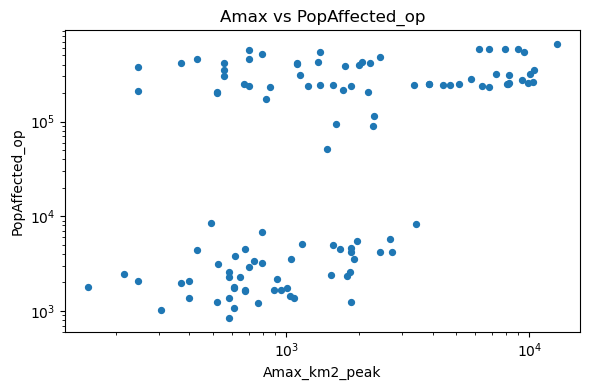

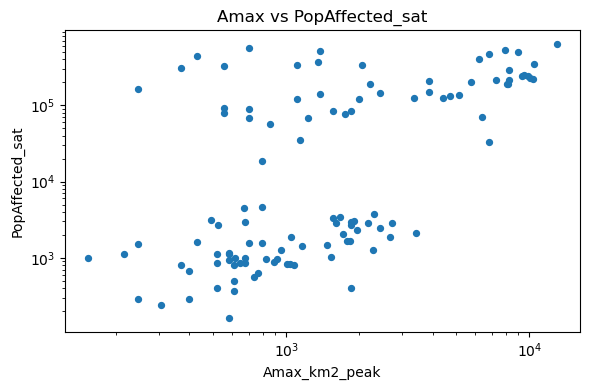

In [22]:
# =========================
# POST-S5 DIAGNOSTICS — PopAffected vs hazard magnitude
# =========================

tmp = event_registry_hist[["Amax_km2_peak", "duration_days", "PopAffected_op", "PopAffected_sat"]].dropna()

_log("Spearman correlation (robust to nonlinearity):")
display(tmp[["Amax_km2_peak","PopAffected_op","PopAffected_sat","duration_days"]].corr(method="spearman"))

# Scatter plots (log-log helps)
plt.figure(figsize=(6,4))
plt.scatter(tmp["Amax_km2_peak"], tmp["PopAffected_op"], s=18)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Amax_km2_peak")
plt.ylabel("PopAffected_op")
plt.title("Amax vs PopAffected_op")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(tmp["Amax_km2_peak"], tmp["PopAffected_sat"], s=18)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Amax_km2_peak")
plt.ylabel("PopAffected_sat")
plt.title("Amax vs PopAffected_sat")
plt.tight_layout()
plt.show()

In [23]:
q_candidates_evt2 = [0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
q_candidates_evt2 = [q for q in q_candidates_evt2 if 0 < q < 1]

[NB4-CAT] Threshold selection Tier 1 (stable): u=249603.13, delta_xi=0.1373, delta_sigma_rel=0.1969
[NB4-CAT] Using threshold override: u=249603.1313
[NB4-CAT] Selected u=249603.1313, xi=-0.4825, sigma=220423.0553, lambda=2.399
[NB4-CAT]   OK  depth=0.010m (PopAffected_10mm): u=249603.13, xi=-0.4825, sigma=220423.06, tier=stable
[NB4-CAT] Threshold selection Tier 1 (stable): u=241464.03, delta_xi=0.1327, delta_sigma_rel=0.1856
[NB4-CAT] Using threshold override: u=241464.0323
[NB4-CAT] Selected u=241464.0323, xi=-0.4179, sigma=204383.8938, lambda=2.399
[NB4-CAT]   OK  depth=0.020m (PopAffected_20mm): u=241464.03, xi=-0.4179, sigma=204383.89, tier=stable
[NB4-CAT] Threshold selection Tier 1 (stable): u=217195.46, delta_xi=0.1135, delta_sigma_rel=0.1384
[NB4-CAT] Using threshold override: u=217195.4624
[NB4-CAT] Selected u=217195.4624, xi=-0.2523, sigma=170961.0184, lambda=2.399
[NB4-CAT]   OK  depth=0.030m (PopAffected_30mm): u=217195.46, xi=-0.2523, sigma=170961.02, tier=stable
[NB4-CA

,depth_m,column,status,tier,u,xi,sigma,lam_total,p_exc,n_exc
0,0.01,PopAffected_10mm,OK,stable,249603.131296,-0.482470,220423.055322,2.399072,0.396396,44
1,0.02,PopAffected_20mm,OK,stable,241464.032284,-0.417924,204383.893799,2.399072,0.396396,44
2,0.03,PopAffected_30mm,OK,stable,217195.462429,-0.252332,170961.018356,2.399072,0.450450,50
3,0.04,PopAffected_40mm,OK,stable,203896.385934,-0.239673,171056.886955,2.399072,0.450450,50
4,0.05,PopAffected_50mm,OK,stable,185489.097090,-0.278450,186326.837820,2.399072,0.450450,50
5,0.10,PopAffected_100mm,OK,stable,155401.929287,-0.224965,182760.057497,2.399072,0.396396,44
6,0.15,PopAffected_150mm,OK,stable,51253.218161,-0.431502,287419.478595,2.399072,0.450450,50
7,0.20,PopAffected_200mm,OK,stable,11702.617548,-0.445447,308261.472135,2.399072,0.450450,50
8,0.30,PopAffected_300mm,OK,stable,4077.349810,-0.220305,219014.384021,2.399072,0.450450,50
9,0.50,PopAffected_500mm,OK,stable,10371.419230,-0.406855,276662.000180,2.399072,0.297297,33


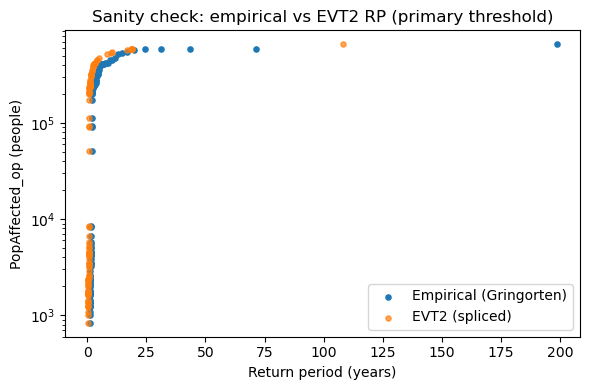

[NB4-CAT] Primary EVT2 fit: u=241464.032, xi=-0.418, sigma=204383.894, lam_total=2.399/y, p_exc=0.396, tier=stable


In [24]:
# =========================
# Section 6 — EVT2 ON IMPACT PEAKS (all depth thresholds)
# =========================

# 0) Validate primary PopAffected column exists
if "PopAffected_op" not in event_registry_hist.columns:
    raise ValueError("PopAffected_op not found. Run Section 5 and merge impacts first.")

neg = (event_registry_hist["PopAffected_op"] < 0).sum()
if neg > 0:
    raise ValueError(f"Found {neg} negative PopAffected_op values — investigate Section 5 aggregation.")

# 1) Loop over all depth thresholds and fit EVT2 for each
evt2_fits = {}          # {thr_m: fit_dict}
evt2_diagnostics = {}   # {thr_m: diag_df}
evt2_tiers = {}         # {thr_m: tier_string}
evt2_failures = {}      # {thr_m: error_message}

for thr_m in DEPTH_THRESHOLDS:
    col = depth_thr_to_col(thr_m)
    if col not in event_registry_hist.columns:
        evt2_failures[thr_m] = f"Column {col} missing from event_registry_hist"
        continue

    series = event_registry_hist.set_index("peak_date")[col].astype(float).sort_index()
    n_positive = int((series > 0).sum())

    if n_positive < MIN_EXCEEDANCES_EVT2:
        evt2_failures[thr_m] = f"Only {n_positive} positive values (need >= {MIN_EXCEEDANCES_EVT2})"
        continue

    try:
        u_sel, tier, diag_df = select_evt2_threshold(
            series,
            q_candidates_evt2,
            min_exceedances=MIN_EXCEEDANCES_EVT2,
            stability_tol_xi=0.15,
            stability_tol_sigma_rel=0.25,
        )
        fit = fit_evt2_spliced_impact(
            series,
            q_candidates_evt2,
            MIN_EXCEEDANCES_EVT2,
            threshold_override=u_sel,
        )
        evt2_fits[thr_m] = fit
        evt2_diagnostics[thr_m] = diag_df
        evt2_tiers[thr_m] = tier
        _log(f"  OK  depth={thr_m:.3f}m ({col}): u={fit['u']:.2f}, xi={fit['xi']:.4f}, "
             f"sigma={fit['sigma']:.2f}, tier={tier}")
    except (ValueError, Exception) as e:
        evt2_failures[thr_m] = str(e)
        _log(f"  SKIP depth={thr_m:.3f}m ({col}): {e}")

# 2) Summary table
summary_rows = []
for thr_m in DEPTH_THRESHOLDS:
    col = depth_thr_to_col(thr_m)
    if thr_m in evt2_fits:
        f = evt2_fits[thr_m]
        n_exc = int((event_registry_hist[col].astype(float) > f["u"]).sum())
        summary_rows.append({
            "depth_m": thr_m, "column": col, "status": "OK",
            "tier": evt2_tiers[thr_m], "u": f["u"], "xi": f["xi"],
            "sigma": f["sigma"], "lam_total": f["lam_total"],
            "p_exc": f["p_exc"], "n_exc": n_exc,
        })
    else:
        summary_rows.append({
            "depth_m": thr_m, "column": col, "status": "FAILED",
            "reason": evt2_failures.get(thr_m, "unknown"),
        })
evt2_summary = pd.DataFrame(summary_rows)
_log(f"EVT2 fitting: {len(evt2_fits)}/{len(DEPTH_THRESHOLDS)} thresholds succeeded")
display(evt2_summary)

# 3) Backward-compat variables for Cells 24/25/33 (primary threshold)
if DEPTH_PRIMARY not in evt2_fits:
    raise ValueError(f"Primary threshold {DEPTH_PRIMARY}m failed EVT2 fitting: "
                     f"{evt2_failures.get(DEPTH_PRIMARY, 'unknown')}")

fit_evt2 = evt2_fits[DEPTH_PRIMARY]
u_selected = float(fit_evt2["u"])
threshold_tier = evt2_tiers[DEPTH_PRIMARY]
evt2_diag_df = evt2_diagnostics[DEPTH_PRIMARY]

impact_peak_series = (
    event_registry_hist
    .set_index("peak_date")["PopAffected_op"]
    .astype(float)
    .sort_index()
)

# 4) Model-based RP for each event peak (primary threshold only)
event_registry_hist["RP_impact"] = impact_to_rp_spliced(
    event_registry_hist["PopAffected_op"].values, fit_evt2
)

# 5) Empirical RP for sanity check (Gringorten plotting position)
n_ev = len(event_registry_hist)
rank = event_registry_hist["PopAffected_op"].rank(ascending=False, method="first")
p_exc_emp = (rank - 0.44) / (n_ev + 0.12)
event_registry_hist["RP_empirical"] = 1.0 / np.clip(p_exc_emp, 1e-12, None)

# 6) Quick plot: model vs empirical (primary threshold only)
plt.figure(figsize=(6, 4))
plt.scatter(event_registry_hist["RP_empirical"], event_registry_hist["PopAffected_op"],
            s=14, label="Empirical (Gringorten)")
plt.scatter(event_registry_hist["RP_impact"], event_registry_hist["PopAffected_op"],
            s=14, label="EVT2 (spliced)", alpha=0.7)
plt.yscale("log")
plt.xlabel("Return period (years)")
plt.ylabel("PopAffected_op (people)")
plt.title("Sanity check: empirical vs EVT2 RP (primary threshold)")
plt.legend()
plt.tight_layout()
plt.show()

_log(f"Primary EVT2 fit: u={fit_evt2['u']:.3f}, xi={fit_evt2['xi']:.3f}, "
     f"sigma={fit_evt2['sigma']:.3f}, lam_total={fit_evt2['lam_total']:.3f}/y, "
     f"p_exc={fit_evt2['p_exc']:.3f}, tier={threshold_tier}")

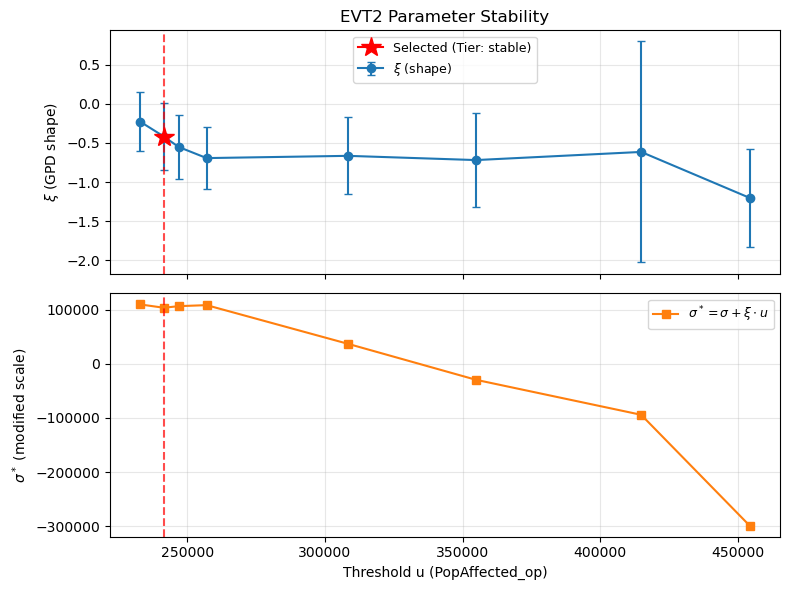

[NB4-CAT] Threshold selected: u=241464.03 (tier=stable)


,q,u,n_exc,xi,xi_std,sigma,sigma_star,delta_xi,delta_sigma_rel
0,0.55,232852.6590,50,-0.2275,0.3760,162570.5871,109598.2979,NaN,NaN
1,0.60,241464.0323,44,-0.4179,0.4309,204383.8938,103470.2105,0.1904,0.2572
2,0.65,246802.2376,39,-0.5506,0.4124,242323.1706,106437.8408,0.1327,0.1856
3,0.70,256977.0231,33,-0.6931,0.3966,286410.3523,108304.5574,0.1425,0.1819
4,0.75,308297.0627,28,-0.6643,0.4916,241792.4844,36976.7274,0.0287,0.1558
5,0.80,354875.5429,22,-0.7184,0.6007,225419.0548,-29516.6776,0.0540,0.0677
6,0.85,414874.1312,17,-0.6143,1.4135,160756.5717,-94103.1634,0.1041,0.2869
7,0.90,454252.0449,11,-1.2009,0.6250,247041.8788,-298487.3062,0.5866,0.5367


In [25]:
# =========================
# Section 6A — EVT2 Parameter Stability Visualization
# =========================
# Uses evt2_diag_df from Cell 23 (select_evt2_threshold output)

# Compute modified scale: sigma* = sigma + xi * u (should be constant if GPD holds)
evt2_diag_df["sigma_star"] = evt2_diag_df["sigma"] + evt2_diag_df["xi"] * evt2_diag_df["u"]

# Bootstrap error bars on xi at each threshold (lightweight: 50 iterations)
xi_boot_std = []
for _, row in evt2_diag_df.iterrows():
    u_q = row["u"]
    exc = impact_peak_series.values[impact_peak_series.values > u_q] - u_q
    if len(exc) < 5:
        xi_boot_std.append(np.nan)
        continue
    xi_samples = []
    rng_boot = np.random.default_rng(42)
    for _ in range(50):
        boot = rng_boot.choice(exc, size=len(exc), replace=True)
        try:
            c_b, _, _ = stats.genpareto.fit(boot, floc=0.0)
            xi_samples.append(float(c_b))
        except Exception:
            pass
    xi_boot_std.append(float(np.std(xi_samples)) if xi_samples else np.nan)
evt2_diag_df["xi_std"] = xi_boot_std

# --- Dual subplot: xi and sigma* vs threshold ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

valid = evt2_diag_df[np.isfinite(evt2_diag_df["xi"])]

# Top: xi vs threshold
ax1.errorbar(valid["u"], valid["xi"], yerr=valid["xi_std"], fmt="o-", capsize=3, label=r"$\xi$ (shape)")
ax1.axvline(u_selected, color="red", linestyle="--", alpha=0.7)
ax1.plot(u_selected, valid.loc[valid["u"] == u_selected, "xi"].values[0] if (valid["u"] == u_selected).any()
         else fit_evt2["xi"], marker="*", color="red", markersize=15, zorder=5,
         label=f"Selected (Tier: {threshold_tier})")
ax1.set_ylabel(r"$\xi$ (GPD shape)")
ax1.set_title("EVT2 Parameter Stability")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Bottom: sigma* vs threshold
ax2.plot(valid["u"], valid["sigma_star"], "s-", color="tab:orange", label=r"$\sigma^* = \sigma + \xi \cdot u$")
ax2.axvline(u_selected, color="red", linestyle="--", alpha=0.7)
ax2.set_xlabel("Threshold u (PopAffected_op)")
ax2.set_ylabel(r"$\sigma^*$ (modified scale)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# Print diagnostics table
_log(f"Threshold selected: u={u_selected:.2f} (tier={threshold_tier})")
display(evt2_diag_df[["q", "u", "n_exc", "xi", "xi_std", "sigma", "sigma_star", "delta_xi", "delta_sigma_rel"]].round(4))


[NB4-CAT] GOF summary for all fitted thresholds:


,depth_m,column,ks_stat,ks_pvalue,xi,xi_warning
0,0.01,PopAffected_10mm,0.2237,0.0205,-0.4825,False
1,0.02,PopAffected_20mm,0.2091,0.0364,-0.4179,False
2,0.03,PopAffected_30mm,0.1837,0.0598,-0.2523,False
3,0.04,PopAffected_40mm,0.1518,0.1800,-0.2397,False
4,0.05,PopAffected_50mm,0.1199,0.4344,-0.2785,False
5,0.10,PopAffected_100mm,0.1296,0.4151,-0.2250,False
6,0.15,PopAffected_150mm,0.1239,0.3944,-0.4315,False
7,0.20,PopAffected_200mm,0.0940,0.7338,-0.4454,False
8,0.30,PopAffected_300mm,0.1533,0.1718,-0.2203,False
9,0.50,PopAffected_500mm,0.1131,0.7501,-0.4069,False


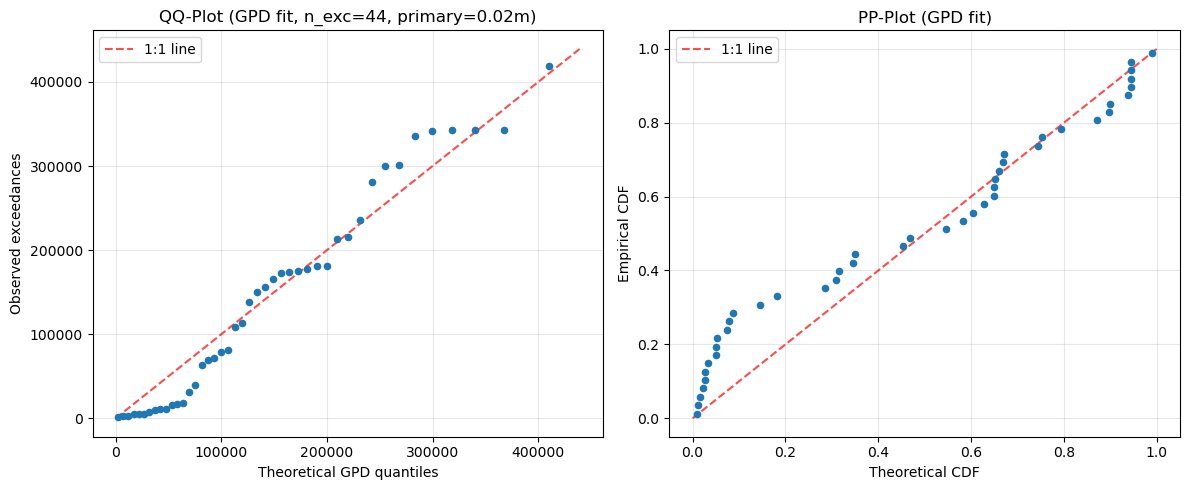

[NB4-CAT] KS test (primary): statistic=0.2091, p-value=0.0364
[NB4-CAT] WARNING: KS test rejects GPD fit at 5% level.
[NB4-CAT] Xi sanity check OK: xi=-0.4179 (|xi| <= 0.5).


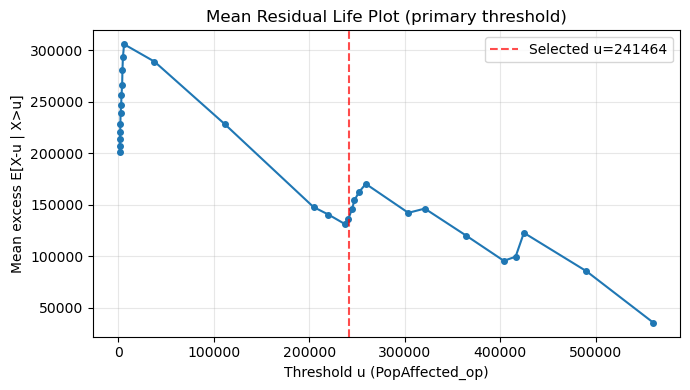

In [26]:
# =========================
# Section 6A.2 — EVT2 Goodness-of-Fit Diagnostics
# =========================

# --- Compute GOF for ALL fitted thresholds (fast) ---
gof_results_all = {}
for thr_m, fit in evt2_fits.items():
    col = depth_thr_to_col(thr_m)
    series_vals = event_registry_hist[col].astype(float).values
    exc = series_vals[series_vals > fit["u"]] - fit["u"]
    exc = exc[np.isfinite(exc)]
    if len(exc) >= 3:
        ks_stat, ks_pval = stats.kstest(exc, "genpareto", args=(fit["xi"], 0.0, fit["sigma"]))
        gof_results_all[thr_m] = {
            "ks_statistic": float(ks_stat),
            "ks_pvalue": float(ks_pval),
            "xi_warning": bool(abs(fit["xi"]) > 0.5),
        }
    else:
        gof_results_all[thr_m] = {"ks_statistic": np.nan, "ks_pvalue": np.nan, "xi_warning": False}

# GOF summary table
gof_summary = pd.DataFrame([
    {"depth_m": thr_m, "column": depth_thr_to_col(thr_m),
     "ks_stat": g["ks_statistic"], "ks_pvalue": g["ks_pvalue"],
     "xi": evt2_fits[thr_m]["xi"], "xi_warning": g["xi_warning"]}
    for thr_m, g in gof_results_all.items()
])
_log("GOF summary for all fitted thresholds:")
display(gof_summary.round(4))

# Backward-compat
gof_results = gof_results_all.get(DEPTH_PRIMARY, {"ks_statistic": np.nan, "ks_pvalue": np.nan, "xi_warning": False})

# --- Full plots for PRIMARY threshold only ---
xi_evt2 = float(fit_evt2["xi"])
sigma_evt2 = float(fit_evt2["sigma"])
u_evt2 = float(fit_evt2["u"])

exc_values = impact_peak_series.values[impact_peak_series.values > u_evt2] - u_evt2
n_exc_gof = len(exc_values)

# 1. QQ-Plot and PP-Plot
exc_sorted = np.sort(exc_values)
pp = (np.arange(1, n_exc_gof + 1) - 0.44) / (n_exc_gof + 0.12)
theoretical_q = stats.genpareto.ppf(pp, c=xi_evt2, loc=0.0, scale=sigma_evt2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(theoretical_q, exc_sorted, s=20, zorder=3)
lim = max(exc_sorted.max(), theoretical_q.max()) * 1.05
ax.plot([0, lim], [0, lim], "r--", alpha=0.7, label="1:1 line")
ax.set_xlabel("Theoretical GPD quantiles")
ax.set_ylabel("Observed exceedances")
ax.set_title(f"QQ-Plot (GPD fit, n_exc={n_exc_gof}, primary={DEPTH_PRIMARY}m)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
empirical_cdf = pp
theoretical_cdf = stats.genpareto.cdf(exc_sorted, c=xi_evt2, loc=0.0, scale=sigma_evt2)
ax.scatter(theoretical_cdf, empirical_cdf, s=20, zorder=3)
ax.plot([0, 1], [0, 1], "r--", alpha=0.7, label="1:1 line")
ax.set_xlabel("Theoretical CDF")
ax.set_ylabel("Empirical CDF")
ax.set_title("PP-Plot (GPD fit)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

# 2. KS test
ks_stat, ks_pvalue = stats.kstest(exc_values, "genpareto", args=(xi_evt2, 0.0, sigma_evt2))
_log(f"KS test (primary): statistic={ks_stat:.4f}, p-value={ks_pvalue:.4f}")
if ks_pvalue < 0.05:
    _log("WARNING: KS test rejects GPD fit at 5% level.")
else:
    _log(f"KS test does not reject GPD fit (p={ks_pvalue:.3f} >= 0.05).")

# 3. Xi sanity check
if abs(xi_evt2) > 0.5:
    _log(f"WARNING: |xi| = {abs(xi_evt2):.3f} > 0.5. Very heavy tail with only {n_exc_gof} exceedances.")
else:
    _log(f"Xi sanity check OK: xi={xi_evt2:.4f} (|xi| <= 0.5).")

# 4. Mean Residual Life plot
mrl_thresholds = []
mrl_means = []
impact_vals = impact_peak_series.dropna().values
for q in np.linspace(0.1, 0.95, 30):
    u_q = float(np.quantile(impact_vals, q))
    above = impact_vals[impact_vals > u_q] - u_q
    if len(above) >= 3:
        mrl_thresholds.append(u_q)
        mrl_means.append(float(np.mean(above)))

plt.figure(figsize=(7, 4))
plt.plot(mrl_thresholds, mrl_means, "o-", markersize=4)
plt.axvline(u_evt2, color="red", linestyle="--", alpha=0.7, label=f"Selected u={u_evt2:.0f}")
plt.xlabel("Threshold u (PopAffected_op)")
plt.ylabel("Mean excess E[X-u | X>u]")
plt.title("Mean Residual Life Plot (primary threshold)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

[NB4-CAT]   Saved depth_10mm: u=249603.13, xi=-0.4825, sigma=220423.06, tier=stable
[NB4-CAT]   Saved depth_20mm: u=241464.03, xi=-0.4179, sigma=204383.89, tier=stable
[NB4-CAT]   Saved depth_30mm: u=217195.46, xi=-0.2523, sigma=170961.02, tier=stable
[NB4-CAT]   Saved depth_40mm: u=203896.39, xi=-0.2397, sigma=171056.89, tier=stable
[NB4-CAT]   Saved depth_50mm: u=185489.10, xi=-0.2785, sigma=186326.84, tier=stable
[NB4-CAT]   Saved depth_100mm: u=155401.93, xi=-0.2250, sigma=182760.06, tier=stable
[NB4-CAT]   Saved depth_150mm: u=51253.22, xi=-0.4315, sigma=287419.48, tier=stable
[NB4-CAT]   Saved depth_200mm: u=11702.62, xi=-0.4454, sigma=308261.47, tier=stable
[NB4-CAT]   Saved depth_300mm: u=4077.35, xi=-0.2203, sigma=219014.38, tier=stable
[NB4-CAT]   Saved depth_500mm: u=10371.42, xi=-0.4069, sigma=276662.00, tier=stable
[NB4-CAT]   Saved depth_1000mm: u=1353.88, xi=3.1231, sigma=2397.44, tier=stable
[NB4-CAT] Legacy copy: evt2_fit_depth_20mm.json -> evt2_fit_popaffected_op.json

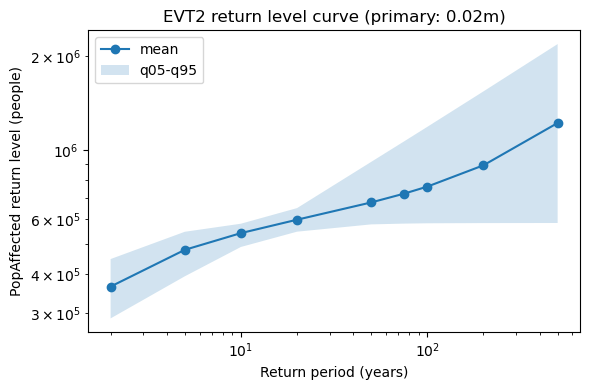

In [27]:
# =========================
# Section 6B — EVT2 return levels + bootstrap + JSON export (ALL depth thresholds)
# =========================

import shutil
from philflood.calibration.evt_pot import bootstrap_pot_return_levels

RETURN_PERIODS_EVT2 = [2, 5, 10, 20, 50, 75, 100, 200, 500]
N_BOOTSTRAP_EVT2 = 200
BOOTSTRAP_SEED_EVT2 = RNG_SEED

(OUTPUT_DIR / "evt2").mkdir(parents=True, exist_ok=True)

# --- Loop over all fitted thresholds ---
for thr_m, fit in evt2_fits.items():
    tag = depth_thr_to_file_tag(thr_m)
    col = depth_thr_to_col(thr_m)
    gof = gof_results_all.get(thr_m, {})

    u = float(fit["u"])
    xi = float(fit["xi"])
    sigma = float(fit["sigma"])
    lam_total_val = float(fit["lam_total"])
    p_exc_val = float(fit["p_exc"])
    lambda_u_val = lam_total_val * p_exc_val

    # Exceedances
    series_vals = event_registry_hist[col].astype(float).values
    exc = (series_vals[series_vals > u] - u).astype(float)

    # Bootstrap return levels
    rl = None
    if len(exc) >= 10:
        try:
            rl = bootstrap_pot_return_levels(
                exceedances=exc,
                threshold=u,
                lambda_u=lambda_u_val,
                return_periods=RETURN_PERIODS_EVT2,
                n_bootstrap=N_BOOTSTRAP_EVT2,
                random_state=BOOTSTRAP_SEED_EVT2,
            ).copy()
            rl = rl.rename(columns={
                "mean_m3s": "mean_pop", "std_m3s": "std_pop",
                "q05_m3s": "q05_pop", "q95_m3s": "q95_pop",
            })
            rl.to_parquet(OUTPUT_DIR / "evt2" / f"evt2_return_levels_{tag}.parquet", index=False)
        except Exception as e:
            _log(f"  Bootstrap failed for {tag}: {e}")
            rl = None
    else:
        _log(f"  Skipping bootstrap for {tag}: only {len(exc)} exceedances")

    # JSON export
    fit_out = {
        "evt2_version": "0.5.0",
        "variable": col,
        "depth_threshold_m": thr_m,
        "u": u,
        "xi": xi,
        "sigma": sigma,
        "lam_total": lam_total_val,
        "p_exc": p_exc_val,
        "lambda_u": lambda_u_val,
        "n_events": int(len(fit["hist"])),
        "n_exceedances": int(len(exc)),
        "q_candidates": q_candidates_evt2,
        "min_exceedances": int(MIN_EXCEEDANCES_EVT2),
        "threshold_tier": evt2_tiers[thr_m],
        "gof_ks_statistic": gof.get("ks_statistic", None),
        "gof_ks_pvalue": gof.get("ks_pvalue", None),
        "xi_warning": gof.get("xi_warning", None),
        "hist": fit["hist"].tolist() if hasattr(fit["hist"], "tolist") else list(fit["hist"]),
    }
    (OUTPUT_DIR / "evt2" / f"evt2_fit_{tag}.json").write_text(json.dumps(fit_out, indent=2))
    _log(f"  Saved {tag}: u={u:.2f}, xi={xi:.4f}, sigma={sigma:.2f}, tier={evt2_tiers[thr_m]}")

# --- Legacy copy: primary threshold -> evt2_fit_popaffected_op.json ---
primary_tag = depth_thr_to_file_tag(DEPTH_PRIMARY)
src_path = OUTPUT_DIR / "evt2" / f"evt2_fit_{primary_tag}.json"
dst_path = OUTPUT_DIR / "evt2" / "evt2_fit_popaffected_op.json"
if src_path.exists():
    shutil.copy2(src_path, dst_path)
    _log(f"Legacy copy: {src_path.name} -> {dst_path.name}")

# Also copy return levels for backward compat
src_rl = OUTPUT_DIR / "evt2" / f"evt2_return_levels_{primary_tag}.parquet"
dst_rl = OUTPUT_DIR / "evt2" / "evt2_return_levels_popaffected_op.parquet"
if src_rl.exists():
    shutil.copy2(src_rl, dst_rl)

# --- Manifest ---
manifest = {
    "evt2_version": "0.5.0",
    "primary_threshold_m": DEPTH_PRIMARY,
    "primary_file": "evt2_fit_popaffected_op.json",
    "thresholds": [
        {
            "depth_m": thr_m,
            "depth_mm": int(round(thr_m * 1000)),
            "file": f"evt2_fit_{depth_thr_to_file_tag(thr_m)}.json",
            "return_levels_file": f"evt2_return_levels_{depth_thr_to_file_tag(thr_m)}.parquet",
            "status": "OK" if thr_m in evt2_fits else "FAILED",
            "reason": evt2_failures.get(thr_m, None) if thr_m not in evt2_fits else None,
        }
        for thr_m in DEPTH_THRESHOLDS
    ],
}
(OUTPUT_DIR / "evt2" / "evt2_fit_manifest.json").write_text(json.dumps(manifest, indent=2))
_log(f"Manifest saved: {len(evt2_fits)}/{len(DEPTH_THRESHOLDS)} thresholds fitted")

# --- Plot return level curve for primary threshold ---
primary_rl_path = OUTPUT_DIR / "evt2" / f"evt2_return_levels_{primary_tag}.parquet"
if primary_rl_path.exists():
    rl_primary = pd.read_parquet(primary_rl_path)
    plt.figure(figsize=(6, 4))
    plt.plot(rl_primary["return_period_years"], rl_primary["mean_pop"], marker="o", label="mean")
    plt.fill_between(rl_primary["return_period_years"], rl_primary["q05_pop"],
                     rl_primary["q95_pop"], alpha=0.2, label="q05-q95")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Return period (years)")
    plt.ylabel("PopAffected return level (people)")
    plt.title(f"EVT2 return level curve (primary: {DEPTH_PRIMARY}m)")
    plt.legend()
    plt.tight_layout()
    plt.show()

[NB4-CAT] Alternative distribution comparison (lower AIC/BIC = better fit within same dataset):
[NB4-CAT] NOTE: GPD is fitted to exceedances only; log-normal/GEV to different data subsets. Direct AIC comparison is heuristic.


,Distribution,n_data,AIC,BIC
0,GPD (exceedances),44,1131.265132,1134.833512
1,Log-normal (all events),111,2836.548829,2841.967890
2,GEV (annual max),42,1137.084225,1142.297234


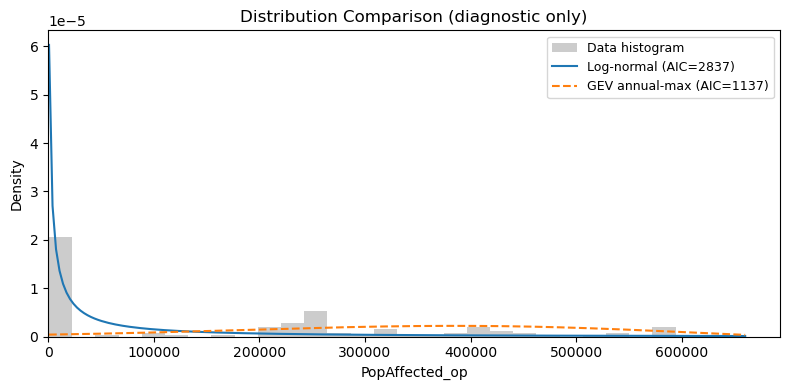

In [28]:
# =========================
# Section 6C — Alternative Distribution Comparison (DIAGNOSTIC ONLY)
# =========================
# Compares GPD (fitted to exceedances) with Log-normal and GEV (fitted to full/annual-max data).
# This is a heuristic comparison — GPD is theoretically motivated by EVT for exceedances;
# the alternatives are fitted differently and serve only as a sanity check.

impact_vals = impact_peak_series.dropna().astype(float).values
impact_vals_pos = impact_vals[impact_vals > 0]  # log-normal needs positive values

# --- 1. GPD (already fitted, compute log-likelihood on exceedances) ---
exc_above = impact_vals[impact_vals > u_evt2] - u_evt2
gpd_ll = np.sum(stats.genpareto.logpdf(exc_above, c=xi_evt2, loc=0.0, scale=sigma_evt2))
gpd_k = 2  # xi, sigma
gpd_aic = 2 * gpd_k - 2 * gpd_ll
gpd_bic = gpd_k * np.log(len(exc_above)) - 2 * gpd_ll

# --- 2. Log-normal (fitted to all positive impact values) ---
try:
    ln_shape, ln_loc, ln_scale = stats.lognorm.fit(impact_vals_pos, floc=0)
    ln_ll = np.sum(stats.lognorm.logpdf(impact_vals_pos, ln_shape, loc=0, scale=ln_scale))
    ln_k = 2  # shape, scale
    ln_aic = 2 * ln_k - 2 * ln_ll
    ln_bic = ln_k * np.log(len(impact_vals_pos)) - 2 * ln_ll
except Exception as e:
    _log(f"Log-normal fit failed: {e}")
    ln_aic = ln_bic = np.nan

# --- 3. GEV (fitted to annual maxima) ---
annual_max = impact_peak_series.groupby(impact_peak_series.index.year).max().dropna().values
if len(annual_max) >= 5:
    try:
        gev_c, gev_loc, gev_scale = stats.genextreme.fit(annual_max)
        gev_ll = np.sum(stats.genextreme.logpdf(annual_max, gev_c, loc=gev_loc, scale=gev_scale))
        gev_k = 3  # shape, loc, scale
        gev_aic = 2 * gev_k - 2 * gev_ll
        gev_bic = gev_k * np.log(len(annual_max)) - 2 * gev_ll
    except Exception as e:
        _log(f"GEV fit failed: {e}")
        gev_aic = gev_bic = np.nan
else:
    _log(f"Too few annual maxima ({len(annual_max)}) for GEV fit.")
    gev_aic = gev_bic = np.nan

# --- Summary table ---
comp_df = pd.DataFrame({
    "Distribution": ["GPD (exceedances)", "Log-normal (all events)", "GEV (annual max)"],
    "n_data": [len(exc_above), len(impact_vals_pos), len(annual_max) if len(annual_max) >= 5 else 0],
    "AIC": [gpd_aic, ln_aic, gev_aic],
    "BIC": [gpd_bic, ln_bic, gev_bic],
})
_log("Alternative distribution comparison (lower AIC/BIC = better fit within same dataset):")
_log("NOTE: GPD is fitted to exceedances only; log-normal/GEV to different data subsets. Direct AIC comparison is heuristic.")
display(comp_df)

# --- Visual: PDF overlay on histogram ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(impact_vals_pos, bins=30, density=True, alpha=0.4, color="gray", label="Data histogram")

x_plot = np.linspace(max(impact_vals_pos.min(), 1), impact_vals_pos.max(), 200)

# Log-normal PDF
if np.isfinite(ln_aic):
    ax.plot(x_plot, stats.lognorm.pdf(x_plot, ln_shape, loc=0, scale=ln_scale),
            label=f"Log-normal (AIC={ln_aic:.0f})", linewidth=1.5)

# GEV PDF (rescaled from annual-max domain — approximate only)
if np.isfinite(gev_aic):
    ax.plot(x_plot, stats.genextreme.pdf(x_plot, gev_c, loc=gev_loc, scale=gev_scale),
            label=f"GEV annual-max (AIC={gev_aic:.0f})", linewidth=1.5, linestyle="--")

ax.set_xlabel("PopAffected_op")
ax.set_ylabel("Density")
ax.set_title("Distribution Comparison (diagnostic only)")
ax.legend(fontsize=9)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()


In [ ]:
# =========================
# Section 7 — REFORECAST FOOTPRINT / IMPACT LIBRARY (GloFAS v4 reforecast GRIB) — MONTHLY-ONLY MODE (PYGRIB)
# =========================
#
# Design (as agreed):
# - Detect events on their peak (verifying) date, using the SAME detection metric as historical:
#     Amax_km2(t) = largest contiguous patch (RP>=T0_YEARS) area in km²
# - Decluster in time with DECLUSTER_DAYS (same as historical)
# - Gate compute cost: only compute depth+impact for detected peak timesteps
# - Keep rich keys: year/month/grib_path/init_time/member/lead_time/valid_time + audit metrics
# - Store outputs as Parquet/CSV in OUTPUT_DIR/reforecast_library/
#
# Notes:
# - We intentionally keep many candidate footprints; to avoid extreme duplication from overlapping inits,
#   we deduplicate by verifying_date and keep top DEDUP_TOPK events per day (configurable).
# - MONTHLY-ONLY MODE: reads monthly files under:
#     <...>/<YEAR>/_staging/extract/<YEAR>_<MM>/data.grib
#   This avoids creating a 50GB yearly file and avoids needing extra disk during concatenation.
# - Optional: delete monthly folders after successful processing (OFF by default).
# - Uses pygrib to avoid cfgrib Windows Errno 22 issues on large GRIBs.

from __future__ import annotations

import gc
import re
import shutil
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd

def _log(msg: str):
    print(f"[NB4-CAT] {msg}")

event_registry_rfc = pd.DataFrame()
impacts_by_admin_reforecast = pd.DataFrame()

if RUN_REFORECAST_LIBRARY:

    # ---------------------------
    # pygrib import (fail fast)
    # ---------------------------
    try:
        import pygrib
    except Exception as e:
        raise ImportError(
            "pygrib is required for Section 7 (Windows-safe GRIB reading).\n"
            "Install (conda-forge) then restart kernel:\n"
            "  conda install -c conda-forge pygrib eccodes\n"
        ) from e

    # ---------------------------------------------------------------------
    # USER PARAMS
    # ---------------------------------------------------------------------
    # Set RFC_YEARS to a list of years to process. Single year: [2003]
    RFC_YEARS = list(range(2008, 2012))  # <<< CHANGE THIS RANGE AS NEEDED

    RFC_GRIB_BASE = Path(
        r"G:\My Drive\GLOFAS_ImpactFloodForecasting_PHL\data\raw\glofas\reforecast\version_4_0"
        r"\consolidated\discharge\grib2\area_35_63_4_131"
    )

    # Optional disk saving: delete each monthly folder after it is fully processed (impacts written)
    DELETE_MONTH_AFTER_DONE = False  # <<< set True only after you trust the outputs

    # Resume / checkpoint controls
    RFC_MONTH_START = 1     # skip months < this value (1=Jan). Set e.g. 7 to resume from July.
    RFC_RESUME      = True # if True, auto-skip months whose checkpoint files already exist.

    # Which GRIB variable to use for discharge
    # In your file it is shortName="dis24" (Mean discharge in the last 24 hours)
    RFC_SHORTNAME = "dis24"

    for RFC_YEAR in RFC_YEARS:
        RFC_EXTRACT_ROOT = RFC_GRIB_BASE / str(RFC_YEAR) / "_staging" / "extract"

        if not RFC_EXTRACT_ROOT.exists():
            _log(f"WARNING: Extract root not found for {RFC_YEAR}, skipping: {RFC_EXTRACT_ROOT}")
            continue

        _log("=" * 60)
        _log(f"Processing RFC_YEAR={RFC_YEAR}")
        _log("=" * 60)

        # ---------------------------------------------------------------------
        # Output dirs
        # ---------------------------------------------------------------------
        LIB_DIR = OUTPUT_DIR / "reforecast_library"
        LIB_DIR.mkdir(parents=True, exist_ok=True)

        # Write admin-impacts per month to avoid huge RAM usage
        IMPACTS_OUT_DIR = LIB_DIR / "impacts_by_admin_reforecast_library" / f"year={RFC_YEAR}"
        IMPACTS_OUT_DIR.mkdir(parents=True, exist_ok=True)

        _log(f"Outputs will be written under: {LIB_DIR}")

        # ---------------------------------------------------------------------
        # Quick-test knobs (set to None for full runs)
        # ---------------------------------------------------------------------
        RFC_MAX_MEMBERS: int | None = None       # e.g., 2 for acceptance test; None = all
        RFC_MAX_STEPS: int | None = None         # e.g., 3 for acceptance test; None = all
        RFC_MAX_INITS_PER_FILE: int | None = None  # per-month file; e.g., 2 for debug; None = all

        # ---------------------------------------------------------------------
        # Detection/footprint cells and EVT1 params
        # ---------------------------------------------------------------------
        det_cells = list(support_cells_present)  # must match grid_index mapping
        p_det = evt_params.set_index("cell_id").loc[det_cells].copy()
        det_lats = p_det["lat"].astype(float).values
        det_lons = p_det["lon"].astype(float).values

        u_det     = p_det["u"].astype(float).values[None, :]
        xi_det    = p_det["xi"].astype(float).values[None, :]
        sigma_det = p_det["sigma"].astype(float).values[None, :]
        lam_det   = p_det["lam"].astype(float).values[None, :]

        # Pre-compute per-cell discharge threshold for T0_YEARS RP (inverse GPD quantile).
        # Replaces discharge_to_return_period() in the inner step loop (100-500x fewer GPD evals).
        _lam_T0  = lam_det.ravel() * float(T0_YEARS)       # shape (N_cells,)
        _xi_flat = xi_det.ravel()
        _near0   = np.isclose(_xi_flat, 0.0)
        _y_T0    = np.where(
            _near0,
            np.log(_lam_T0),                                # xi~0: y = ln(lam*T0)
            (np.power(_lam_T0, _xi_flat) - 1.0) / _xi_flat # xi!=0: y = ((lam*T0)^xi - 1)/xi
        )
        q_T0_det = (u_det.ravel() + sigma_det.ravel() * _y_T0).astype("float32")
        del _lam_T0, _xi_flat, _near0, _y_T0

        # Footprint cells: keep EXACTLY the same as Section 5 for NB3 parity
        fp_cells = list(det_cells)
        p_fp = p_det
        fp_lats = det_lats
        fp_lons = det_lons

        u_fp     = u_det
        xi_fp    = xi_det
        sigma_fp = sigma_det
        lam_fp   = lam_det

        # Connected-components setup (same as historical detection)
        structure = generate_binary_structure(2, CC_CONNECTIVITY)
        valid_mask = (grid_index >= 0)

        # ---------------------------------------------------------------------
        # Helpers
        # ---------------------------------------------------------------------
        def _dt_from_grib(dataDate: int, dataTime: int) -> pd.Timestamp:
            # dataTime is HHMM (often 0)
            return pd.to_datetime(f"{int(dataDate):08d}{int(dataTime):04d}", format="%Y%m%d%H%M")

        def _ensure_360(lons_deg: np.ndarray, grid_lon_1d: np.ndarray) -> np.ndarray:
            """Convert -180..180 lons to 0..360 if GRIB grid uses 0..360."""
            lons_deg = np.asarray(lons_deg, dtype=float)
            if float(np.nanmax(grid_lon_1d)) > 180.0:
                return np.where(lons_deg < 0, lons_deg + 360.0, lons_deg)
            return lons_deg

        def _nearest_index_1d(arr_1d: np.ndarray, targets: np.ndarray) -> np.ndarray:
            """
            Fast nearest-index for monotonic 1D arrays.
            Falls back to argmin if array is not monotonic.
            """
            arr = np.asarray(arr_1d, dtype=float)
            t = np.asarray(targets, dtype=float)

            # detect monotonicity
            dif = np.diff(arr)
            is_asc = np.all(dif >= 0)
            is_desc = np.all(dif <= 0)
            if not (is_asc or is_desc):
                # fallback (safe)
                out = np.empty(len(t), dtype=int)
                for i, x in enumerate(t):
                    out[i] = int(np.argmin(np.abs(arr - x)))
                return out

            rev = False
            arr_use = arr
            if is_desc:
                arr_use = arr[::-1]
                rev = True

            # searchsorted assumes ascending
            idx = np.searchsorted(arr_use, t, side="left")
            idx = np.clip(idx, 1, len(arr_use) - 1)

            left = arr_use[idx - 1]
            right = arr_use[idx]
            choose_right = (np.abs(right - t) < np.abs(t - left))
            idx_final = np.where(choose_right, idx, idx - 1).astype(int)

            if rev:
                idx_final = (len(arr) - 1) - idx_final

            return idx_final

        def _build_msg_index(grbs, shortName: str, scan_limit: int | None = None):
            """
            Build an index: (dataDate, dataTime, endStep, perturbationNumber) -> message_number
            Also returns sorted unique inits, steps (hours), members, and a template message for grid.
            """
            msg_index = {}
            inits = set()
            steps = set()
            members = set()
            template_msgnum = None

            grbs.rewind()
            for i, g in enumerate(grbs, start=1):
                if scan_limit is not None and i > scan_limit:
                    break

                try:
                    if g.shortName != shortName:
                        continue
                except Exception:
                    continue

                try:
                    dd = int(g.dataDate)
                    tt = int(g.dataTime)
                    es = int(getattr(g, "endStep", None) if getattr(g, "endStep", None) is not None else g.endStep)
                    pn = int(g.perturbationNumber)
                except Exception:
                    continue

                msg_index[(dd, tt, es, pn)] = i
                inits.add((dd, tt))
                steps.add(es)
                members.add(pn)

                if template_msgnum is None:
                    template_msgnum = i

            if not msg_index:
                raise RuntimeError(f"No messages found for shortName='{shortName}' in GRIB file.")

            return (
                msg_index,
                sorted(inits),
                sorted(steps),
                sorted(members),
                template_msgnum,
            )

        def _compute_amax_from_active(active_vec: np.ndarray) -> float:
            """
            active_vec: boolean array (n_cells,) aligned with det_cells ordering (grid_index mapping)
            returns Amax_km2
            Uses bounding-box crop before connected-components labeling for speed
            (active cells are typically <5% of the full grid).
            """
            if not np.any(active_vec):
                return 0.0
            g = np.zeros(grid_index.shape, dtype=bool)
            g[valid_mask] = active_vec[grid_index[valid_mask]]
            if not g.any():
                return 0.0
            # Bounding-box crop: label only the active subgrid (5-30x faster)
            active_idx = np.argwhere(g)
            r0, r1 = int(active_idx[:, 0].min()), int(active_idx[:, 0].max()) + 1
            c0, c1 = int(active_idx[:, 1].min()), int(active_idx[:, 1].max()) + 1
            # Pad by 1 to avoid edge effects in connectivity
            r0 = max(r0 - 1, 0)
            c0 = max(c0 - 1, 0)
            r1 = min(r1 + 1, g.shape[0])
            c1 = min(c1 + 1, g.shape[1])
            g_sub = g[r0:r1, c0:c1]
            area_sub = area_grid_km2[r0:r1, c0:c1]
            labs_sub, nlab = label(g_sub, structure=structure)
            if nlab == 0:
                return 0.0
            areas = np.bincount(labs_sub.ravel(), weights=area_sub.ravel())
            return float(np.max(areas[1:])) if len(areas) > 1 else 0.0

        @dataclass(frozen=True)
        class MonthlyGribItem:
            year: int
            month: int
            grib_path: Path

        def discover_monthly_gribs(extract_root: Path, year: int) -> list[MonthlyGribItem]:
            """
            Expect folders like: <extract_root>/<YYYY>_<MM>/data.grib
            """
            items: list[MonthlyGribItem] = []
            pat = re.compile(rf"^{year}_(\d{{2}})$")
            for d in sorted(extract_root.iterdir()):
                if not d.is_dir():
                    continue
                m = pat.match(d.name)
                if not m:
                    continue
                mm = int(m.group(1))
                fp = d / "data.grib"
                if not fp.exists() or fp.stat().st_size == 0:
                    _log(f"⚠ Missing/empty monthly GRIB: {fp}")
                    continue
                items.append(MonthlyGribItem(year=year, month=mm, grib_path=fp))
            if not items:
                raise RuntimeError(f"No monthly GRIBs found under: {extract_root} for year={year}")
            return items

        # ---------------------------------------------------------------------
        # Inventory
        # ---------------------------------------------------------------------
        inv = discover_monthly_gribs(RFC_EXTRACT_ROOT, RFC_YEAR)
        _log(f"Reforecast MONTHLY inventory: {len(inv)} file(s) for {RFC_YEAR} (root={RFC_EXTRACT_ROOT})")


        # YEAR-LEVEL SKIP: if registry already complete, skip entire year
        _year_reg = LIB_DIR / f"event_registry_reforecast_library_{RFC_YEAR}.parquet"
        if RFC_RESUME and _year_reg.exists():
            _log(f"[RESUME] Year {RFC_YEAR} registry exists \u2014 skipping entire year.")
            event_registry_rfc = pd.read_parquet(_year_reg)
            continue
        # ---------------------------------------------------------------------
        # STEP 7A+7C — Single-pass: detect peaks AND compute impacts in same GRIB open
        # One open per monthly file; impacts written immediately after detection.
        # ---------------------------------------------------------------------
        raw_events = []
        pop_summary_rows = []
        CKPT_CAND_DIR = LIB_DIR / "checkpoints" / f"year={RFC_YEAR}"
        CKPT_CAND_DIR.mkdir(parents=True, exist_ok=True)

        for item in inv:
            mm = item.month

            # ── a) Manual month skip ────────────────────────────────────
            if mm < RFC_MONTH_START:
                _log(f"  Skipping month {mm:02d} (< RFC_MONTH_START={RFC_MONTH_START})")
                continue

            _ckpt_cand = CKPT_CAND_DIR / f"raw_candidates_{RFC_YEAR}_{mm:02d}.parquet"
            _ckpt_imp  = IMPACTS_OUT_DIR / f"impacts_by_admin_{RFC_YEAR}_{mm:02d}.parquet"

            # ── b) Full resume: both checkpoints exist → load, skip GRIB open ─
            if RFC_RESUME and _ckpt_cand.exists() and _ckpt_imp.exists():
                _log(f"  [RESUME] Month {mm:02d}: fully done — loading from checkpoints")
                raw_events.extend(pd.read_parquet(_ckpt_cand).to_dict("records"))
                _imp_df = pd.read_parquet(_ckpt_imp)
                for _sk, _grp in _imp_df.groupby("stable_key"):
                    _tot = _grp.groupby("depth_thr_m")["affected_pop"].sum()
                    _row = {"stable_key": _sk}
                    _row.update({depth_thr_to_col(t): float(_tot.get(t, 0.0))
                                  for t in DEPTH_THRESHOLDS})
                    _row["PopAffected_op"]  = float(_tot.get(DEPTH_PRIMARY, 0.0))
                    _row["PopAffected_sat"] = float(_tot.get(DEPTH_SAT, 0.0))
                    pop_summary_rows.append(_row)
                continue

            # ── c) Partial: candidates only → redo month from scratch ────────────
            if RFC_RESUME and _ckpt_cand.exists():
                _log(f"  [RESUME] Month {mm:02d}: partial checkpoint — reprocessing full month")
                _ckpt_cand.unlink(missing_ok=True)

            # ── d) Normal: Phase A + Phase C in one GRIB open ────────────────
            _log(f"Opening monthly GRIB {item.year}_{mm:02d}: {item.grib_path}")

            grbs = pygrib.open(str(item.grib_path))

            msg_index, inits, steps_hours, members, template_msgnum = _build_msg_index(
                grbs, shortName=RFC_SHORTNAME, scan_limit=None
            )

            if RFC_MAX_INITS_PER_FILE is not None and len(inits) > RFC_MAX_INITS_PER_FILE:
                inits = inits[:RFC_MAX_INITS_PER_FILE]
            if RFC_MAX_STEPS is not None and len(steps_hours) > RFC_MAX_STEPS:
                steps_hours = steps_hours[:RFC_MAX_STEPS]
            if RFC_MAX_MEMBERS is not None and len(members) > RFC_MAX_MEMBERS:
                members = members[:RFC_MAX_MEMBERS]

            tmpl = grbs.message(int(template_msgnum))
            lats2d, lons2d = tmpl.latlons()
            lat1d = lats2d[:, 0].astype(float)
            lon1d = lons2d[0, :].astype(float)

            det_lons_use = _ensure_360(det_lons, lon1d)
            fp_lons_use  = _ensure_360(fp_lons, lon1d)
            det_i = _nearest_index_1d(lat1d, det_lats)
            det_j = _nearest_index_1d(lon1d, det_lons_use)
            fp_i = det_i
            fp_j = det_j

            steps_hours_arr = np.asarray(steps_hours, dtype=int)

            # ------------------------------------------------------------------
            # Phase A: detect peaks (same logic as original 7A)
            # ------------------------------------------------------------------
            raw_events_this_month = []

            for (dd, tt) in inits:
                init_dt = _dt_from_grib(dd, tt)
                vt = pd.DatetimeIndex(init_dt + pd.to_timedelta(steps_hours_arr, unit="h"))

                for pn in members:
                    amax      = np.zeros(len(steps_hours_arr), dtype=float)
                    n_active  = np.zeros(len(steps_hours_arr), dtype=int)
                    msgnum_by_step: dict[int, int] = {}

                    for si, step_h in enumerate(steps_hours_arr):
                        key = (int(dd), int(tt), int(step_h), int(pn))
                        msgnum = msg_index.get(key)
                        if msgnum is None:
                            amax[si] = 0.0
                            continue

                        msgnum_by_step[int(step_h)] = int(msgnum)

                        msg  = grbs.message(int(msgnum))
                        vals = msg.values
                        q    = vals[det_i, det_j].astype("float32")

                        active_vec   = (q >= q_T0_det)        # threshold comparison only -- no GPD eval
                        n_active[si] = int(np.sum(active_vec))
                        amax[si]     = _compute_amax_from_active(active_vec)
                        del vals, q, active_vec, msg

                    A_series = pd.Series(amax, index=vt, name="Amax_km2").sort_index()
                    peaks = peak_pick(
                        A_series,
                        threshold=float(A_MIN_KM2),
                        decluster_days=int(DECLUSTER_DAYS),
                    )

                    for pk in peaks:
                        pk64   = np.datetime64(pd.to_datetime(pk))
                        diffs  = np.abs(
                            (vt.values - pk64).astype("timedelta64[s]").astype(np.int64)
                        )
                        si_pk      = int(np.argmin(diffs))
                        step_h_pk  = int(steps_hours_arr[si_pk])
                        msgnum_pk  = msgnum_by_step.get(step_h_pk)

                        # Lazy RP: compute only for this peak step (audit metrics only)
                        if msgnum_pk is not None:
                            _msg_pk = grbs.message(int(msgnum_pk))
                            _q_pk   = _msg_pk.values[det_i, det_j].astype("float32")
                            _rp_pk  = discharge_to_return_period(
                                _q_pk[None, :], u_det, sigma_det, xi_det, lam_det, rp_cap=RP_CAP
                            ).ravel()
                            _rp_p50    = float(np.nanpercentile(_rp_pk, 50))
                            _rp_p90    = float(np.nanpercentile(_rp_pk, 90))
                            _rp_p99    = float(np.nanpercentile(_rp_pk, 99))
                            _frac_ge10 = float(np.mean(_rp_pk >= 10.0))
                            _frac_ge20 = float(np.mean(_rp_pk >= 20.0))
                            del _msg_pk, _q_pk, _rp_pk
                        else:
                            _rp_p50 = _rp_p90 = _rp_p99 = _frac_ge10 = _frac_ge20 = np.nan

                        stable_key = (
                            f"{RFC_YEAR}_{mm:02d}_{int(pn)}_"
                            f"{pd.to_datetime(pk).strftime('%Y%m%dT%H%M')}"
                        )

                        raw_events_this_month.append({
                            "source":              "reforecast_candidate",
                            "year":                int(item.year),
                            "month":               int(mm),
                            "grib_path":           str(item.grib_path),
                            "init_time":           pd.to_datetime(init_dt),
                            "member":              int(pn),
                            "valid_time":          pd.to_datetime(pk),
                            "lead_time_days":      float(step_h_pk / 24.0),
                            "lead_time_hours":     int(step_h_pk),
                            "step_index":          int(si_pk),
                            "grib_msgnum":         int(msgnum_pk) if msgnum_pk is not None else np.nan,
                            "W_peak":              float(A_series.iloc[si_pk]),
                            "Amax_km2_peak":       float(A_series.iloc[si_pk]),
                            "n_active_cells_peak": int(n_active[si_pk]),
                            "rp_p50":              _rp_p50,
                            "rp_p90":              _rp_p90,
                            "rp_p99":              _rp_p99,
                            "frac_rp_ge10":        _frac_ge10,
                            "frac_rp_ge20":        _frac_ge20,
                            "T0_years":            float(T0_YEARS),
                            "A_min_km2":           float(A_MIN_KM2),
                            "decluster_days":      int(DECLUSTER_DAYS),
                            "cc_connectivity":     int(CC_CONNECTIVITY),
                            "stable_key":          stable_key,
                        })

                    del amax, n_active, A_series

            # save candidate checkpoint (per-month parquet)
            ckpt_f = CKPT_CAND_DIR / f"raw_candidates_{RFC_YEAR}_{mm:02d}.parquet"
            if raw_events_this_month:
                pd.DataFrame(raw_events_this_month).to_parquet(ckpt_f, index=False)
                _log(f"  [CKPT] Saved {len(raw_events_this_month)} candidates -> {ckpt_f.name}")
            else:
                _log(f"  [CKPT] No candidates for month {mm:02d}")

            # ------------------------------------------------------------------
            # Phase C: compute per-municipality impacts (same open GRIB, no re-open)
            # ------------------------------------------------------------------
            month_rows: list = []
            pop_summary_this_month: list = []

            for ev in raw_events_this_month:
                msgnum = ev["grib_msgnum"]
                if not (isinstance(msgnum, (int, float)) and np.isfinite(msgnum)):
                    continue
                try:
                    msg   = grbs.message(int(msgnum))
                    vals  = msg.values
                    q_fp  = vals[fp_i, fp_j].astype("float32")[None, :]  # (1, n_cells)

                    rp_vals = discharge_to_return_period(
                        q_fp, u_fp, sigma_fp, xi_fp, lam_fp, rp_cap=RP_CAP
                    ).ravel()

                    # Early exit: skip expensive regridding if no cell reaches RP >= 2yr
                    if np.nanmax(rp_vals) < 2.0:
                        row = {"stable_key": ev["stable_key"]}
                        for thr in DEPTH_THRESHOLDS:
                            row[depth_thr_to_col(thr)] = 0.0
                        row["PopAffected_op"]  = 0.0
                        row["PopAffected_sat"] = 0.0
                        pop_summary_this_month.append(row)
                        del vals, q_fp, rp_vals, msg
                        continue

                    rp_df = pd.DataFrame({
                        "lat": p_fp["lat"].values.astype(float),
                        "lon": p_fp["lon"].values.astype(float),
                        "rp":  rp_vals.astype(float),
                    })
                    rp_grid_2d = build_rp_grid_from_values(rp_df, value_col="rp", fill=np.nan)
                    rp_grid_2d = rp_grid_2d.sortby("latitude").sortby("longitude")

                    depth_da = compute_depth_from_rp_nb3(
                        rp_da_2d=rp_grid_2d,
                        event_id=ev["stable_key"],
                        apply_flopros=USE_FLOPROS,
                        flood_maps=flood_maps_ev,
                    )

                    pop_use, admin_use, admin_ids_use = subset_to_depth_grid(
                        depth_da=depth_da,
                        flood_maps_ev=flood_maps_ev,
                        pop_ev=pop_ev,
                        admin_id_raster_ev=admin_id_raster_ev,
                    )

                    df_imp = aggregate_affected_population_nb3_fast(
                        pop_grid=pop_use,
                        depth_grid=depth_da.values,
                        admin_id_raster=admin_use,
                        admin_ids_present=admin_ids_use,
                        thresholds_m=DEPTH_THRESHOLDS,
                        id_to_name=admin_id_to_name,
                    )
                    df_imp["stable_key"] = ev["stable_key"]
                    df_imp["source"]     = "reforecast_library"
                    df_imp["year"]       = int(RFC_YEAR)
                    df_imp["month"]      = int(mm)

                    # event-level totals for later merge into registry
                    tot = df_imp.groupby("depth_thr_m")["affected_pop"].sum()
                    row = {"stable_key": ev["stable_key"]}
                    row.update({
                        depth_thr_to_col(thr): float(tot.get(thr, 0.0))
                        for thr in DEPTH_THRESHOLDS
                    })
                    row["PopAffected_op"]  = float(tot.get(DEPTH_PRIMARY, 0.0))
                    row["PopAffected_sat"] = float(tot.get(DEPTH_SAT,     0.0))
                    pop_summary_this_month.append(row)
                    month_rows.append(df_imp)

                    del vals, q_fp, rp_vals, msg

                except Exception as _imp_err:
                    _log(f"  WARNING: impact failed for {ev['stable_key']}: {_imp_err}")

            if month_rows:
                df_month = pd.concat(month_rows, ignore_index=True)
                safe_write(df_month, IMPACTS_OUT_DIR / f"impacts_by_admin_{RFC_YEAR}_{mm:02d}")
                _log(f"  wrote month impacts rows: {len(df_month):,} -> {RFC_YEAR}_{mm:02d}")

            # accumulate for year-level dedup (the key fix vs previous broken version)
            raw_events.extend(raw_events_this_month)
            pop_summary_rows.extend(pop_summary_this_month)

            grbs.close()
            gc.collect()

        # ---------------------------------------------------------------------
        # STEP 7B — Year-level deduplication
        # ---------------------------------------------------------------------
        raw_events_df = pd.DataFrame(raw_events)
        _log(f"Detected candidate peaks (pre-dedup): {len(raw_events_df):,}")

        if raw_events_df.empty:
            _log("No reforecast events detected for this year.")
            event_registry_rfc       = pd.DataFrame()
            impacts_by_admin_reforecast = pd.DataFrame()
        else:
            raw_events_df["peak_date"]      = pd.to_datetime(raw_events_df["valid_time"])
            raw_events_df["verifying_date"] = raw_events_df["peak_date"].dt.floor("D")
            raw_events_df = raw_events_df.sort_values(
                ["verifying_date", "W_peak"], ascending=[True, False]
            )
            library = (
                raw_events_df
                .groupby("verifying_date")
                .head(int(DEDUP_TOPK))
                .reset_index(drop=True)
            )
            library = library.sort_values(
                ["verifying_date", "W_peak"], ascending=[True, False]
            ).reset_index(drop=True)
            library["event_id"] = [f"RFC_{RFC_YEAR}_{i:05d}" for i in range(len(library))]
            library["source"]   = "reforecast_library"
            event_registry_rfc  = library.copy()
            _log(f"Library events (post-dedup by day): {len(event_registry_rfc):,} (topK={DEDUP_TOPK})")

            # save raw candidates for audit
            safe_write(
                raw_events_df,
                LIB_DIR / f"event_registry_reforecast_candidates_raw_{RFC_YEAR}",
            )

            # merge PopAffected columns back via stable_key
            pop_sum_df = (
                pd.DataFrame(pop_summary_rows)
                .drop_duplicates(subset=["stable_key"])
            )
            event_registry_rfc = event_registry_rfc.merge(pop_sum_df, on="stable_key", how="left")

            # save final yearly registry (with PopAffected_* columns)
            safe_write(
                event_registry_rfc,
                LIB_DIR / f"event_registry_reforecast_library_{RFC_YEAR}",
            )

            # impacts are already saved per-month under IMPACTS_OUT_DIR
            impacts_by_admin_reforecast = pd.DataFrame()

            # -----------------------------------------------------------------
            # STEP 7D — QA checks
            # -----------------------------------------------------------------
            _log("QA: basic integrity checks")
            miss = (
                int(event_registry_rfc["PopAffected_op"].isna().sum())
                if "PopAffected_op" in event_registry_rfc.columns
                else len(event_registry_rfc)
            )
            _log(f"  missing PopAffected_op: {miss}/{len(event_registry_rfc)}")

            if (
                "PopAffected_op" in event_registry_rfc.columns
                and event_registry_rfc["PopAffected_op"].notna().any()
            ):
                import matplotlib.pyplot as plt
                plt.figure(figsize=(6, 4))
                plt.scatter(
                    event_registry_rfc["W_peak"],
                    event_registry_rfc["PopAffected_op"],
                    s=12,
                )
                plt.xlabel("Amax_km2 peak (W_peak)")
                plt.ylabel("PopAffected_op")
                plt.title(f"Reforecast library sanity: magnitude vs impact ({RFC_YEAR})")
                plt.tight_layout()
                plt.close()

            _log(f"Section 7 complete (single-pass) for year={RFC_YEAR}")

In [ ]:
# Save the expensive output so you can restart later if needed
LIB_DIR = OUTPUT_DIR / "reforecast_library"
LIB_DIR.mkdir(parents=True, exist_ok=True)

safe_write(raw_events, LIB_DIR / f"raw_events_reforecast_{RFC_YEAR}_prededup")
print("Saved raw_events:", len(raw_events))

In [ ]:
# =========================
# Checkpoint helper — save/load heavy intermediates for restart-safe resume
# =========================

import json
import numpy as np
import xarray as xr
from pathlib import Path


def _resolve_output_dir() -> Path:
    if "OUTPUT_DIR" in globals() and globals()["OUTPUT_DIR"] is not None:
        return Path(globals()["OUTPUT_DIR"])

    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        cand = p / "data" / "processed" / "impact_catalogue_catmodel"
        if cand.exists():
            return cand

    # last-resort fallback
    fallback = cwd / "data" / "processed" / "impact_catalogue_catmodel"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


RFC_YEAR = int(globals().get("RFC_YEAR", 2005))
OUTPUT_DIR_RESOLVED = _resolve_output_dir()
CKPT_DIR = OUTPUT_DIR_RESOLVED / "reforecast_library" / "checkpoints" / f"year={RFC_YEAR}"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

flood_maps_ckpt = CKPT_DIR / "flood_maps_ev.nc"
pop_ev_ckpt = CKPT_DIR / "pop_ev.npy"
admin_raster_ckpt = CKPT_DIR / "admin_id_raster_ev.npy"
admin_map_ckpt = CKPT_DIR / "admin_id_to_name.json"
meta_ckpt = CKPT_DIR / "checkpoint_meta.json"

# Save if variables are available in memory
saved = []
if "flood_maps_ev" in globals() and flood_maps_ev is not None:
    flood_maps_ev.to_netcdf(flood_maps_ckpt)
    saved.append(str(flood_maps_ckpt.name))

if "pop_ev" in globals() and pop_ev is not None:
    np.save(pop_ev_ckpt, np.asarray(pop_ev))
    saved.append(str(pop_ev_ckpt.name))

if "admin_id_raster_ev" in globals() and admin_id_raster_ev is not None:
    np.save(admin_raster_ckpt, np.asarray(admin_id_raster_ev))
    saved.append(str(admin_raster_ckpt.name))

if "admin_id_to_name" in globals() and isinstance(admin_id_to_name, dict):
    with open(admin_map_ckpt, "w", encoding="utf-8") as f:
        json.dump({str(k): v for k, v in admin_id_to_name.items()}, f, ensure_ascii=False)
    saved.append(str(admin_map_ckpt.name))

meta = {
    "year": RFC_YEAR,
    "output_dir_resolved": str(OUTPUT_DIR_RESOLVED),
    "saved_files": saved,
    "evt_params_parquet": str(globals().get("EVT1_PARAMS_PARQUET", "")),
}
with open(meta_ckpt, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(f"OUTPUT_DIR resolved: {OUTPUT_DIR_RESOLVED}")
print(f"Checkpoint directory: {CKPT_DIR}")
print(f"Saved files: {saved if saved else 'none (vars not in memory yet)'}")
print("Tip: run this once after Section 5/6 setup, then resume works after kernel restart.")

In [ ]:
# =========================
# CHECKPOINT RESTORE — load Cell 18 artifacts for Cell 28 after kernel restart
# =========================

import json
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path


def _resolve_output_dir() -> Path:
    if "OUTPUT_DIR" in globals() and globals()["OUTPUT_DIR"] is not None:
        return Path(globals()["OUTPUT_DIR"])
    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        cand = p / "data" / "processed" / "impact_catalogue_catmodel"
        if cand.exists():
            return cand
    fallback = cwd / "data" / "processed" / "impact_catalogue_catmodel"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


RFC_YEAR = int(globals().get("RFC_YEAR", 2005))
OUTPUT_DIR_RESOLVED = _resolve_output_dir()
CKPT_DIR = OUTPUT_DIR_RESOLVED / "reforecast_library" / "checkpoints" / f"year={RFC_YEAR}"

if not CKPT_DIR.exists():
    raise FileNotFoundError(f"Checkpoint folder not found: {CKPT_DIR}. Run Cell 19 checkpoint save first.")

loaded = []
missing = []

# heavy arrays/maps
if (CKPT_DIR / "flood_maps_ev.nc").exists():
    flood_maps_ev = xr.open_dataarray(CKPT_DIR / "flood_maps_ev.nc").load()
    loaded.append("flood_maps_ev")
else:
    missing.append("flood_maps_ev.nc")

if (CKPT_DIR / "pop_ev.npy").exists():
    pop_ev = np.load(CKPT_DIR / "pop_ev.npy", allow_pickle=False)
    loaded.append("pop_ev")
else:
    missing.append("pop_ev.npy")

if (CKPT_DIR / "admin_id_raster_ev.npy").exists():
    admin_id_raster_ev = np.load(CKPT_DIR / "admin_id_raster_ev.npy", allow_pickle=False)
    loaded.append("admin_id_raster_ev")
else:
    missing.append("admin_id_raster_ev.npy")

if (CKPT_DIR / "admin_id_to_name.json").exists():
    with open(CKPT_DIR / "admin_id_to_name.json", "r", encoding="utf-8") as f:
        _tmp = json.load(f)
    admin_id_to_name = {int(k): v for k, v in _tmp.items()}
    loaded.append("admin_id_to_name")
else:
    missing.append("admin_id_to_name.json")

# params/cell lists used by Cell 28
if (CKPT_DIR / "evt_params.parquet").exists():
    evt_params = pd.read_parquet(CKPT_DIR / "evt_params.parquet")
    loaded.append("evt_params")
else:
    missing.append("evt_params.parquet")

if (CKPT_DIR / "support_cells_present.json").exists():
    with open(CKPT_DIR / "support_cells_present.json", "r", encoding="utf-8") as f:
        support_cells_present = json.load(f)
    loaded.append("support_cells_present")

if (CKPT_DIR / "runtime_config.json").exists():
    with open(CKPT_DIR / "runtime_config.json", "r", encoding="utf-8") as f:
        cfg = json.load(f)
    DEPTH_THRESHOLDS = cfg.get("DEPTH_THRESHOLDS", globals().get("DEPTH_THRESHOLDS", [0.1, 0.3, 0.5]))
    DEPTH_PRIMARY = float(cfg.get("DEPTH_PRIMARY", globals().get("DEPTH_PRIMARY", 0.02)))
    DEPTH_OP = float(cfg.get("DEPTH_OP", globals().get("DEPTH_OP", 0.1)))
    DEPTH_SAT = float(cfg.get("DEPTH_SAT", globals().get("DEPTH_SAT", 0.3)))
    USE_FLOPROS = bool(cfg.get("USE_FLOPROS", globals().get("USE_FLOPROS", True)))
    RP_CAP = float(cfg.get("RP_CAP", globals().get("RP_CAP", 500.0)))
    RFC_SHORTNAME = str(cfg.get("RFC_SHORTNAME", globals().get("RFC_SHORTNAME", "dis24")))
    loaded.append("runtime_config")

# quick compatibility checks for Cell 28
required_symbols = [
    "discharge_to_return_period",
    "build_rp_grid_from_values",
    "compute_depth_from_rp_nb3",
    "subset_to_depth_grid",
    "aggregate_affected_population_nb3_fast",
    "safe_write",
]
missing_symbols = [name for name in required_symbols if name not in globals()]

print(f"Checkpoint dir: {CKPT_DIR}")
print(f"Loaded: {loaded}")
if missing:
    print(f"Missing checkpoint files: {missing}")
if missing_symbols:
    print(f"Missing function definitions for Cell 28: {missing_symbols}")
    print("Run only the setup/function-definition cells (top of notebook), not Cell 18.")
else:
    print("Cell 28 prerequisites look ready.")

In [ ]:
# =========================
# Section 7B–7D RESUME (no re-run of 7A)
# =========================

import json
import numpy as np
import pandas as pd
import gc
import xarray as xr
from pathlib import Path


# Safe logger for this cell (avoid recursion if _log is missing or overwritten)
_external_log = globals().get("_log", None)
def _log_local(msg):
    if callable(_external_log):
        try:
            _external_log(msg)
            return
        except Exception:
            pass
    print(msg)


def _resolve_output_dir() -> Path:
    if "OUTPUT_DIR" in globals() and globals()["OUTPUT_DIR"] is not None:
        return Path(globals()["OUTPUT_DIR"])

    cwd = Path.cwd()
    for p in [cwd, *cwd.parents]:
        cand = p / "data" / "processed" / "impact_catalogue_catmodel"
        if cand.exists():
            return cand

    fallback = cwd / "data" / "processed" / "impact_catalogue_catmodel"
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


# ---- REQUIRED: set RFC_YEAR and DEDUP_TOPK
RFC_YEAR = int(globals().get("RFC_YEAR", 2005))
RFC_SHORTNAME = "dis24"
FORCE_LOAD_RAW_EVENTS_FROM_DISK = True
DEDUP_TOPK = int(globals().get("DEDUP_TOPK", 50))
print("Using DEDUP_TOPK =", DEDUP_TOPK)

# Ensure output dirs
OUTPUT_DIR_RESOLVED = _resolve_output_dir()
LIB_DIR = OUTPUT_DIR_RESOLVED / "reforecast_library"
LIB_DIR.mkdir(parents=True, exist_ok=True)
IMPACTS_OUT_DIR = LIB_DIR / "impacts_by_admin_reforecast_library" / f"year={RFC_YEAR}"
IMPACTS_OUT_DIR.mkdir(parents=True, exist_ok=True)
_log_local(f"OUTPUT_DIR resolved to: {OUTPUT_DIR_RESOLVED}")

# ---- restart-safe checkpoint auto-load for heavy intermediates
CKPT_DIR = LIB_DIR / "checkpoints" / f"year={RFC_YEAR}"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

flood_maps_ckpt = CKPT_DIR / "flood_maps_ev.nc"
pop_ev_ckpt = CKPT_DIR / "pop_ev.npy"
admin_raster_ckpt = CKPT_DIR / "admin_id_raster_ev.npy"
admin_map_ckpt = CKPT_DIR / "admin_id_to_name.json"

if "flood_maps_ev" not in globals() and flood_maps_ckpt.exists():
    flood_maps_ev = xr.open_dataarray(flood_maps_ckpt).load()
    _log_local(f"Loaded checkpoint: {flood_maps_ckpt}")

if "pop_ev" not in globals() and pop_ev_ckpt.exists():
    pop_ev = np.load(pop_ev_ckpt, allow_pickle=False)
    _log_local(f"Loaded checkpoint: {pop_ev_ckpt}")

if "admin_id_raster_ev" not in globals() and admin_raster_ckpt.exists():
    admin_id_raster_ev = np.load(admin_raster_ckpt, allow_pickle=False)
    _log_local(f"Loaded checkpoint: {admin_raster_ckpt}")

if "admin_id_to_name" not in globals() and admin_map_ckpt.exists():
    with open(admin_map_ckpt, "r", encoding="utf-8") as f:
        _tmp_map = json.load(f)
    admin_id_to_name = {int(k): v for k, v in _tmp_map.items()}
    _log_local(f"Loaded checkpoint: {admin_map_ckpt}")

required_raw_cols = {
    "year", "month", "grib_path", "valid_time", "W_peak", "grib_msgnum", "lead_time_hours", "member", "init_time"
}

def _try_read_df(base: Path) -> pd.DataFrame | None:
    p_parq = Path(f"{base}.parquet")
    p_csv = Path(f"{base}.csv")
    if p_parq.exists():
        return pd.read_parquet(p_parq)
    if p_csv.exists():
        return pd.read_csv(p_csv)
    return None

def _load_raw_events_from_disk(year: int, lib_dir: Path) -> tuple[pd.DataFrame, str]:
    preferred = [
        lib_dir / f"raw_events_reforecast_{year}_prededup",
        lib_dir / f"event_registry_reforecast_candidates_raw_{year}",
    ]
    for base in preferred:
        df = _try_read_df(base)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df, str(base)

    glob_candidates = sorted(lib_dir.glob(f"*{year}*prededup*.parquet")) + sorted(lib_dir.glob(f"*{year}*prededup*.csv"))
    glob_candidates += sorted(lib_dir.glob(f"event_registry_reforecast_candidates_raw_{year}*.parquet"))
    glob_candidates += sorted(lib_dir.glob(f"event_registry_reforecast_candidates_raw_{year}*.csv"))

    for fp in glob_candidates:
        df = pd.read_parquet(fp) if fp.suffix.lower() == ".parquet" else pd.read_csv(fp)
        if isinstance(df, pd.DataFrame) and not df.empty:
            return df, str(fp)

    raise FileNotFoundError(
        f"No raw_events file found for year={year} under {lib_dir}. "
        f"Expected e.g. raw_events_reforecast_{year}_prededup.parquet/.csv"
    )

# ---- LOAD raw_events robustly
use_disk = FORCE_LOAD_RAW_EVENTS_FROM_DISK
if not use_disk:
    in_mem_ok = isinstance(globals().get("raw_events"), pd.DataFrame) and not raw_events.empty
    if in_mem_ok and required_raw_cols.issubset(set(raw_events.columns)):
        yr_ok = ("year" in raw_events.columns) and (pd.to_numeric(raw_events["year"], errors="coerce") == RFC_YEAR).any()
        use_disk = not yr_ok
    else:
        use_disk = True

if use_disk:
    _log_local("Loading raw_events from disk (forced/required)...")
    raw_events, raw_source = _load_raw_events_from_disk(RFC_YEAR, LIB_DIR)
    _log_local(f"Loaded raw_events from: {raw_source} | rows={len(raw_events):,}")
else:
    _log_local(f"Using in-memory raw_events | rows={len(raw_events):,}")

for dt_col in ["valid_time", "init_time", "peak_date", "verifying_date"]:
    if dt_col in raw_events.columns:
        raw_events[dt_col] = pd.to_datetime(raw_events[dt_col], errors="coerce")

if "year" in raw_events.columns:
    raw_events["year"] = pd.to_numeric(raw_events["year"], errors="coerce")
    raw_events = raw_events[raw_events["year"] == RFC_YEAR].copy()

missing_cols = sorted(required_raw_cols - set(raw_events.columns))
if missing_cols:
    raise ValueError(f"Loaded raw_events is missing required columns: {missing_cols}")
if raw_events.empty:
    raise ValueError(f"Loaded raw_events is empty for RFC_YEAR={RFC_YEAR}")

# ---- 7B: dedup
raw_events = raw_events.copy()
raw_events["peak_date"] = pd.to_datetime(raw_events["valid_time"], errors="coerce")
raw_events["verifying_date"] = raw_events["peak_date"].dt.floor("D")
raw_events = raw_events.dropna(subset=["verifying_date", "W_peak"])

raw_events = raw_events.sort_values(["verifying_date", "W_peak"], ascending=[True, False])
library = raw_events.groupby("verifying_date").head(int(DEDUP_TOPK)).reset_index(drop=True)
library = library.sort_values(["verifying_date", "W_peak"], ascending=[True, False]).reset_index(drop=True)
library["event_id"] = [f"RFC_{RFC_YEAR}_{i:05d}" for i in range(len(library))]
library["source"] = "reforecast_library"

event_registry_rfc = library.copy()
_log_local(f"Library events (post-dedup by day): {len(event_registry_rfc):,} (topK={DEDUP_TOPK})")

safe_write(raw_events, LIB_DIR / f"event_registry_reforecast_candidates_raw_{RFC_YEAR}")
safe_write(event_registry_rfc, LIB_DIR / f"event_registry_reforecast_library_{RFC_YEAR}_dedup_only")

# ---- 7C: impacts
try:
    import pygrib
except Exception as e:
    raise ImportError("pygrib required to resume impacts step") from e

assert "flood_maps_ev" in globals(), "Missing flood_maps_ev. Run checkpoint saver once after Section 5/6." 
assert "pop_ev" in globals(), "Missing pop_ev. Run checkpoint saver once after Section 5/6."
assert "admin_id_raster_ev" in globals(), "Missing admin_id_raster_ev. Run checkpoint saver once after Section 5/6."

# Build footprint params with fallback
if not isinstance(globals().get("evt_params"), pd.DataFrame) or evt_params.empty:
    if "EVT1_PARAMS_PARQUET" in globals() and Path(EVT1_PARAMS_PARQUET).exists():
        evt_params = pd.read_parquet(EVT1_PARAMS_PARQUET)
        _log_local(f"Loaded evt_params from {EVT1_PARAMS_PARQUET}")
    else:
        raise RuntimeError("evt_params missing and EVT1_PARAMS_PARQUET not available.")

if isinstance(globals().get("support_cells_present"), (list, tuple, np.ndarray)) and len(support_cells_present) > 0:
    det_cells = list(support_cells_present)
else:
    det_cells = evt_params["cell_id"].astype(str).tolist()
    _log_local("support_cells_present missing; using all evt_params cell_id for det_cells")

p_det = evt_params.set_index("cell_id").loc[det_cells].copy()
p_fp = p_det
fp_lats = p_det["lat"].astype(float).values
fp_lons = p_det["lon"].astype(float).values
u_fp = p_det["u"].astype(float).values[None, :]
xi_fp = p_det["xi"].astype(float).values[None, :]
sigma_fp = p_det["sigma"].astype(float).values[None, :]
lam_fp = p_det["lam"].astype(float).values[None, :]

def _ensure_360(lons_deg: np.ndarray, grid_lon_1d: np.ndarray) -> np.ndarray:
    lons_deg = np.asarray(lons_deg, dtype=float)
    if float(np.nanmax(grid_lon_1d)) > 180.0:
        return np.where(lons_deg < 0, lons_deg + 360.0, lons_deg)
    return lons_deg

def _nearest_index_1d(arr_1d: np.ndarray, targets: np.ndarray) -> np.ndarray:
    arr = np.asarray(arr_1d, dtype=float)
    t = np.asarray(targets, dtype=float)
    dif = np.diff(arr)
    is_asc = np.all(dif >= 0)
    is_desc = np.all(dif <= 0)
    if not (is_asc or is_desc):
        out = np.empty(len(t), dtype=int)
        for i, x in enumerate(t):
            out[i] = int(np.argmin(np.abs(arr - x)))
        return out
    rev = False
    arr_use = arr
    if is_desc:
        arr_use = arr[::-1]
        rev = True
    idx = np.searchsorted(arr_use, t, side="left")
    idx = np.clip(idx, 1, len(arr_use) - 1)
    left = arr_use[idx - 1]
    right = arr_use[idx]
    idx_final = np.where(np.abs(right - t) < np.abs(t - left), idx, idx - 1).astype(int)
    if rev:
        idx_final = (len(arr) - 1) - idx_final
    return idx_final

# Skip months already saved
done_months = set()
for fp in sorted(IMPACTS_OUT_DIR.glob(f"impacts_by_admin_{RFC_YEAR}_*.parquet")) + sorted(IMPACTS_OUT_DIR.glob(f"impacts_by_admin_{RFC_YEAR}_*.csv")):
    try:
        done_months.add(int(fp.stem.split("_")[-1]))
    except Exception:
        pass
if done_months:
    _log_local(f"Already completed months detected: {sorted(done_months)}")

pop_summary_rows = []
for grib_path_str, evs in event_registry_rfc.groupby("grib_path"):
    grib_path = Path(grib_path_str)
    mm = int(evs["month"].iloc[0]) if "month" in evs.columns else 0
    if mm in done_months:
        _log_local(f"Skipping {RFC_YEAR}_{mm:02d} (already on disk)")
        continue

    _log_local(f"Impact calc monthly {RFC_YEAR}_{mm:02d}: {grib_path.name} events={len(evs)}")
    grbs = pygrib.open(str(grib_path))
    try:
        tmpl = grbs.select(shortName=RFC_SHORTNAME)[0]
        lats2d, lons2d = tmpl.latlons()
        lat1d = lats2d[:, 0].astype(float)
        lon1d = lons2d[0, :].astype(float)

        fp_lons_use = _ensure_360(fp_lons, lon1d)
        fp_i = _nearest_index_1d(lat1d, fp_lats)
        fp_j = _nearest_index_1d(lon1d, fp_lons_use)

        month_rows = []
        month_success_count = 0
        month_skip_count = 0

        for _, ev in evs.iterrows():
            eid = str(ev["event_id"])
            msgnum = ev.get("grib_msgnum", np.nan)
            if not np.isfinite(msgnum):
                month_skip_count += 1
                continue
            try:
                msg = grbs.message(int(msgnum))
                vals = msg.values
                q_fp = vals[fp_i, fp_j].astype("float32")[None, :]
                rp_vals = discharge_to_return_period(q_fp, u_fp, sigma_fp, xi_fp, lam_fp, rp_cap=RP_CAP).ravel()

                rp_df = pd.DataFrame({
                    "lat": p_fp["lat"].values.astype(float),
                    "lon": p_fp["lon"].values.astype(float),
                    "rp": rp_vals.astype(float),
                })
                rp_grid_2d = build_rp_grid_from_values(rp_df, value_col="rp", fill=np.nan)
                rp_grid_2d = rp_grid_2d.sortby("latitude").sortby("longitude")

                rp_filled = rp_grid_2d
                if np.isnan(rp_grid_2d.values).any():
                    rp_filled = rp_grid_2d.copy()
                    for dim in ["latitude", "longitude"]:
                        if dim in rp_filled.dims:
                            rp_filled = rp_filled.interpolate_na(dim=dim, method="linear", fill_value="extrapolate")
                    if np.isnan(rp_filled.values).any():
                        valid_rp = rp_filled.values[np.isfinite(rp_filled.values)]
                        rp_filled = rp_filled.fillna(float(np.nanmedian(valid_rp)) if valid_rp.size else float(T0_YEARS))

                depth_da = compute_depth_from_rp_nb3(
                    rp_da_2d=rp_filled,
                    event_id=eid,
                    apply_flopros=USE_FLOPROS,
                    flood_maps=flood_maps_ev,
                )

                pop_use, admin_use, admin_ids_use = subset_to_depth_grid(
                    depth_da=depth_da,
                    flood_maps_ev=flood_maps_ev,
                    pop_ev=pop_ev,
                    admin_id_raster_ev=admin_id_raster_ev,
                )

                df_imp = aggregate_affected_population_nb3_fast(
                    pop_grid=pop_use,
                    depth_grid=depth_da.values,
                    admin_id_raster=admin_use,
                    admin_ids_present=admin_ids_use,
                    thresholds_m=DEPTH_THRESHOLDS,
                    id_to_name=admin_id_to_name,
                )
                df_imp["event_id"] = eid
                df_imp["source"] = "reforecast_library"
                df_imp["year"] = int(RFC_YEAR)
                df_imp["month"] = int(mm)

                tot = df_imp.groupby("depth_thr_m")["affected_pop"].sum()
                pop_summary_rows.append({
                    "event_id": eid,
                    **{depth_thr_to_col(thr): float(tot.get(thr, 0.0)) for thr in DEPTH_THRESHOLDS},
                    "PopAffected_op": float(tot.get(DEPTH_PRIMARY, 0.0)),
                    "PopAffected_sat": float(tot.get(DEPTH_SAT, 0.0)),
                })

                month_rows.append(df_imp)
                month_success_count += 1
                if month_success_count % 5 == 0:
                    gc.collect()

            except Exception:
                month_skip_count += 1

        _log_local(f"  processed: {month_success_count} success, {month_skip_count} skipped")
        if month_rows:
            df_month = pd.concat(month_rows, ignore_index=True)
            safe_write(df_month, IMPACTS_OUT_DIR / f"impacts_by_admin_{RFC_YEAR}_{mm:02d}")
            _log_local(f"  wrote month impacts rows: {len(df_month):,} -> {RFC_YEAR}_{mm:02d}")

    finally:
        grbs.close()
        del grbs
        gc.collect()

pop_sum_df = pd.DataFrame(pop_summary_rows).drop_duplicates(subset=["event_id"])
if not pop_sum_df.empty:
    event_registry_rfc = event_registry_rfc.merge(pop_sum_df, on="event_id", how="left")

safe_write(event_registry_rfc, LIB_DIR / f"event_registry_reforecast_library_{RFC_YEAR}")
_log_local("Resume done: event registry updated with PopAffected and saved.")

In [ ]:
import numpy as np
import pandas as pd

YEAR = RFC_YEAR  # change as needed

# Load reforecast registry (already produced by Section 7)
rfc_path = OUTPUT_DIR / "reforecast_library" / f"event_registry_reforecast_library_{YEAR}.parquet"
rfc = pd.read_parquet(rfc_path)

# EVT2 params (from Section 6)
u = float(fit_evt2["u"])
xi = float(fit_evt2["xi"])
sigma = float(fit_evt2["sigma"])
lam_total = float(fit_evt2["lam_total"])
p_exc = float(fit_evt2["p_exc"])
lambda_u = float(fit_evt2.get("lambda_u", lam_total * p_exc))  # should match your JSON

# Impact values (event severity in impact space)
x = pd.to_numeric(rfc["PopAffected_op"], errors="coerce").to_numpy(dtype=float)

# --- Backup existing columns if present (so nothing is lost) ---
for col in ["RP_impact_op_body", "RP_impact_op_evt2_tail", "RP_impact_op_full"]:
    if col in rfc.columns and (col + "_old") not in rfc.columns:
        rfc[col + "_old"] = rfc[col]

# --- Full spliced RP using NB4 helper (BODY from full historical sample in fit_evt2['hist']) ---
rp_full = np.full_like(x, np.nan, dtype=float)
ok_pos = np.isfinite(x) & (x > 0)
if np.any(ok_pos):
    rp_full[ok_pos] = impact_to_rp_spliced(x[ok_pos], fit_evt2)

# --- Tail-only RP (domain-safe; only defined for x > u) ---
rp_tail = np.full_like(x, np.nan, dtype=float)
ok_tail = np.isfinite(x) & (x > u)
if np.any(ok_tail):
    y = (x[ok_tail] - u) / sigma
    if abs(xi) < 1e-8:
        surv = np.exp(-y)
    else:
        t = 1.0 + xi * y
        # If xi < 0, support is finite; outside support -> survival = 0
        surv = np.where(t > 0, np.power(t, -1.0 / xi), 0.0)

    rate = np.clip(lambda_u * surv, 1e-12, None)
    rp_tail[ok_tail] = 1.0 / rate

# --- Body RP: use spliced RP for x <= u (guarantees body cannot produce tail RPs) ---
rp_body = np.full_like(x, np.nan, dtype=float)
ok_body = np.isfinite(x) & (x > 0) & (x <= u)
rp_body[ok_body] = rp_full[ok_body]

# --- Final full RP: tail overrides body when applicable (and ensures domain-safe tail) ---
rp_full_fixed = rp_full.copy()
rp_full_fixed[ok_tail] = rp_tail[ok_tail]

# Safety: enforce continuity constraint (body cannot exceed RP(u))
rp_u = 1.0 / max(lambda_u, 1e-12)
rp_body[ok_body] = np.minimum(rp_body[ok_body], rp_u)
rp_full_fixed[ok_body] = np.minimum(rp_full_fixed[ok_body], rp_u)

# Write columns
rfc["RP_impact_op_body"] = rp_body
rfc["RP_impact_op_evt2_tail"] = rp_tail
rfc["RP_impact_op_full"] = rp_full_fixed

# Flags
rfc["evt2_tail_applicable"] = ok_tail
rfc["impact_positive"] = ok_pos

# Save
safe_write(rfc, OUTPUT_DIR / "reforecast_library" / f"event_registry_reforecast_library_{YEAR}_with_full_rp")

# Quick sanity prints
print(f"EVT2 u={u:.2f} | lambda_u={lambda_u:.6f} -> RP(u)={rp_u:.3f} years")
print("Counts:")
print("  positive impacts:", int(ok_pos.sum()))
print("  body (<=u):", int(ok_body.sum()))
print("  tail (>u):", int(ok_tail.sum()))
print("Check (max body RP should be <= RP(u)):", np.nanmax(rfc.loc[ok_body, "RP_impact_op_body"].values))

display(
    rfc[["event_id","PopAffected_op","RP_impact_op_body","RP_impact_op_evt2_tail","RP_impact_op_full","evt2_tail_applicable"]]
    .head(10)
)